In [1]:
import os
import sys
import torch
import pandas as pd
import numpy as np

print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)
print("Python version:", sys.version.split()[0])
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Number of GPUs:", torch.cuda.device_count())
else:
    print("GPU: Not detected")

print("\n" + "=" * 60)
print("ATTACHED DATASET FILES")
print("=" * 60)

input_root = "/kaggle/input"
file_count = 0

for dirname, _, filenames in os.walk(input_root):
    depth = dirname.replace(input_root, "").count(os.sep)
    if depth <= 2:
        print(f"\nFolder: {dirname}")
        for filename in filenames[:15]:
            print("  -", filename)

    file_count += len(filenames)

print("\nTotal attached files found:", file_count)

ENVIRONMENT CHECK
Python version: 3.12.13
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Number of GPUs: 2

ATTACHED DATASET FILES

Folder: /kaggle/input

Folder: /kaggle/input/datasets

Folder: /kaggle/input/datasets/martinthoma


KeyboardInterrupt: 

In [2]:
from pathlib import Path
import os
import subprocess

INPUT_ROOT = Path("/kaggle/input")

print("=" * 70)
print("TOP-LEVEL DATASET STRUCTURE")
print("=" * 70)

# Show directories only, without scanning all 168,000+ image files.
for current_root, directories, files in os.walk(INPUT_ROOT):
    current_path = Path(current_root)
    depth = len(current_path.relative_to(INPUT_ROOT).parts)

    if depth <= 4:
        indent = "    " * depth
        print(f"{indent}📁 {current_path.name}/")

        # Show only a few filenames from each shallow folder.
        for filename in sorted(files)[:10]:
            print(f"{indent}    📄 {filename}")

    # Do not descend deeply into the image folders.
    if depth >= 4:
        directories[:] = []

print("\n" + "=" * 70)
print("METADATA, LABEL, AND FOLD FILES")
print("=" * 70)

metadata_command = r"""
find /kaggle/input -type f \
\( -iname "*.csv" -o -iname "*.txt" -o -iname "*.json" \
-o -iname "*.tsv" -o -iname "*.arff" \) \
| sort | head -100
"""

metadata_result = subprocess.run(
    ["bash", "-lc", metadata_command],
    capture_output=True,
    text=True,
    check=True
)

print(metadata_result.stdout)

print("=" * 70)
print("FIRST 20 IMAGE PATHS")
print("=" * 70)

image_command = r"""
find /kaggle/input -type f \
\( -iname "*.png" -o -iname "*.jpg" -o -iname "*.jpeg" \) \
| sort | head -20
"""

image_result = subprocess.run(
    ["bash", "-lc", image_command],
    capture_output=True,
    text=True,
    check=True
)

print(image_result.stdout)

TOP-LEVEL DATASET STRUCTURE
📁 input/
    📁 datasets/
        📁 martinthoma/
            📁 hasyv2-dataset-friend-of-mnist/
                📄 HASYv2.tar.bz2
                📄 README.txt
                📄 hasy-data-labels.csv
                📄 symbols.csv
                📁 HASYv2/
                    📄 README.txt
                    📄 hasy-data-labels.csv
                    📄 hasy_tools.py
                    📄 symbols.csv

METADATA, LABEL, AND FOLD FILES
/kaggle/input/datasets/martinthoma/hasyv2-dataset-friend-of-mnist/hasy-data-labels.csv
/kaggle/input/datasets/martinthoma/hasyv2-dataset-friend-of-mnist/HASYv2/classification-task/fold-10/test.csv
/kaggle/input/datasets/martinthoma/hasyv2-dataset-friend-of-mnist/HASYv2/classification-task/fold-10/train.csv
/kaggle/input/datasets/martinthoma/hasyv2-dataset-friend-of-mnist/HASYv2/classification-task/fold-1/test.csv
/kaggle/input/datasets/martinthoma/hasyv2-dataset-friend-of-mnist/HASYv2/classification-task/fold-1/train.csv
/kaggle/input/d

In [3]:
from pathlib import Path
import pandas as pd
from PIL import Image
import numpy as np
import os

# ---------------------------------------------------------
# Dataset paths
# ---------------------------------------------------------
DATASET_ROOT = Path(
    "/kaggle/input/datasets/martinthoma/"
    "hasyv2-dataset-friend-of-mnist/HASYv2"
)

LABELS_CSV = DATASET_ROOT / "hasy-data-labels.csv"
SYMBOLS_CSV = DATASET_ROOT / "symbols.csv"
TRAIN_CSV = DATASET_ROOT / "classification-task/fold-1/train.csv"
TEST_CSV = DATASET_ROOT / "classification-task/fold-1/test.csv"

print("=" * 80)
print("FILE EXISTENCE CHECK")
print("=" * 80)

for path in [LABELS_CSV, SYMBOLS_CSV, TRAIN_CSV, TEST_CSV]:
    print(f"{path.name:25s} exists: {path.exists()}")

# ---------------------------------------------------------
# Read metadata
# ---------------------------------------------------------
labels_df = pd.read_csv(LABELS_CSV)
symbols_df = pd.read_csv(SYMBOLS_CSV)
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("\n" + "=" * 80)
print("CSV STRUCTURE")
print("=" * 80)

print("\nMain labels columns:")
print(labels_df.columns.tolist())
print(labels_df.head())

print("\nSymbols columns:")
print(symbols_df.columns.tolist())
print(symbols_df.head())

print("\nOfficial fold-1 training columns:")
print(train_df.columns.tolist())
print(train_df.head())

print("\nOfficial fold-1 testing columns:")
print(test_df.columns.tolist())
print(test_df.head())

# ---------------------------------------------------------
# Dataset sizes
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("DATASET SIZE")
print("=" * 80)

print("Complete label table rows:", len(labels_df))
print("Official training rows:", len(train_df))
print("Official testing rows:", len(test_df))
print("Combined fold rows:", len(train_df) + len(test_df))

# ---------------------------------------------------------
# Detect likely label column
# ---------------------------------------------------------
possible_label_columns = [
    col for col in train_df.columns
    if col.lower() in {
        "symbol_id", "class", "class_id", "label",
        "target", "symbol", "latex"
    }
]

print("\nPossible label columns:", possible_label_columns)

if not possible_label_columns:
    print("No standard label column was detected automatically.")
else:
    label_col = possible_label_columns[0]

    train_counts = train_df[label_col].value_counts()
    test_counts = test_df[label_col].value_counts()

    print("\nDetected label column:", label_col)
    print("Training classes:", train_df[label_col].nunique())
    print("Testing classes:", test_df[label_col].nunique())

    print("\nTraining class-frequency summary:")
    print(train_counts.describe())

    print("\nTesting class-frequency summary:")
    print(test_counts.describe())

    print("\nFive most frequent training classes:")
    print(train_counts.head())

    print("\nFive least frequent training classes:")
    print(train_counts.tail())

# ---------------------------------------------------------
# Inspect several image files without scanning all images
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("IMAGE PROPERTY CHECK")
print("=" * 80)

path_candidates = [
    col for col in train_df.columns
    if "path" in col.lower() or "file" in col.lower()
]

print("Possible image-path columns:", path_candidates)

if path_candidates:
    path_col = path_candidates[0]
    sampled_rows = train_df.sample(
        n=min(20, len(train_df)),
        random_state=42
    )

    sizes = []
    modes = []
    missing = []

    for relative_path in sampled_rows[path_col]:
        relative_path = str(relative_path).replace("\\", "/")
        image_path = DATASET_ROOT / relative_path

        if not image_path.exists():
            missing.append(str(image_path))
            continue

        with Image.open(image_path) as image:
            sizes.append(image.size)
            modes.append(image.mode)

    print("Sampled image sizes:", sorted(set(sizes)))
    print("Sampled image modes:", sorted(set(modes)))
    print("Missing sampled images:", len(missing))

    if missing:
        print("First missing path:", missing[0])
else:
    print("No image-path column was detected automatically.")

FILE EXISTENCE CHECK
hasy-data-labels.csv      exists: True
symbols.csv               exists: True
train.csv                 exists: True
test.csv                  exists: True

CSV STRUCTURE

Main labels columns:
['path', 'symbol_id', 'latex', 'user_id']
                     path  symbol_id latex  user_id
0  hasy-data/v2-00000.png         31     A       50
1  hasy-data/v2-00001.png         31     A       10
2  hasy-data/v2-00002.png         31     A       43
3  hasy-data/v2-00003.png         31     A       43
4  hasy-data/v2-00004.png         31     A     4435

Symbols columns:
['symbol_id', 'latex', 'training_samples', 'test_samples']
   symbol_id latex  training_samples  test_samples
0         31     A               137            22
1         32     B                53             8
2         33     C               120            14
3         34     D                50             8
4         35     E                48             6

Official fold-1 training columns:
['path', 'symb

In [4]:
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Important directories
# ---------------------------------------------------------
FOLD_DIR = DATASET_ROOT / "classification-task/fold-1"

def resolve_fold_path(relative_path):
    """
    Resolve paths such as ../../hasy-data/v2-00016.png
    relative to the official fold directory.
    """
    return (FOLD_DIR / str(relative_path)).resolve()

# ---------------------------------------------------------
# Check image paths
# ---------------------------------------------------------
print("=" * 80)
print("CORRECTED IMAGE PATH CHECK")
print("=" * 80)

sampled_rows = train_df.sample(
    n=min(20, len(train_df)),
    random_state=42
)

sizes = []
modes = []
missing_paths = []

for relative_path in sampled_rows["path"]:
    image_path = resolve_fold_path(relative_path)

    if not image_path.exists():
        missing_paths.append(str(image_path))
        continue

    with Image.open(image_path) as image:
        sizes.append(image.size)
        modes.append(image.mode)

print("Unique sampled image sizes:", sorted(set(sizes)))
print("Unique sampled image modes:", sorted(set(modes)))
print("Missing sampled images:", len(missing_paths))

if missing_paths:
    print("First missing path:", missing_paths[0])

# Show one fully resolved example
example_relative = train_df.iloc[0]["path"]
example_absolute = resolve_fold_path(example_relative)

print("\nExample relative path:")
print(example_relative)

print("\nResolved absolute path:")
print(example_absolute)

print("\nResolved path exists:")
print(example_absolute.exists())

# ---------------------------------------------------------
# Check train/test writer separation
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("WRITER / USER LEAKAGE CHECK")
print("=" * 80)

train_users = set(train_df["user_id"].unique())
test_users = set(test_df["user_id"].unique())
shared_users = train_users.intersection(test_users)

print("Unique training users:", len(train_users))
print("Unique testing users:", len(test_users))
print("Users appearing in both train and test:", len(shared_users))

if shared_users:
    print("First shared user IDs:", sorted(shared_users)[:20])
else:
    print("No writer overlap detected between official train and test sets.")

# ---------------------------------------------------------
# Check duplicate image references
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("DUPLICATE PATH CHECK")
print("=" * 80)

train_paths = set(train_df["path"].astype(str))
test_paths = set(test_df["path"].astype(str))
shared_paths = train_paths.intersection(test_paths)

print("Duplicate paths inside training CSV:", train_df["path"].duplicated().sum())
print("Duplicate paths inside testing CSV:", test_df["path"].duplicated().sum())
print("Image paths appearing in both train and test:", len(shared_paths))

# ---------------------------------------------------------
# Check label consistency
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("LABEL CONSISTENCY CHECK")
print("=" * 80)

train_label_conflicts = (
    train_df.groupby("symbol_id")["latex"]
    .nunique()
)

test_label_conflicts = (
    test_df.groupby("symbol_id")["latex"]
    .nunique()
)

print(
    "Training symbol IDs mapped to multiple LaTeX labels:",
    int((train_label_conflicts > 1).sum())
)

print(
    "Testing symbol IDs mapped to multiple LaTeX labels:",
    int((test_label_conflicts > 1).sum())
)

# ---------------------------------------------------------
# Verify every class exists in both partitions
# ---------------------------------------------------------
train_classes = set(train_df["symbol_id"].unique())
test_classes = set(test_df["symbol_id"].unique())

print("\nClasses missing from training:", len(test_classes - train_classes))
print("Classes missing from testing:", len(train_classes - test_classes))

CORRECTED IMAGE PATH CHECK
Unique sampled image sizes: [(32, 32)]
Unique sampled image modes: ['RGB']
Missing sampled images: 0

Example relative path:
../../hasy-data/v2-00016.png

Resolved absolute path:
/kaggle/input/datasets/martinthoma/hasyv2-dataset-friend-of-mnist/HASYv2/hasy-data/v2-00016.png

Resolved path exists:
True

WRITER / USER LEAKAGE CHECK
Unique training users: 463
Unique testing users: 118
Users appearing in both train and test: 103
First shared user IDs: [np.int64(10), np.int64(15), np.int64(23), np.int64(28), np.int64(31), np.int64(32), np.int64(34), np.int64(35), np.int64(37), np.int64(40), np.int64(43), np.int64(44), np.int64(46), np.int64(47), np.int64(48), np.int64(50), np.int64(53), np.int64(55), np.int64(58), np.int64(59)]

DUPLICATE PATH CHECK
Duplicate paths inside training CSV: 0
Duplicate paths inside testing CSV: 0
Image paths appearing in both train and test: 0

LABEL CONSISTENCY CHECK
Training symbol IDs mapped to multiple LaTeX labels: 0
Testing symbo

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold

# ---------------------------------------------------------
# Create writer-aware train/validation split
# ---------------------------------------------------------
RANDOM_SEED = 42
N_SPLITS = 10

splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_SEED
)

# We need only one of the ten generated splits.
split_iterator = splitter.split(
    X=train_df["path"],
    y=train_df["symbol_id"],
    groups=train_df["user_id"]
)

development_indices, validation_indices = next(split_iterator)

development_df = train_df.iloc[development_indices].copy().reset_index(drop=True)
validation_df = train_df.iloc[validation_indices].copy().reset_index(drop=True)
locked_test_df = test_df.copy().reset_index(drop=True)

# ---------------------------------------------------------
# Verify sizes
# ---------------------------------------------------------
print("=" * 80)
print("FINAL SPLIT SIZES")
print("=" * 80)

print(f"Development/training samples: {len(development_df):,}")
print(f"Validation samples:           {len(validation_df):,}")
print(f"Locked test samples:          {len(locked_test_df):,}")
print(f"Total samples:                {len(development_df) + len(validation_df) + len(locked_test_df):,}")

print("\nPercentages of complete dataset:")
total_samples = len(development_df) + len(validation_df) + len(locked_test_df)

print(f"Development: {100 * len(development_df) / total_samples:.2f}%")
print(f"Validation:  {100 * len(validation_df) / total_samples:.2f}%")
print(f"Test:        {100 * len(locked_test_df) / total_samples:.2f}%")

# ---------------------------------------------------------
# Verify writer separation between development and validation
# ---------------------------------------------------------
development_users = set(development_df["user_id"].unique())
validation_users = set(validation_df["user_id"].unique())
development_validation_overlap = development_users & validation_users

print("\n" + "=" * 80)
print("DEVELOPMENT–VALIDATION WRITER CHECK")
print("=" * 80)

print("Development writers:", len(development_users))
print("Validation writers:", len(validation_users))
print(
    "Writers appearing in both development and validation:",
    len(development_validation_overlap)
)

# ---------------------------------------------------------
# Verify path separation
# ---------------------------------------------------------
development_paths = set(development_df["path"])
validation_paths = set(validation_df["path"])
locked_test_paths = set(locked_test_df["path"])

print("\n" + "=" * 80)
print("IMAGE-PATH OVERLAP CHECK")
print("=" * 80)

print(
    "Development–validation overlap:",
    len(development_paths & validation_paths)
)
print(
    "Development–test overlap:",
    len(development_paths & locked_test_paths)
)
print(
    "Validation–test overlap:",
    len(validation_paths & locked_test_paths)
)

# ---------------------------------------------------------
# Check class coverage
# ---------------------------------------------------------
all_symbol_ids = set(symbols_df["symbol_id"])

development_classes = set(development_df["symbol_id"])
validation_classes = set(validation_df["symbol_id"])
test_classes = set(locked_test_df["symbol_id"])

print("\n" + "=" * 80)
print("CLASS COVERAGE")
print("=" * 80)

print("Classes in development:", len(development_classes))
print("Classes in validation:", len(validation_classes))
print("Classes in locked test:", len(test_classes))

print(
    "Classes absent from development:",
    len(all_symbol_ids - development_classes)
)
print(
    "Classes absent from validation:",
    len(all_symbol_ids - validation_classes)
)
print(
    "Classes absent from locked test:",
    len(all_symbol_ids - test_classes)
)

# Display missing validation classes, if any
missing_validation_classes = sorted(all_symbol_ids - validation_classes)

if missing_validation_classes:
    missing_info = symbols_df[
        symbols_df["symbol_id"].isin(missing_validation_classes)
    ][["symbol_id", "latex", "training_samples", "test_samples"]]

    print("\nClasses missing from validation:")
    print(missing_info.to_string(index=False))

# ---------------------------------------------------------
# Compare class-frequency preservation
# ---------------------------------------------------------
development_counts = development_df["symbol_id"].value_counts()
validation_counts = validation_df["symbol_id"].value_counts()
test_counts = locked_test_df["symbol_id"].value_counts()

frequency_summary = pd.DataFrame({
    "development_count": development_counts,
    "validation_count": validation_counts,
    "test_count": test_counts
}).fillna(0).astype(int)

frequency_summary["total_count"] = frequency_summary.sum(axis=1)
frequency_summary = frequency_summary.sort_index()

print("\n" + "=" * 80)
print("CLASS-FREQUENCY SUMMARY")
print("=" * 80)

print(frequency_summary.describe().round(2))

# ---------------------------------------------------------
# Save split tables and summary
# ---------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

development_df.to_csv(
    OUTPUT_DIR / "development_split.csv",
    index=False
)

validation_df.to_csv(
    OUTPUT_DIR / "validation_split.csv",
    index=False
)

locked_test_df.to_csv(
    OUTPUT_DIR / "locked_test_split.csv",
    index=False
)

frequency_summary.to_csv(
    OUTPUT_DIR / "split_class_frequencies.csv"
)

print("\nSaved split files to:")
print(OUTPUT_DIR)

FINAL SPLIT SIZES
Development/training samples: 151,084
Validation samples:           157
Locked test samples:          16,992
Total samples:                168,233

Percentages of complete dataset:
Development: 89.81%
Validation:  0.09%
Test:        10.10%

DEVELOPMENT–VALIDATION WRITER CHECK
Development writers: 443
Validation writers: 20
Writers appearing in both development and validation: 0

IMAGE-PATH OVERLAP CHECK
Development–validation overlap: 0
Development–test overlap: 0
Validation–test overlap: 0

CLASS COVERAGE
Classes in development: 369
Classes in validation: 107
Classes in locked test: 369
Classes absent from development: 0
Classes absent from validation: 262
Classes absent from locked test: 0

Classes missing from validation:
 symbol_id               latex  training_samples  test_samples
        32                   B                53             8
        33                   C               120            14
        35                   E                48          

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
VALIDATION_FRACTION = 0.10

# ---------------------------------------------------------
# Stratified development/validation split
# ---------------------------------------------------------
development_df, validation_df = train_test_split(
    train_df,
    test_size=VALIDATION_FRACTION,
    stratify=train_df["symbol_id"],
    random_state=RANDOM_SEED,
    shuffle=True
)

development_df = development_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
locked_test_df = test_df.copy().reset_index(drop=True)

# ---------------------------------------------------------
# Basic sizes
# ---------------------------------------------------------
print("=" * 80)
print("FINAL PRIMARY DATA SPLIT")
print("=" * 80)

print(f"Development/training samples: {len(development_df):,}")
print(f"Validation samples:           {len(validation_df):,}")
print(f"Locked test samples:          {len(locked_test_df):,}")

total_samples = (
    len(development_df)
    + len(validation_df)
    + len(locked_test_df)
)

print(f"\nDevelopment percentage: {100 * len(development_df) / total_samples:.2f}%")
print(f"Validation percentage:  {100 * len(validation_df) / total_samples:.2f}%")
print(f"Test percentage:        {100 * len(locked_test_df) / total_samples:.2f}%")

# ---------------------------------------------------------
# Image path overlap
# ---------------------------------------------------------
development_paths = set(development_df["path"])
validation_paths = set(validation_df["path"])
test_paths = set(locked_test_df["path"])

print("\n" + "=" * 80)
print("IMAGE-PATH OVERLAP CHECK")
print("=" * 80)

print(
    "Development–validation overlap:",
    len(development_paths & validation_paths)
)

print(
    "Development–test overlap:",
    len(development_paths & test_paths)
)

print(
    "Validation–test overlap:",
    len(validation_paths & test_paths)
)

# ---------------------------------------------------------
# Class coverage
# ---------------------------------------------------------
all_classes = set(symbols_df["symbol_id"])

development_classes = set(development_df["symbol_id"])
validation_classes = set(validation_df["symbol_id"])
test_classes = set(locked_test_df["symbol_id"])

print("\n" + "=" * 80)
print("CLASS COVERAGE")
print("=" * 80)

print("Classes in development:", len(development_classes))
print("Classes in validation:", len(validation_classes))
print("Classes in locked test:", len(test_classes))

print(
    "Classes absent from development:",
    len(all_classes - development_classes)
)

print(
    "Classes absent from validation:",
    len(all_classes - validation_classes)
)

print(
    "Classes absent from locked test:",
    len(all_classes - test_classes)
)

# ---------------------------------------------------------
# Writer overlap, reported transparently
# ---------------------------------------------------------
development_users = set(development_df["user_id"].unique())
validation_users = set(validation_df["user_id"].unique())
test_users = set(locked_test_df["user_id"].unique())

print("\n" + "=" * 80)
print("WRITER OVERLAP REPORT")
print("=" * 80)

print("Unique development writers:", len(development_users))
print("Unique validation writers:", len(validation_users))
print("Unique test writers:", len(test_users))

print(
    "Development–validation shared writers:",
    len(development_users & validation_users)
)

print(
    "Development–test shared writers:",
    len(development_users & test_users)
)

print(
    "Validation–test shared writers:",
    len(validation_users & test_users)
)

# ---------------------------------------------------------
# Class-frequency summary
# ---------------------------------------------------------
development_counts = development_df["symbol_id"].value_counts()
validation_counts = validation_df["symbol_id"].value_counts()
test_counts = locked_test_df["symbol_id"].value_counts()

frequency_summary = pd.DataFrame({
    "development_count": development_counts,
    "validation_count": validation_counts,
    "test_count": test_counts
}).fillna(0).astype(int)

frequency_summary["total_count"] = frequency_summary.sum(axis=1)
frequency_summary = frequency_summary.sort_index()

print("\n" + "=" * 80)
print("CLASS-FREQUENCY SUMMARY")
print("=" * 80)

print(frequency_summary.describe().round(2))

# ---------------------------------------------------------
# Save corrected split files
# ---------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

development_df.to_csv(
    OUTPUT_DIR / "development_split.csv",
    index=False
)

validation_df.to_csv(
    OUTPUT_DIR / "validation_split.csv",
    index=False
)

locked_test_df.to_csv(
    OUTPUT_DIR / "locked_test_split.csv",
    index=False
)

frequency_summary.to_csv(
    OUTPUT_DIR / "split_class_frequencies.csv"
)

split_summary = pd.DataFrame({
    "partition": ["development", "validation", "locked_test"],
    "samples": [
        len(development_df),
        len(validation_df),
        len(locked_test_df)
    ],
    "classes": [
        development_df["symbol_id"].nunique(),
        validation_df["symbol_id"].nunique(),
        locked_test_df["symbol_id"].nunique()
    ],
    "unique_users": [
        development_df["user_id"].nunique(),
        validation_df["user_id"].nunique(),
        locked_test_df["user_id"].nunique()
    ]
})

split_summary.to_csv(
    OUTPUT_DIR / "split_summary.csv",
    index=False
)

print("\nCorrected split files saved successfully.")

FINAL PRIMARY DATA SPLIT
Development/training samples: 136,116
Validation samples:           15,125
Locked test samples:          16,992

Development percentage: 80.91%
Validation percentage:  8.99%
Test percentage:        10.10%

IMAGE-PATH OVERLAP CHECK
Development–validation overlap: 0
Development–test overlap: 0
Validation–test overlap: 0

CLASS COVERAGE
Classes in development: 369
Classes in validation: 369
Classes in locked test: 369
Classes absent from development: 0
Classes absent from validation: 0
Classes absent from locked test: 0

WRITER OVERLAP REPORT
Unique development writers: 432
Unique validation writers: 147
Unique test writers: 118
Development–validation shared writers: 116
Development–test shared writers: 102
Validation–test shared writers: 85

CLASS-FREQUENCY SUMMARY
       development_count  validation_count  test_count  total_count
count             369.00            369.00      369.00       369.00
mean              368.88             40.99       46.05       455.

In [7]:
import os
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.transforms import InterpolationMode

# =========================================================
# Reproducibility
# =========================================================
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Active device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================================================
# Configuration
# =========================================================
IMAGE_SIZE = 96
TRAIN_BATCH_SIZE = 256
EVAL_BATCH_SIZE = 256
NUM_WORKERS = 4

FOLD_DIR = DATASET_ROOT / "classification-task/fold-1"

# =========================================================
# Stable class mapping
# =========================================================
class_table = (
    symbols_df[["symbol_id", "latex"]]
    .drop_duplicates(subset=["symbol_id"])
    .sort_values("symbol_id")
    .reset_index(drop=True)
)

symbol_id_to_index = {
    int(symbol_id): int(index)
    for index, symbol_id in enumerate(class_table["symbol_id"])
}

index_to_symbol_id = {
    index: symbol_id
    for symbol_id, index in symbol_id_to_index.items()
}

index_to_latex = {
    int(index): str(row["latex"])
    for index, row in class_table.iterrows()
}

NUM_CLASSES = len(symbol_id_to_index)

print("Number of classes:", NUM_CLASSES)
print("First five class mappings:")

for index in range(5):
    print(
        f"Class index {index:3d} -> "
        f"symbol_id {index_to_symbol_id[index]:4d} -> "
        f"LaTeX {index_to_latex[index]}"
    )

assert NUM_CLASSES == 369

# =========================================================
# Image-path resolver
# =========================================================
def resolve_image_path(relative_path):
    """
    Convert a fold CSV path such as:
    ../../hasy-data/v2-00016.png

    into an absolute Kaggle path.
    """
    return (FOLD_DIR / str(relative_path)).resolve()

# =========================================================
# Transformations
# =========================================================

# Training-only augmentation.
# Flipping is intentionally excluded because it may alter
# the identity of mathematical symbols.
train_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=InterpolationMode.BILINEAR
    ),

    transforms.RandomAffine(
        degrees=10,
        translate=(0.06, 0.06),
        scale=(0.90, 1.10),
        shear=3,
        interpolation=InterpolationMode.BILINEAR,
        fill=255
    ),

    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12
    ),

    transforms.RandomApply(
        [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))],
        p=0.10
    ),

    transforms.ToTensor(),

    # ImageNet normalization because EfficientNetV2 and
    # ConvNeXt use ImageNet-pretrained weights.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and testing must be deterministic.
evaluation_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=InterpolationMode.BILINEAR
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================================================
# PyTorch dataset class
# =========================================================
class HASYv2Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = resolve_image_path(row["path"])

        with Image.open(image_path) as image:
            # Files are RGB, but explicit conversion prevents mode problems.
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        symbol_id = int(row["symbol_id"])
        class_index = symbol_id_to_index[symbol_id]

        return {
            "image": image,
            "target": torch.tensor(class_index, dtype=torch.long),
            "symbol_id": symbol_id,
            "latex": str(row["latex"]),
            "path": str(image_path)
        }

# =========================================================
# Create datasets
# =========================================================
train_dataset = HASYv2Dataset(
    development_df,
    transform=train_transform
)

validation_dataset = HASYv2Dataset(
    validation_df,
    transform=evaluation_transform
)

test_dataset = HASYv2Dataset(
    locked_test_df,
    transform=evaluation_transform
)

print("\nDataset lengths:")
print("Training:", len(train_dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

# =========================================================
# Create data loaders
# =========================================================
loader_common_arguments = {
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0
}

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    **loader_common_arguments
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_common_arguments
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    **loader_common_arguments
)

print("\nNumber of batches:")
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

# =========================================================
# Save class mappings
# =========================================================
mapping_data = {
    "number_of_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "symbol_id_to_index": {
        str(key): value
        for key, value in symbol_id_to_index.items()
    },
    "index_to_symbol_id": {
        str(key): int(value)
        for key, value in index_to_symbol_id.items()
    },
    "index_to_latex": {
        str(key): value
        for key, value in index_to_latex.items()
    }
}

with open(
    OUTPUT_DIR / "label_mapping.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        mapping_data,
        file,
        indent=2,
        ensure_ascii=False
    )

print("\nSaved label mapping:")
print(OUTPUT_DIR / "label_mapping.json")

Active device: cuda
GPU: Tesla T4
Number of classes: 369
First five class mappings:
Class index   0 -> symbol_id   31 -> LaTeX A
Class index   1 -> symbol_id   32 -> LaTeX B
Class index   2 -> symbol_id   33 -> LaTeX C
Class index   3 -> symbol_id   34 -> LaTeX D
Class index   4 -> symbol_id   35 -> LaTeX E

Dataset lengths:
Training: 136116
Validation: 15125
Test: 16992

Number of batches:
Training batches: 532
Validation batches: 60
Test batches: 67

Saved label mapping:
/kaggle/working/results/label_mapping.json


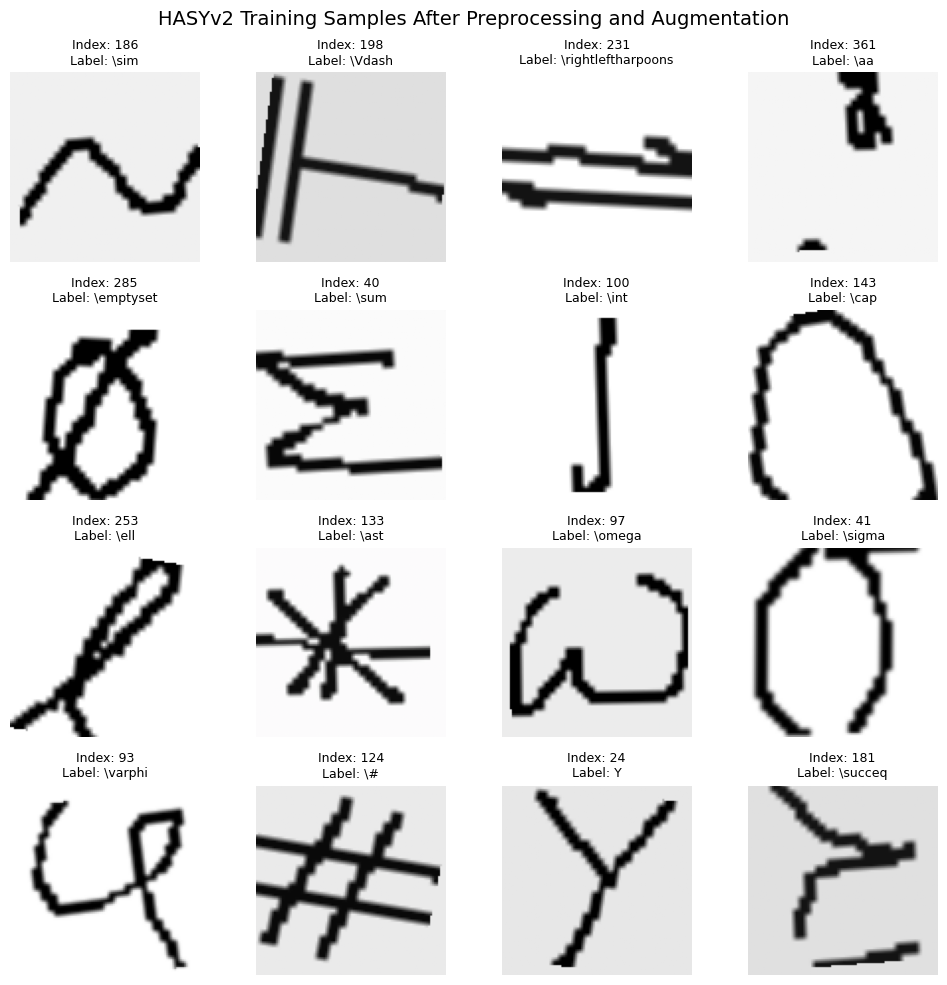

Batch image tensor shape: torch.Size([256, 3, 96, 96])
Batch target tensor shape: torch.Size([256])
Saved preview figure: /kaggle/working/results/training_samples_preview.pdf


In [8]:
# =========================================================
# Visual inspection of a training batch
# =========================================================
sample_batch = next(iter(train_loader))

sample_images = sample_batch["image"][:16].clone()
sample_targets = sample_batch["target"][:16]
sample_latex = sample_batch["latex"][:16]

# Reverse ImageNet normalization for display.
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

sample_images = sample_images * std + mean
sample_images = sample_images.clamp(0, 1)

figure, axes = plt.subplots(4, 4, figsize=(10, 10))

for axis, image, target, latex_label in zip(
    axes.flatten(),
    sample_images,
    sample_targets,
    sample_latex
):
    image_for_display = image.permute(1, 2, 0).numpy()

    axis.imshow(image_for_display)
    axis.set_title(
        f"Index: {int(target)}\nLabel: {latex_label}",
        fontsize=9
    )
    axis.axis("off")

plt.suptitle(
    "HASYv2 Training Samples After Preprocessing and Augmentation",
    fontsize=14
)

plt.tight_layout()

sample_figure_path = OUTPUT_DIR / "training_samples_preview.pdf"

plt.savefig(
    sample_figure_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Batch image tensor shape:", sample_batch["image"].shape)
print("Batch target tensor shape:", sample_batch["target"].shape)
print("Saved preview figure:", sample_figure_path)

In [9]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader

# =========================================================
# Revised transformations
# =========================================================

# Padding creates extra white space around the original
# 32x32 symbol so rotation and translation do not crop it.
train_transform = transforms.Compose([
    transforms.Pad(
        padding=8,
        fill=255,
        padding_mode="constant"
    ),

    transforms.RandomAffine(
        degrees=7,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        shear=2,
        interpolation=InterpolationMode.BILINEAR,
        fill=255
    ),

    transforms.RandomApply(
        [
            transforms.ColorJitter(
                brightness=0.08,
                contrast=0.08
            )
        ],
        p=0.50
    ),

    transforms.RandomApply(
        [
            transforms.GaussianBlur(
                kernel_size=3,
                sigma=(0.1, 0.5)
            )
        ],
        p=0.05
    ),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation and test images receive padding and resizing,
# but no random augmentation.
evaluation_transform = transforms.Compose([
    transforms.Pad(
        padding=8,
        fill=255,
        padding_mode="constant"
    ),

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=InterpolationMode.BILINEAR,
        antialias=True
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =========================================================
# Recreate datasets
# =========================================================
train_dataset = HASYv2Dataset(
    development_df,
    transform=train_transform
)

validation_dataset = HASYv2Dataset(
    validation_df,
    transform=evaluation_transform
)

test_dataset = HASYv2Dataset(
    locked_test_df,
    transform=evaluation_transform
)

# =========================================================
# Recreate data loaders
# =========================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0
)

print("Revised preprocessing pipeline created successfully.")
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Revised preprocessing pipeline created successfully.
Training batches: 532
Validation batches: 60
Test batches: 67


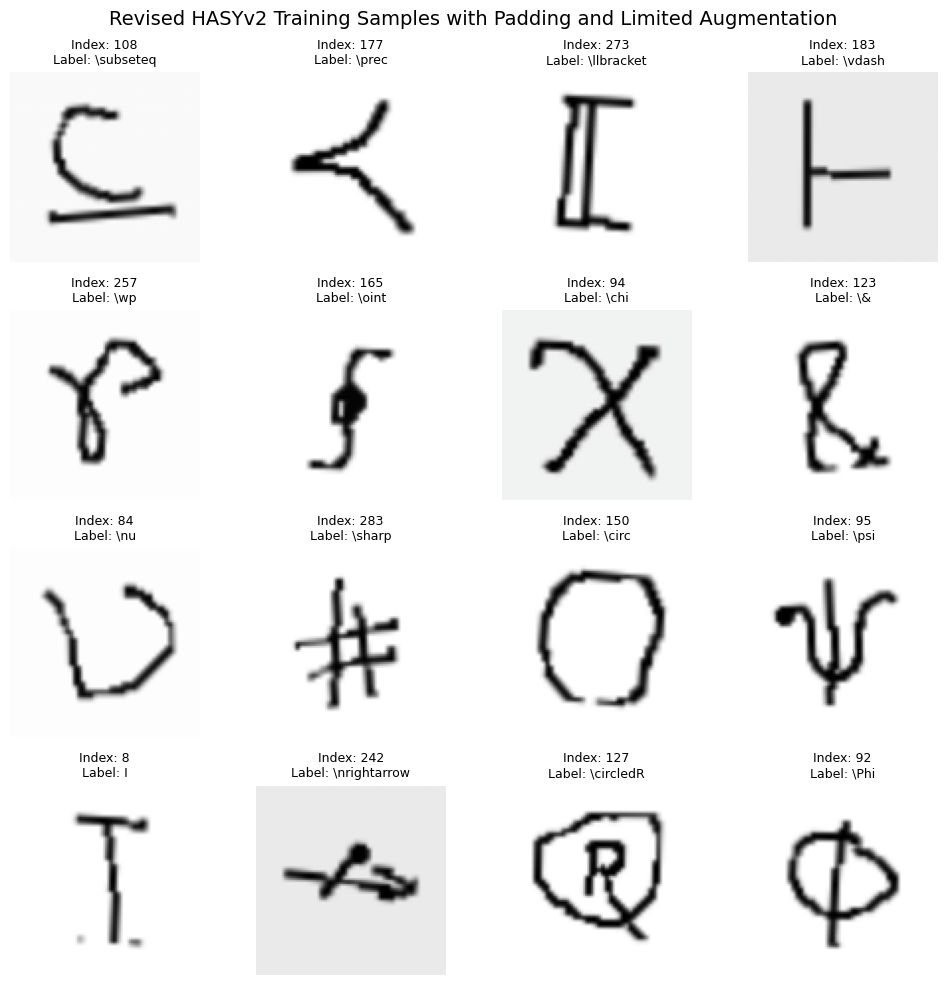

Batch image tensor shape: torch.Size([256, 3, 96, 96])
Saved revised preview: /kaggle/working/results/training_samples_preview_revised.pdf


In [10]:
# =========================================================
# Revised visual inspection
# =========================================================
sample_batch = next(iter(train_loader))

sample_images = sample_batch["image"][:16].clone()
sample_targets = sample_batch["target"][:16]
sample_latex = sample_batch["latex"][:16]

mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

sample_images = sample_images * std + mean
sample_images = sample_images.clamp(0, 1)

figure, axes = plt.subplots(4, 4, figsize=(10, 10))

for axis, image, target, latex_label in zip(
    axes.flatten(),
    sample_images,
    sample_targets,
    sample_latex
):
    axis.imshow(image.permute(1, 2, 0).numpy())

    axis.set_title(
        f"Index: {int(target)}\nLabel: {latex_label}",
        fontsize=9
    )

    axis.axis("off")

plt.suptitle(
    "Revised HASYv2 Training Samples with Padding and Limited Augmentation",
    fontsize=14
)

plt.tight_layout()

revised_preview_path = (
    OUTPUT_DIR / "training_samples_preview_revised.pdf"
)

plt.savefig(
    revised_preview_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Batch image tensor shape:", sample_batch["image"].shape)
print("Saved revised preview:", revised_preview_path)

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

# =========================================================
# Class weights for imbalanced training data
# =========================================================

development_class_counts = (
    development_df["symbol_id"]
    .value_counts()
    .reindex(class_table["symbol_id"])
    .fillna(0)
    .values
    .astype(np.float32)
)

# Inverse square-root weighting is less extreme than
# direct inverse-frequency weighting.
class_weights = 1.0 / np.sqrt(development_class_counts)

# Normalize so the average weight is 1.
class_weights = class_weights / class_weights.mean()

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("=" * 80)
print("CLASS WEIGHT SUMMARY")
print("=" * 80)

print("Minimum class weight:", float(class_weights_tensor.min()))
print("Maximum class weight:", float(class_weights_tensor.max()))
print("Mean class weight:", float(class_weights_tensor.mean()))

# =========================================================
# Custom CNN architecture
# =========================================================

class CustomCNN(nn.Module):
    def __init__(self, num_classes=369):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 96x96 -> 48x48
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=0.05),

            # Block 2: 48x48 -> 24x24
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=0.10),

            # Block 3: 24x24 -> 12x12
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=128,
                out_channels=128,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=0.15),

            # Block 4: 12x12 -> 6x6
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=256,
                out_channels=256,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout2d(p=0.20)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

# =========================================================
# Create model
# =========================================================

custom_cnn = CustomCNN(
    num_classes=NUM_CLASSES
).to(DEVICE)

# =========================================================
# Weighted loss function
# =========================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.05
)

# =========================================================
# Parameter count and estimated size
# =========================================================

total_parameters = sum(
    parameter.numel()
    for parameter in custom_cnn.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in custom_cnn.parameters()
    if parameter.requires_grad
)

estimated_size_mb = total_parameters * 4 / (1024 ** 2)

print("\n" + "=" * 80)
print("CUSTOM CNN SUMMARY")
print("=" * 80)

print(custom_cnn)

print("\nTotal parameters:", f"{total_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")
print("Estimated FP32 size:", f"{estimated_size_mb:.2f} MB")

# =========================================================
# One-batch forward-pass test
# =========================================================

test_batch = next(iter(train_loader))

test_images = test_batch["image"].to(
    DEVICE,
    non_blocking=True
)

test_targets = test_batch["target"].to(
    DEVICE,
    non_blocking=True
)

custom_cnn.eval()

with torch.no_grad():
    test_logits = custom_cnn(test_images)
    test_loss = criterion(test_logits, test_targets)

print("\n" + "=" * 80)
print("FORWARD-PASS TEST")
print("=" * 80)

print("Input tensor shape:", test_images.shape)
print("Output tensor shape:", test_logits.shape)
print("Expected output shape:", (len(test_images), NUM_CLASSES))
print("Test loss:", float(test_loss))

assert test_logits.shape == (
    len(test_images),
    NUM_CLASSES
)

assert torch.isfinite(test_loss)

print("\nCustom CNN forward pass completed successfully.")

CLASS WEIGHT SUMMARY
Minimum class weight: 0.241605743765831
Maximum class weight: 2.012949228286743
Mean class weight: 0.9999999403953552

CUSTOM CNN SUMMARY
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.05, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), paddin

In [12]:
import time
import torch.optim as optim

# =========================================================
# Optimizer for custom CNN
# =========================================================

custom_optimizer = optim.AdamW(
    custom_cnn.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

custom_cnn.train()

torch.cuda.empty_cache()

start_time = time.perf_counter()

custom_optimizer.zero_grad(set_to_none=True)

with torch.autocast(
    device_type="cuda",
    dtype=torch.float16,
    enabled=torch.cuda.is_available()
):
    logits = custom_cnn(test_images)
    loss = criterion(logits, test_targets)

loss.backward()

torch.nn.utils.clip_grad_norm_(
    custom_cnn.parameters(),
    max_norm=5.0
)

custom_optimizer.step()

elapsed_time = time.perf_counter() - start_time

print("=" * 80)
print("SINGLE TRAINING-STEP TEST")
print("=" * 80)

print("Training-step loss:", float(loss.detach()))
print("Elapsed time:", f"{elapsed_time:.3f} seconds")

if torch.cuda.is_available():
    allocated_mb = (
        torch.cuda.memory_allocated() / 1024 ** 2
    )

    reserved_mb = (
        torch.cuda.memory_reserved() / 1024 ** 2
    )

    peak_mb = (
        torch.cuda.max_memory_allocated() / 1024 ** 2
    )

    print("GPU allocated memory:", f"{allocated_mb:.2f} MB")
    print("GPU reserved memory:", f"{reserved_mb:.2f} MB")
    print("Peak GPU memory:", f"{peak_mb:.2f} MB")

print("\nSingle training step completed successfully.")

SINGLE TRAINING-STEP TEST
Training-step loss: 6.186695575714111
Elapsed time: 17.534 seconds
GPU allocated memory: 67.42 MB
GPU reserved memory: 668.00 MB
Peak GPU memory: 3015.24 MB

Single training step completed successfully.


In [14]:
import time
import copy
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score
)

from tqdm.auto import tqdm


# =========================================================
# Fresh model and training configuration
# =========================================================
CUSTOM_MAX_EPOCHS = 6
CUSTOM_PATIENCE = 2
CUSTOM_LEARNING_RATE = 1e-3
CUSTOM_WEIGHT_DECAY = 1e-4

CUSTOM_CHECKPOINT_PATH = (
    OUTPUT_DIR / "best_custom_cnn.pt"
)

# Remove the previously updated test model.
del custom_cnn
gc.collect()
torch.cuda.empty_cache()

# Create a completely fresh Custom CNN.
custom_cnn = CustomCNN(
    num_classes=NUM_CLASSES
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.05
)

custom_optimizer = optim.AdamW(
    custom_cnn.parameters(),
    lr=CUSTOM_LEARNING_RATE,
    weight_decay=CUSTOM_WEIGHT_DECAY
)

custom_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    custom_optimizer,
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print("Fresh Custom CNN created.")
print("Training device:", DEVICE)
print("Maximum epochs:", CUSTOM_MAX_EPOCHS)
print("Early-stopping patience:", CUSTOM_PATIENCE)
print("Checkpoint path:", CUSTOM_CHECKPOINT_PATH)

Fresh Custom CNN created.
Training device: cuda
Maximum epochs: 6
Early-stopping patience: 2
Checkpoint path: /kaggle/working/results/best_custom_cnn.pt


In [15]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    loss_function,
    scaler,
    device
):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    start_time = time.perf_counter()

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:
        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            logits = model(images)
            loss = loss_function(logits, targets)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size

        predictions = logits.argmax(dim=1)

        correct_predictions += (
            predictions == targets
        ).sum().item()

        total_samples += batch_size

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": (
                f"{correct_predictions / total_samples:.4f}"
            )
        })

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    epoch_time = time.perf_counter() - start_time

    return {
        "loss": epoch_loss,
        "top1_accuracy": epoch_accuracy,
        "time_seconds": epoch_time
    }


@torch.inference_mode()
def evaluate_model(
    model,
    loader,
    loss_function,
    device
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_targets = []
    all_predictions = []

    top1_correct = 0
    top5_correct = 0

    start_time = time.perf_counter()

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for batch in progress_bar:
        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            logits = model(images)
            loss = loss_function(logits, targets)

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size

        predictions = logits.argmax(dim=1)

        top1_correct += (
            predictions == targets
        ).sum().item()

        top5_indices = logits.topk(
            k=5,
            dim=1
        ).indices

        top5_correct += (
            top5_indices == targets.unsqueeze(1)
        ).any(dim=1).sum().item()

        all_targets.extend(
            targets.cpu().numpy().tolist()
        )

        all_predictions.extend(
            predictions.cpu().numpy().tolist()
        )

    all_targets = np.asarray(all_targets)
    all_predictions = np.asarray(all_predictions)

    validation_loss = running_loss / total_samples
    top1_accuracy = top1_correct / total_samples
    top5_accuracy = top5_correct / total_samples

    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        all_targets,
        all_predictions,
        average="weighted",
        zero_division=0
    )

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    evaluation_time = (
        time.perf_counter() - start_time
    )

    return {
        "loss": validation_loss,
        "top1_accuracy": top1_accuracy,
        "top5_accuracy": top5_accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "balanced_accuracy": balanced_accuracy,
        "time_seconds": evaluation_time
    }


print("Training and evaluation functions created successfully.")

Training and evaluation functions created successfully.


In [16]:
custom_history = []

best_validation_macro_f1 = -np.inf
best_epoch = 0
epochs_without_improvement = 0

custom_training_start = time.perf_counter()

print("=" * 90)
print("CUSTOM CNN TRAINING")
print("=" * 90)

for epoch in range(
    1,
    CUSTOM_MAX_EPOCHS + 1
):
    print(
        f"\nEpoch {epoch}/{CUSTOM_MAX_EPOCHS}"
    )

    current_learning_rate = (
        custom_optimizer.param_groups[0]["lr"]
    )

    training_metrics = train_one_epoch(
        model=custom_cnn,
        loader=train_loader,
        optimizer=custom_optimizer,
        loss_function=criterion,
        scaler=scaler,
        device=DEVICE
    )

    validation_metrics = evaluate_model(
        model=custom_cnn,
        loader=validation_loader,
        loss_function=criterion,
        device=DEVICE
    )

    custom_scheduler.step(
        validation_metrics["macro_f1"]
    )

    epoch_record = {
        "epoch": epoch,
        "learning_rate": current_learning_rate,

        "train_loss": training_metrics["loss"],
        "train_top1_accuracy": (
            training_metrics["top1_accuracy"]
        ),
        "train_time_seconds": (
            training_metrics["time_seconds"]
        ),

        "validation_loss": (
            validation_metrics["loss"]
        ),
        "validation_top1_accuracy": (
            validation_metrics["top1_accuracy"]
        ),
        "validation_top5_accuracy": (
            validation_metrics["top5_accuracy"]
        ),
        "validation_macro_f1": (
            validation_metrics["macro_f1"]
        ),
        "validation_weighted_f1": (
            validation_metrics["weighted_f1"]
        ),
        "validation_balanced_accuracy": (
            validation_metrics["balanced_accuracy"]
        ),
        "validation_time_seconds": (
            validation_metrics["time_seconds"]
        )
    }

    custom_history.append(epoch_record)

    print(
        f"Train loss: {training_metrics['loss']:.4f} | "
        f"Train top-1: {training_metrics['top1_accuracy']:.4f}"
    )

    print(
        f"Validation loss: {validation_metrics['loss']:.4f} | "
        f"Top-1: {validation_metrics['top1_accuracy']:.4f} | "
        f"Top-5: {validation_metrics['top5_accuracy']:.4f}"
    )

    print(
        f"Macro-F1: {validation_metrics['macro_f1']:.4f} | "
        f"Weighted-F1: {validation_metrics['weighted_f1']:.4f} | "
        f"Balanced accuracy: "
        f"{validation_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Training time: "
        f"{training_metrics['time_seconds'] / 60:.2f} min | "
        f"Validation time: "
        f"{validation_metrics['time_seconds'] / 60:.2f} min"
    )

    # Save latest history after every epoch.
    custom_history_df = pd.DataFrame(
        custom_history
    )

    custom_history_df.to_csv(
        OUTPUT_DIR / "custom_cnn_training_history.csv",
        index=False
    )

    # Check whether the current model is the best.
    if (
        validation_metrics["macro_f1"]
        > best_validation_macro_f1
    ):
        best_validation_macro_f1 = (
            validation_metrics["macro_f1"]
        )

        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint = {
            "model_name": "CustomCNN",
            "epoch": epoch,
            "model_state_dict": (
                custom_cnn.state_dict()
            ),
            "optimizer_state_dict": (
                custom_optimizer.state_dict()
            ),
            "validation_metrics": (
                validation_metrics
            ),
            "number_of_classes": NUM_CLASSES,
            "image_size": IMAGE_SIZE,
            "symbol_id_to_index": (
                symbol_id_to_index
            ),
            "index_to_symbol_id": (
                index_to_symbol_id
            ),
            "index_to_latex": (
                index_to_latex
            ),
            "random_seed": RANDOM_SEED
        }

        torch.save(
            checkpoint,
            CUSTOM_CHECKPOINT_PATH
        )

        print(
            f"New best checkpoint saved "
            f"(macro-F1: "
            f"{best_validation_macro_f1:.4f})."
        )

    else:
        epochs_without_improvement += 1

        print(
            "No macro-F1 improvement. "
            f"Patience: "
            f"{epochs_without_improvement}/"
            f"{CUSTOM_PATIENCE}"
        )

    if (
        epochs_without_improvement
        >= CUSTOM_PATIENCE
    ):
        print(
            "\nEarly stopping activated."
        )
        break

custom_total_training_time = (
    time.perf_counter()
    - custom_training_start
)

print("\n" + "=" * 90)
print("CUSTOM CNN TRAINING COMPLETE")
print("=" * 90)

print("Best epoch:", best_epoch)

print(
    "Best validation macro-F1:",
    f"{best_validation_macro_f1:.4f}"
)

print(
    "Total training duration:",
    f"{custom_total_training_time / 60:.2f} minutes"
)

print(
    "Best checkpoint:",
    CUSTOM_CHECKPOINT_PATH
)

CUSTOM CNN TRAINING

Epoch 1/6


Training:   0%|          | 0/532 [00:00<?, ?it/s]

Validation:   0%|          | 0/60 [00:00<?, ?it/s]

Train loss: 4.1045 | Train top-1: 0.3321
Validation loss: 3.1510 | Top-1: 0.4849 | Top-5: 0.7795
Macro-F1: 0.2488 | Weighted-F1: 0.4455 | Balanced accuracy: 0.2854
Training time: 4.14 min | Validation time: 0.43 min
New best checkpoint saved (macro-F1: 0.2488).

Epoch 2/6


Training:   0%|          | 0/532 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/60 [00:00<?, ?it/s]

Train loss: 1.9398 | Train top-1: 0.7625
Validation loss: 1.6708 | Top-1: 0.8114 | Top-5: 0.9720
Macro-F1: 0.6775 | Weighted-F1: 0.7928 | Balanced accuracy: 0.7059
Training time: 2.58 min | Validation time: 0.26 min
New best checkpoint saved (macro-F1: 0.6775).

Epoch 6/6


Training:   0%|          | 0/532 [00:00<?, ?it/s]

Validation:   0%|          | 0/60 [00:00<?, ?it/s]

Train loss: 1.8714 | Train top-1: 0.7744
Validation loss: 1.6365 | Top-1: 0.8083 | Top-5: 0.9733
Macro-F1: 0.6815 | Weighted-F1: 0.7924 | Balanced accuracy: 0.7081
Training time: 2.49 min | Validation time: 0.24 min
New best checkpoint saved (macro-F1: 0.6815).

CUSTOM CNN TRAINING COMPLETE
Best epoch: 6
Best validation macro-F1: 0.6815
Total training duration: 18.16 minutes
Best checkpoint: /kaggle/working/results/best_custom_cnn.pt


 epoch  learning_rate  train_loss  train_top1_accuracy  train_time_seconds  validation_loss  validation_top1_accuracy  validation_top5_accuracy  validation_macro_f1  validation_weighted_f1  validation_balanced_accuracy  validation_time_seconds
     1          0.001      4.1045               0.3321            248.2112           3.1510                    0.4849                    0.7795               0.2488                  0.4455                        0.2854                  25.7944
     2          0.001      2.5282               0.6507            149.3824           2.6910                    0.5868                    0.8306               0.3866                  0.5516                        0.4387                  14.1366
     3          0.001      2.1905               0.7174            144.9112           3.0360                    0.4691                    0.7494               0.3082                  0.4393                        0.3689                  13.6949
     4          0.001   

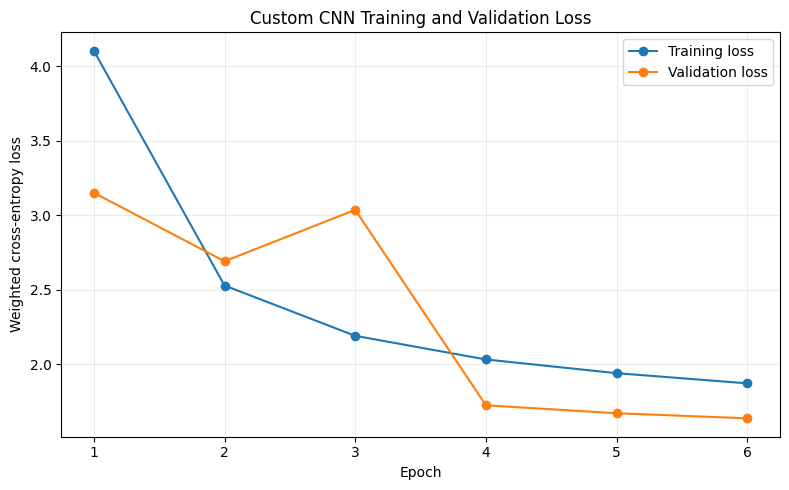

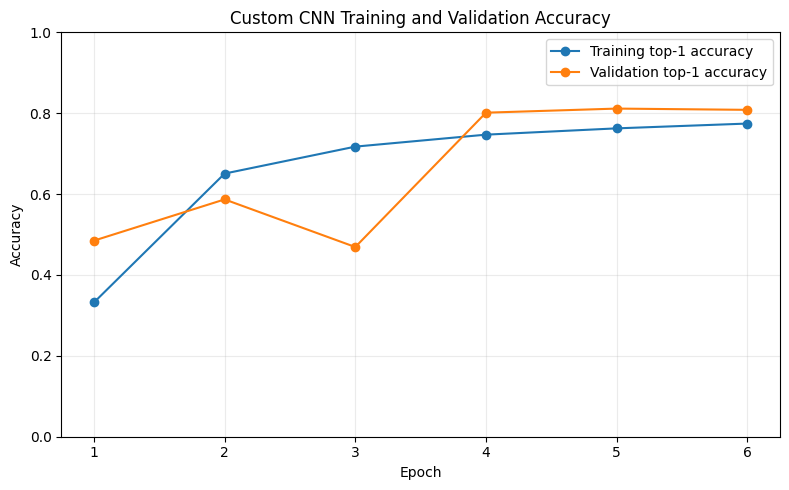

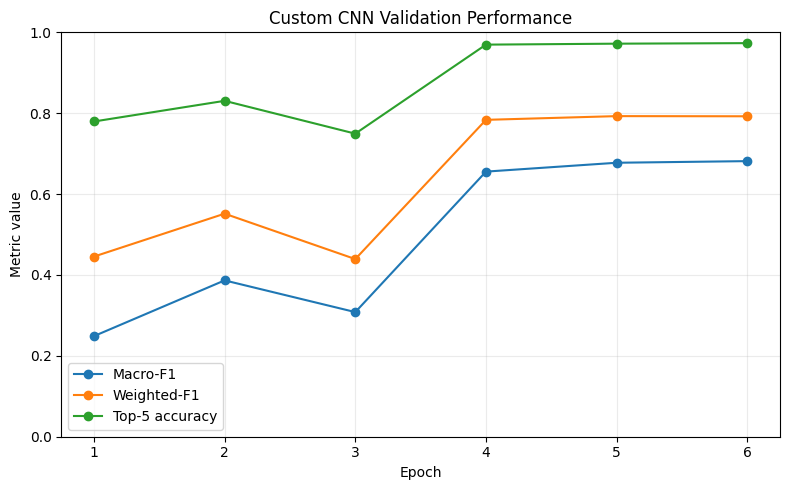


Saved:
/kaggle/working/results/custom_cnn_loss_curve.pdf
/kaggle/working/results/custom_cnn_accuracy_curve.pdf
/kaggle/working/results/custom_cnn_validation_metrics.pdf


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

custom_history_df = pd.read_csv(
    OUTPUT_DIR / "custom_cnn_training_history.csv"
)

print(custom_history_df.round(4).to_string(index=False))

# =========================================================
# Loss curve
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(
    custom_history_df["epoch"],
    custom_history_df["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    custom_history_df["epoch"],
    custom_history_df["validation_loss"],
    marker="o",
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted cross-entropy loss")
plt.title("Custom CNN Training and Validation Loss")
plt.xticks(custom_history_df["epoch"])
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

loss_curve_path = (
    OUTPUT_DIR / "custom_cnn_loss_curve.pdf"
)

plt.savefig(
    loss_curve_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# =========================================================
# Accuracy curve
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(
    custom_history_df["epoch"],
    custom_history_df["train_top1_accuracy"],
    marker="o",
    label="Training top-1 accuracy"
)

plt.plot(
    custom_history_df["epoch"],
    custom_history_df["validation_top1_accuracy"],
    marker="o",
    label="Validation top-1 accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Training and Validation Accuracy")
plt.xticks(custom_history_df["epoch"])
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

accuracy_curve_path = (
    OUTPUT_DIR / "custom_cnn_accuracy_curve.pdf"
)

plt.savefig(
    accuracy_curve_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# =========================================================
# Validation metric curve
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(
    custom_history_df["epoch"],
    custom_history_df["validation_macro_f1"],
    marker="o",
    label="Macro-F1"
)

plt.plot(
    custom_history_df["epoch"],
    custom_history_df["validation_weighted_f1"],
    marker="o",
    label="Weighted-F1"
)

plt.plot(
    custom_history_df["epoch"],
    custom_history_df["validation_top5_accuracy"],
    marker="o",
    label="Top-5 accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Custom CNN Validation Performance")
plt.xticks(custom_history_df["epoch"])
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

metric_curve_path = (
    OUTPUT_DIR / "custom_cnn_validation_metrics.pdf"
)

plt.savefig(
    metric_curve_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(loss_curve_path)
print(accuracy_curve_path)
print(metric_curve_path)

In [22]:
import gc
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import EfficientNet_V2_S_Weights

# =========================================================
# Transfer-learning batch sizes
# =========================================================
TRANSFER_TRAIN_BATCH_SIZE = 128
TRANSFER_EVAL_BATCH_SIZE = 128

transfer_train_loader = DataLoader(
    train_dataset,
    batch_size=TRANSFER_TRAIN_BATCH_SIZE,
    shuffle=True,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0
)

transfer_validation_loader = DataLoader(
    validation_dataset,
    batch_size=TRANSFER_EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0
)

transfer_test_loader = DataLoader(
    test_dataset,
    batch_size=TRANSFER_EVAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0
)

gc.collect()
torch.cuda.empty_cache()

print("Loading ImageNet-pretrained EfficientNetV2-S...")

efficientnet_model = models.efficientnet_v2_s(
    weights=EfficientNet_V2_S_Weights.DEFAULT
)

# Freeze the complete feature extractor for the first stage.
for parameter in efficientnet_model.features.parameters():
    parameter.requires_grad = False

# Replace the original ImageNet classifier.
efficientnet_input_features = (
    efficientnet_model.classifier[1].in_features
)

efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_input_features,
    NUM_CLASSES
)

efficientnet_model = efficientnet_model.to(DEVICE)

efficientnet_total_parameters = sum(
    parameter.numel()
    for parameter in efficientnet_model.parameters()
)

efficientnet_trainable_parameters = sum(
    parameter.numel()
    for parameter in efficientnet_model.parameters()
    if parameter.requires_grad
)

efficientnet_estimated_size_mb = (
    efficientnet_total_parameters * 4 / (1024 ** 2)
)

print("\nEfficientNetV2-S created successfully.")
print("Total parameters:", f"{efficientnet_total_parameters:,}")
print("Trainable parameters:", f"{efficientnet_trainable_parameters:,}")
print(
    "Estimated FP32 size:",
    f"{efficientnet_estimated_size_mb:.2f} MB"
)

# =========================================================
# Forward-pass test
# =========================================================
efficientnet_batch = next(iter(transfer_train_loader))

efficientnet_images = efficientnet_batch["image"].to(
    DEVICE,
    non_blocking=True
)

efficientnet_targets = efficientnet_batch["target"].to(
    DEVICE,
    non_blocking=True
)

efficientnet_model.eval()

with torch.no_grad():
    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=torch.cuda.is_available()
    ):
        efficientnet_logits = efficientnet_model(
            efficientnet_images
        )

        efficientnet_test_loss = criterion(
            efficientnet_logits,
            efficientnet_targets
        )

print("\nInput shape:", efficientnet_images.shape)
print("Output shape:", efficientnet_logits.shape)
print("Forward-pass loss:", float(efficientnet_test_loss))

assert efficientnet_logits.shape == (
    len(efficientnet_images),
    NUM_CLASSES
)

print("\nEfficientNetV2-S forward pass completed successfully.")

Loading ImageNet-pretrained EfficientNetV2-S...
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 193MB/s]



EfficientNetV2-S created successfully.
Total parameters: 20,650,177
Trainable parameters: 472,689
Estimated FP32 size: 78.77 MB

Input shape: torch.Size([128, 3, 96, 96])
Output shape: torch.Size([128, 369])
Forward-pass loss: 6.127897262573242

EfficientNetV2-S forward pass completed successfully.


In [21]:
import urllib.request

weights_url = (
    "https://download.pytorch.org/models/"
    "efficientnet_v2_s-dd5fe13b.pth"
)

try:
    request = urllib.request.Request(
        weights_url,
        method="HEAD",
        headers={"User-Agent": "Mozilla/5.0"}
    )

    response = urllib.request.urlopen(
        request,
        timeout=15
    )

    print("Internet and model URL are accessible.")
    print("Response status:", response.status)
    print(
        "File size:",
        response.headers.get("Content-Length"),
        "bytes"
    )

except Exception as error:
    print("Model URL test failed:")
    print(type(error).__name__, error)

Internet and model URL are accessible.
Response status: 200
File size: 86721253 bytes


In [23]:
def set_frozen_modules_to_eval(module):
    """
    Keep completely frozen child modules in evaluation mode.
    This prevents their BatchNorm statistics from changing.
    """
    for child in module.children():
        child_parameters = list(child.parameters())

        if child_parameters and not any(
            parameter.requires_grad
            for parameter in child_parameters
        ):
            child.eval()
        else:
            set_frozen_modules_to_eval(child)


def train_transfer_epoch(
    model,
    loader,
    optimizer,
    loss_function,
    scaler,
    device
):
    model.train()

    # Frozen modules remain in evaluation mode.
    set_frozen_modules_to_eval(model)

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    start_time = time.perf_counter()

    progress_bar = tqdm(
        loader,
        desc="Transfer training",
        leave=False
    )

    for batch in progress_bar:
        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            logits = model(images)
            loss = loss_function(logits, targets)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            [
                parameter
                for parameter in model.parameters()
                if parameter.requires_grad
            ],
            max_norm=5.0
        )

        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size

        predictions = logits.argmax(dim=1)

        correct_predictions += (
            predictions == targets
        ).sum().item()

        total_samples += batch_size

        progress_bar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": (
                f"{correct_predictions / total_samples:.4f}"
            )
        })

    return {
        "loss": running_loss / total_samples,
        "top1_accuracy": (
            correct_predictions / total_samples
        ),
        "time_seconds": (
            time.perf_counter() - start_time
        )
    }


print("Transfer-learning training function created.")

Transfer-learning training function created.


In [24]:
# =========================================================
# EfficientNetV2-S Stage 1: frozen-backbone training
# =========================================================
EFFICIENTNET_HEAD_EPOCHS = 3
EFFICIENTNET_HEAD_LR = 3e-4
EFFICIENTNET_WEIGHT_DECAY = 1e-4

EFFICIENTNET_CHECKPOINT_PATH = (
    OUTPUT_DIR / "best_efficientnet_v2_s.pt"
)

efficientnet_optimizer = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        efficientnet_model.parameters()
    ),
    lr=EFFICIENTNET_HEAD_LR,
    weight_decay=EFFICIENTNET_WEIGHT_DECAY
)

efficientnet_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

efficientnet_history = []

efficientnet_best_macro_f1 = -np.inf
efficientnet_best_epoch = 0
efficientnet_epochs_without_improvement = 0

efficientnet_training_start = time.perf_counter()

print("=" * 90)
print("EFFICIENTNETV2-S — STAGE 1")
print("FROZEN BACKBONE / CLASSIFIER TRAINING")
print("=" * 90)

for epoch in range(
    1,
    EFFICIENTNET_HEAD_EPOCHS + 1
):
    print(
        f"\nStage 1 epoch "
        f"{epoch}/{EFFICIENTNET_HEAD_EPOCHS}"
    )

    training_metrics = train_transfer_epoch(
        model=efficientnet_model,
        loader=transfer_train_loader,
        optimizer=efficientnet_optimizer,
        loss_function=criterion,
        scaler=efficientnet_scaler,
        device=DEVICE
    )

    validation_metrics = evaluate_model(
        model=efficientnet_model,
        loader=transfer_validation_loader,
        loss_function=criterion,
        device=DEVICE
    )

    global_epoch = epoch

    epoch_record = {
        "stage": "classifier_head",
        "epoch": global_epoch,
        "learning_rate": EFFICIENTNET_HEAD_LR,
        "train_loss": training_metrics["loss"],
        "train_top1_accuracy": (
            training_metrics["top1_accuracy"]
        ),
        "train_time_seconds": (
            training_metrics["time_seconds"]
        ),
        "validation_loss": (
            validation_metrics["loss"]
        ),
        "validation_top1_accuracy": (
            validation_metrics["top1_accuracy"]
        ),
        "validation_top5_accuracy": (
            validation_metrics["top5_accuracy"]
        ),
        "validation_macro_f1": (
            validation_metrics["macro_f1"]
        ),
        "validation_weighted_f1": (
            validation_metrics["weighted_f1"]
        ),
        "validation_balanced_accuracy": (
            validation_metrics["balanced_accuracy"]
        ),
        "validation_time_seconds": (
            validation_metrics["time_seconds"]
        )
    }

    efficientnet_history.append(epoch_record)

    print(
        f"Train loss: {training_metrics['loss']:.4f} | "
        f"Train top-1: "
        f"{training_metrics['top1_accuracy']:.4f}"
    )

    print(
        f"Validation loss: "
        f"{validation_metrics['loss']:.4f} | "
        f"Top-1: "
        f"{validation_metrics['top1_accuracy']:.4f} | "
        f"Top-5: "
        f"{validation_metrics['top5_accuracy']:.4f}"
    )

    print(
        f"Macro-F1: "
        f"{validation_metrics['macro_f1']:.4f} | "
        f"Weighted-F1: "
        f"{validation_metrics['weighted_f1']:.4f} | "
        f"Balanced accuracy: "
        f"{validation_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Training time: "
        f"{training_metrics['time_seconds'] / 60:.2f} min | "
        f"Validation time: "
        f"{validation_metrics['time_seconds'] / 60:.2f} min"
    )

    pd.DataFrame(
        efficientnet_history
    ).to_csv(
        OUTPUT_DIR /
        "efficientnet_v2_s_training_history.csv",
        index=False
    )

    if (
        validation_metrics["macro_f1"]
        > efficientnet_best_macro_f1
    ):
        efficientnet_best_macro_f1 = (
            validation_metrics["macro_f1"]
        )

        efficientnet_best_epoch = global_epoch

        checkpoint = {
            "model_name": "EfficientNetV2-S",
            "stage": "classifier_head",
            "epoch": global_epoch,
            "model_state_dict": (
                efficientnet_model.state_dict()
            ),
            "validation_metrics": validation_metrics,
            "number_of_classes": NUM_CLASSES,
            "image_size": IMAGE_SIZE,
            "symbol_id_to_index": symbol_id_to_index,
            "index_to_symbol_id": index_to_symbol_id,
            "index_to_latex": index_to_latex,
            "random_seed": RANDOM_SEED
        }

        torch.save(
            checkpoint,
            EFFICIENTNET_CHECKPOINT_PATH
        )

        print(
            "New best EfficientNet checkpoint saved "
            f"(macro-F1: "
            f"{efficientnet_best_macro_f1:.4f})."
        )

print("\nEfficientNet Stage 1 complete.")

EFFICIENTNETV2-S — STAGE 1
FROZEN BACKBONE / CLASSIFIER TRAINING

Stage 1 epoch 1/3


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 3.9809 | Train top-1: 0.4708
Validation loss: 3.3085 | Top-1: 0.5603 | Top-5: 0.8174
Macro-F1: 0.2972 | Weighted-F1: 0.5099 | Balanced accuracy: 0.3066
Training time: 2.73 min | Validation time: 0.27 min
New best EfficientNet checkpoint saved (macro-F1: 0.2972).

Stage 1 epoch 2/3


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 2.8343 | Train top-1: 0.6268
Validation loss: 2.8280 | Top-1: 0.6226 | Top-5: 0.8676
Macro-F1: 0.3970 | Weighted-F1: 0.5935 | Balanced accuracy: 0.4028
Training time: 2.40 min | Validation time: 0.23 min
New best EfficientNet checkpoint saved (macro-F1: 0.3970).

Stage 1 epoch 3/3


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 2.5300 | Train top-1: 0.6663
Validation loss: 2.6277 | Top-1: 0.6507 | Top-5: 0.8842
Macro-F1: 0.4472 | Weighted-F1: 0.6278 | Balanced accuracy: 0.4576
Training time: 2.39 min | Validation time: 0.22 min
New best EfficientNet checkpoint saved (macro-F1: 0.4472).

EfficientNet Stage 1 complete.


In [25]:
# =========================================================
# EfficientNetV2-S Stage 2: partial fine-tuning
# =========================================================
EFFICIENTNET_FINE_TUNE_EPOCHS = 2
EFFICIENTNET_BACKBONE_LR = 1e-5
EFFICIENTNET_CLASSIFIER_LR = 1e-4

# Unfreeze the final two feature groups.
for parameter in efficientnet_model.features[-2:].parameters():
    parameter.requires_grad = True

# Keep earlier feature groups frozen.
for feature_group in efficientnet_model.features[:-2]:
    for parameter in feature_group.parameters():
        parameter.requires_grad = False

efficientnet_finetune_optimizer = optim.AdamW(
    [
        {
            "params": (
                efficientnet_model.features[-2:]
                .parameters()
            ),
            "lr": EFFICIENTNET_BACKBONE_LR
        },
        {
            "params": (
                efficientnet_model.classifier
                .parameters()
            ),
            "lr": EFFICIENTNET_CLASSIFIER_LR
        }
    ],
    weight_decay=EFFICIENTNET_WEIGHT_DECAY
)

fine_tune_trainable_parameters = sum(
    parameter.numel()
    for parameter in efficientnet_model.parameters()
    if parameter.requires_grad
)

print("=" * 90)
print("EFFICIENTNETV2-S — STAGE 2")
print("PARTIAL FINE-TUNING")
print("=" * 90)

print(
    "Trainable parameters after unfreezing:",
    f"{fine_tune_trainable_parameters:,}"
)

for fine_tune_epoch in range(
    1,
    EFFICIENTNET_FINE_TUNE_EPOCHS + 1
):
    global_epoch = (
        EFFICIENTNET_HEAD_EPOCHS
        + fine_tune_epoch
    )

    print(
        f"\nStage 2 epoch "
        f"{fine_tune_epoch}/"
        f"{EFFICIENTNET_FINE_TUNE_EPOCHS} "
        f"(global epoch {global_epoch})"
    )

    training_metrics = train_transfer_epoch(
        model=efficientnet_model,
        loader=transfer_train_loader,
        optimizer=efficientnet_finetune_optimizer,
        loss_function=criterion,
        scaler=efficientnet_scaler,
        device=DEVICE
    )

    validation_metrics = evaluate_model(
        model=efficientnet_model,
        loader=transfer_validation_loader,
        loss_function=criterion,
        device=DEVICE
    )

    epoch_record = {
        "stage": "partial_fine_tuning",
        "epoch": global_epoch,
        "learning_rate": (
            EFFICIENTNET_CLASSIFIER_LR
        ),
        "train_loss": training_metrics["loss"],
        "train_top1_accuracy": (
            training_metrics["top1_accuracy"]
        ),
        "train_time_seconds": (
            training_metrics["time_seconds"]
        ),
        "validation_loss": (
            validation_metrics["loss"]
        ),
        "validation_top1_accuracy": (
            validation_metrics["top1_accuracy"]
        ),
        "validation_top5_accuracy": (
            validation_metrics["top5_accuracy"]
        ),
        "validation_macro_f1": (
            validation_metrics["macro_f1"]
        ),
        "validation_weighted_f1": (
            validation_metrics["weighted_f1"]
        ),
        "validation_balanced_accuracy": (
            validation_metrics["balanced_accuracy"]
        ),
        "validation_time_seconds": (
            validation_metrics["time_seconds"]
        )
    }

    efficientnet_history.append(epoch_record)

    print(
        f"Train loss: {training_metrics['loss']:.4f} | "
        f"Train top-1: "
        f"{training_metrics['top1_accuracy']:.4f}"
    )

    print(
        f"Validation loss: "
        f"{validation_metrics['loss']:.4f} | "
        f"Top-1: "
        f"{validation_metrics['top1_accuracy']:.4f} | "
        f"Top-5: "
        f"{validation_metrics['top5_accuracy']:.4f}"
    )

    print(
        f"Macro-F1: "
        f"{validation_metrics['macro_f1']:.4f} | "
        f"Weighted-F1: "
        f"{validation_metrics['weighted_f1']:.4f} | "
        f"Balanced accuracy: "
        f"{validation_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Training time: "
        f"{training_metrics['time_seconds'] / 60:.2f} min | "
        f"Validation time: "
        f"{validation_metrics['time_seconds'] / 60:.2f} min"
    )

    pd.DataFrame(
        efficientnet_history
    ).to_csv(
        OUTPUT_DIR /
        "efficientnet_v2_s_training_history.csv",
        index=False
    )

    if (
        validation_metrics["macro_f1"]
        > efficientnet_best_macro_f1
    ):
        efficientnet_best_macro_f1 = (
            validation_metrics["macro_f1"]
        )

        efficientnet_best_epoch = global_epoch

        checkpoint = {
            "model_name": "EfficientNetV2-S",
            "stage": "partial_fine_tuning",
            "epoch": global_epoch,
            "model_state_dict": (
                efficientnet_model.state_dict()
            ),
            "validation_metrics": validation_metrics,
            "number_of_classes": NUM_CLASSES,
            "image_size": IMAGE_SIZE,
            "symbol_id_to_index": symbol_id_to_index,
            "index_to_symbol_id": index_to_symbol_id,
            "index_to_latex": index_to_latex,
            "random_seed": RANDOM_SEED
        }

        torch.save(
            checkpoint,
            EFFICIENTNET_CHECKPOINT_PATH
        )

        print(
            "New best EfficientNet checkpoint saved "
            f"(macro-F1: "
            f"{efficientnet_best_macro_f1:.4f})."
        )

efficientnet_total_training_time = (
    time.perf_counter()
    - efficientnet_training_start
)

print("\n" + "=" * 90)
print("EFFICIENTNETV2-S TRAINING COMPLETE")
print("=" * 90)

print(
    "Best epoch:",
    efficientnet_best_epoch
)

print(
    "Best validation macro-F1:",
    f"{efficientnet_best_macro_f1:.4f}"
)

print(
    "Total training duration:",
    f"{efficientnet_total_training_time / 60:.2f} minutes"
)

print(
    "Best checkpoint:",
    EFFICIENTNET_CHECKPOINT_PATH
)

EFFICIENTNETV2-S — STAGE 2
PARTIAL FINE-TUNING
Trainable parameters after unfreezing: 15,364,761

Stage 2 epoch 1/2 (global epoch 4)


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 2.5280 | Train top-1: 0.6284
Validation loss: 1.9876 | Top-1: 0.7353 | Top-5: 0.9404
Macro-F1: 0.5821 | Weighted-F1: 0.7237 | Balanced accuracy: 0.6002
Training time: 2.54 min | Validation time: 0.23 min
New best EfficientNet checkpoint saved (macro-F1: 0.5821).

Stage 2 epoch 2/2 (global epoch 5)


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 1.8667 | Train top-1: 0.7623
Validation loss: 1.7543 | Top-1: 0.7781 | Top-5: 0.9605
Macro-F1: 0.6444 | Weighted-F1: 0.7669 | Balanced accuracy: 0.6595
Training time: 2.52 min | Validation time: 0.23 min
New best EfficientNet checkpoint saved (macro-F1: 0.6444).

EFFICIENTNETV2-S TRAINING COMPLETE
Best epoch: 5
Best validation macro-F1: 0.6444
Total training duration: 14.56 minutes
Best checkpoint: /kaggle/working/results/best_efficientnet_v2_s.pt


              stage  epoch  learning_rate  train_loss  train_top1_accuracy  train_time_seconds  validation_loss  validation_top1_accuracy  validation_top5_accuracy  validation_macro_f1  validation_weighted_f1  validation_balanced_accuracy  validation_time_seconds
    classifier_head      1         0.0003      3.9809               0.4708            163.7388           3.3085                    0.5603                    0.8174               0.2972                  0.5099                        0.3066                  16.3189
    classifier_head      2         0.0003      2.8343               0.6268            143.9655           2.8280                    0.6226                    0.8676               0.3970                  0.5935                        0.4028                  13.9185
    classifier_head      3         0.0003      2.5300               0.6663            143.1641           2.6277                    0.6507                    0.8842               0.4472                  0.6278

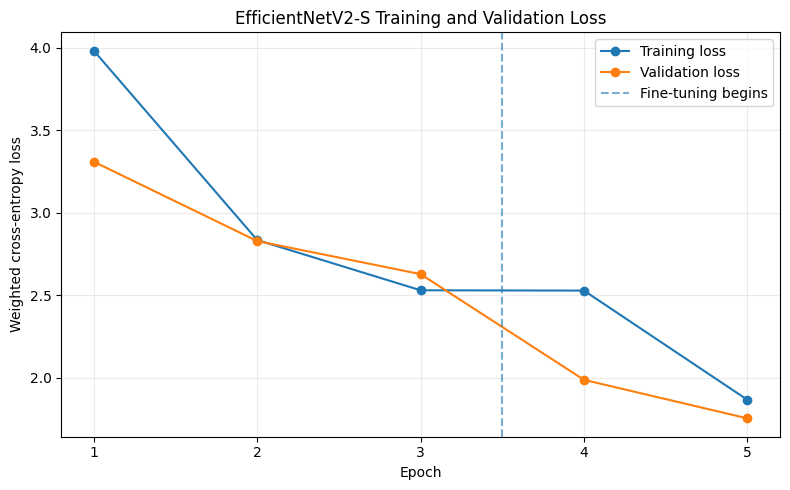

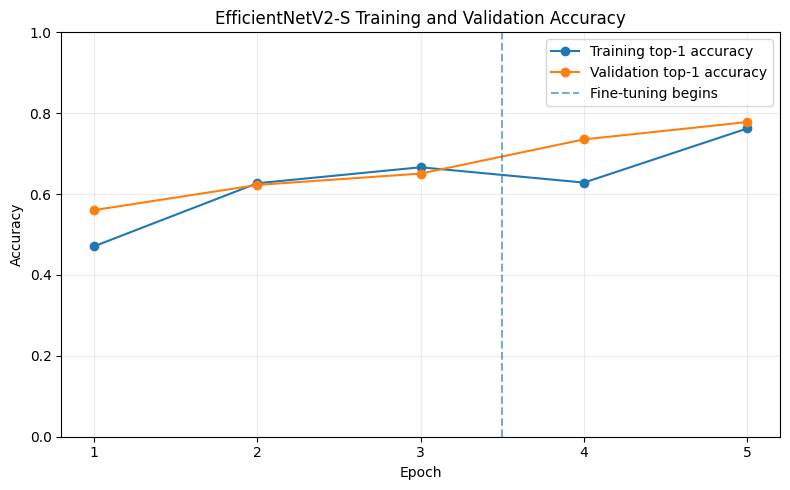

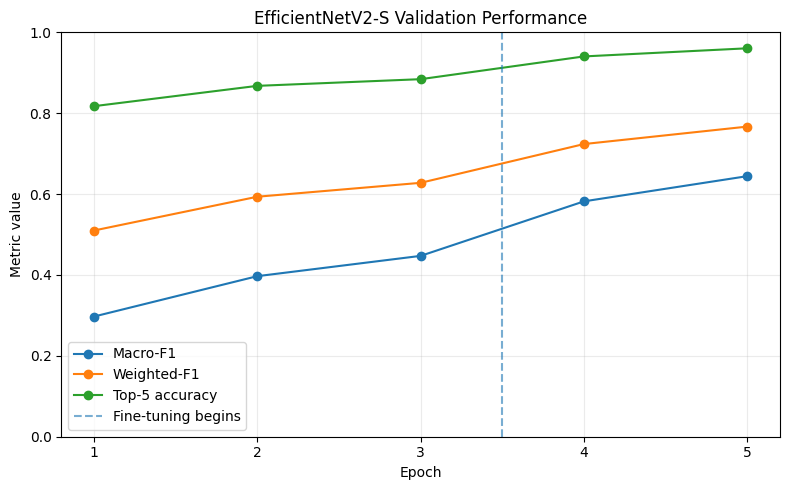


Saved:
/kaggle/working/results/efficientnet_v2_s_loss_curve.pdf
/kaggle/working/results/efficientnet_v2_s_accuracy_curve.pdf
/kaggle/working/results/efficientnet_v2_s_validation_metrics.pdf


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

efficientnet_history_df = pd.read_csv(
    OUTPUT_DIR / "efficientnet_v2_s_training_history.csv"
)

print(
    efficientnet_history_df
    .round(4)
    .to_string(index=False)
)

# =========================================================
# Loss curve
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(
    efficientnet_history_df["epoch"],
    efficientnet_history_df["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    efficientnet_history_df["epoch"],
    efficientnet_history_df["validation_loss"],
    marker="o",
    label="Validation loss"
)

plt.axvline(
    x=3.5,
    linestyle="--",
    alpha=0.6,
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted cross-entropy loss")
plt.title("EfficientNetV2-S Training and Validation Loss")
plt.xticks(efficientnet_history_df["epoch"])
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

efficientnet_loss_path = (
    OUTPUT_DIR / "efficientnet_v2_s_loss_curve.pdf"
)

plt.savefig(
    efficientnet_loss_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# =========================================================
# Accuracy curve
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(
    efficientnet_history_df["epoch"],
    efficientnet_history_df["train_top1_accuracy"],
    marker="o",
    label="Training top-1 accuracy"
)

plt.plot(
    efficientnet_history_df["epoch"],
    efficientnet_history_df["validation_top1_accuracy"],
    marker="o",
    label="Validation top-1 accuracy"
)

plt.axvline(
    x=3.5,
    linestyle="--",
    alpha=0.6,
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EfficientNetV2-S Training and Validation Accuracy")
plt.xticks(efficientnet_history_df["epoch"])
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

efficientnet_accuracy_path = (
    OUTPUT_DIR / "efficientnet_v2_s_accuracy_curve.pdf"
)

plt.savefig(
    efficientnet_accuracy_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# =========================================================
# Validation metrics
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(
    efficientnet_history_df["epoch"],
    efficientnet_history_df["validation_macro_f1"],
    marker="o",
    label="Macro-F1"
)

plt.plot(
    efficientnet_history_df["epoch"],
    efficientnet_history_df["validation_weighted_f1"],
    marker="o",
    label="Weighted-F1"
)

plt.plot(
    efficientnet_history_df["epoch"],
    efficientnet_history_df["validation_top5_accuracy"],
    marker="o",
    label="Top-5 accuracy"
)

plt.axvline(
    x=3.5,
    linestyle="--",
    alpha=0.6,
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("EfficientNetV2-S Validation Performance")
plt.xticks(efficientnet_history_df["epoch"])
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

efficientnet_metrics_path = (
    OUTPUT_DIR / "efficientnet_v2_s_validation_metrics.pdf"
)

plt.savefig(
    efficientnet_metrics_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print(efficientnet_loss_path)
print(efficientnet_accuracy_path)
print(efficientnet_metrics_path)

In [27]:
import gc
import torch
import torch.nn as nn

from torchvision import models
from torchvision.models import ConvNeXt_Tiny_Weights

gc.collect()
torch.cuda.empty_cache()

# Remove EfficientNet from GPU memory.
efficientnet_model = efficientnet_model.cpu()
del efficientnet_model
gc.collect()
torch.cuda.empty_cache()

print("Loading ImageNet-pretrained ConvNeXt-Tiny...")

convnext_model = models.convnext_tiny(
    weights=ConvNeXt_Tiny_Weights.DEFAULT
)

# Freeze feature extractor for Stage 1.
for parameter in convnext_model.features.parameters():
    parameter.requires_grad = False

# Replace original ImageNet output layer.
convnext_input_features = (
    convnext_model.classifier[2].in_features
)

convnext_model.classifier[2] = nn.Linear(
    convnext_input_features,
    NUM_CLASSES
)

convnext_model = convnext_model.to(DEVICE)

convnext_total_parameters = sum(
    parameter.numel()
    for parameter in convnext_model.parameters()
)

convnext_trainable_parameters = sum(
    parameter.numel()
    for parameter in convnext_model.parameters()
    if parameter.requires_grad
)

convnext_estimated_size_mb = (
    convnext_total_parameters * 4 / (1024 ** 2)
)

print("\nConvNeXt-Tiny created successfully.")
print(
    "Total parameters:",
    f"{convnext_total_parameters:,}"
)
print(
    "Trainable parameters:",
    f"{convnext_trainable_parameters:,}"
)
print(
    "Estimated FP32 size:",
    f"{convnext_estimated_size_mb:.2f} MB"
)

# =========================================================
# Forward-pass test
# =========================================================
convnext_batch = next(
    iter(transfer_train_loader)
)

convnext_images = convnext_batch["image"].to(
    DEVICE,
    non_blocking=True
)

convnext_targets = convnext_batch["target"].to(
    DEVICE,
    non_blocking=True
)

convnext_model.eval()

with torch.no_grad():
    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=torch.cuda.is_available()
    ):
        convnext_logits = convnext_model(
            convnext_images
        )

        convnext_test_loss = criterion(
            convnext_logits,
            convnext_targets
        )

print("\nInput shape:", convnext_images.shape)
print("Output shape:", convnext_logits.shape)
print("Forward-pass loss:", float(convnext_test_loss))

assert convnext_logits.shape == (
    len(convnext_images),
    NUM_CLASSES
)

print(
    "\nConvNeXt-Tiny forward pass completed successfully."
)

Loading ImageNet-pretrained ConvNeXt-Tiny...
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 199MB/s] 



ConvNeXt-Tiny created successfully.
Total parameters: 28,103,889
Trainable parameters: 285,297
Estimated FP32 size: 107.21 MB

Input shape: torch.Size([128, 3, 96, 96])
Output shape: torch.Size([128, 369])
Forward-pass loss: 6.202155590057373

ConvNeXt-Tiny forward pass completed successfully.


In [28]:
# =========================================================
# ConvNeXt-Tiny Stage 1
# =========================================================
CONVNEXT_HEAD_EPOCHS = 3
CONVNEXT_HEAD_LR = 3e-4
CONVNEXT_WEIGHT_DECAY = 1e-4

CONVNEXT_CHECKPOINT_PATH = (
    OUTPUT_DIR / "best_convnext_tiny.pt"
)

convnext_optimizer = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        convnext_model.parameters()
    ),
    lr=CONVNEXT_HEAD_LR,
    weight_decay=CONVNEXT_WEIGHT_DECAY
)

convnext_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

convnext_history = []

convnext_best_macro_f1 = -np.inf
convnext_best_epoch = 0

convnext_training_start = time.perf_counter()

print("=" * 90)
print("CONVNEXT-TINY — STAGE 1")
print("FROZEN BACKBONE / CLASSIFIER TRAINING")
print("=" * 90)

for epoch in range(
    1,
    CONVNEXT_HEAD_EPOCHS + 1
):
    print(
        f"\nStage 1 epoch "
        f"{epoch}/{CONVNEXT_HEAD_EPOCHS}"
    )

    training_metrics = train_transfer_epoch(
        model=convnext_model,
        loader=transfer_train_loader,
        optimizer=convnext_optimizer,
        loss_function=criterion,
        scaler=convnext_scaler,
        device=DEVICE
    )

    validation_metrics = evaluate_model(
        model=convnext_model,
        loader=transfer_validation_loader,
        loss_function=criterion,
        device=DEVICE
    )

    global_epoch = epoch

    epoch_record = {
        "stage": "classifier_head",
        "epoch": global_epoch,
        "learning_rate": CONVNEXT_HEAD_LR,
        "train_loss": training_metrics["loss"],
        "train_top1_accuracy": (
            training_metrics["top1_accuracy"]
        ),
        "train_time_seconds": (
            training_metrics["time_seconds"]
        ),
        "validation_loss": (
            validation_metrics["loss"]
        ),
        "validation_top1_accuracy": (
            validation_metrics["top1_accuracy"]
        ),
        "validation_top5_accuracy": (
            validation_metrics["top5_accuracy"]
        ),
        "validation_macro_f1": (
            validation_metrics["macro_f1"]
        ),
        "validation_weighted_f1": (
            validation_metrics["weighted_f1"]
        ),
        "validation_balanced_accuracy": (
            validation_metrics["balanced_accuracy"]
        ),
        "validation_time_seconds": (
            validation_metrics["time_seconds"]
        )
    }

    convnext_history.append(epoch_record)

    print(
        f"Train loss: {training_metrics['loss']:.4f} | "
        f"Train top-1: "
        f"{training_metrics['top1_accuracy']:.4f}"
    )

    print(
        f"Validation loss: "
        f"{validation_metrics['loss']:.4f} | "
        f"Top-1: "
        f"{validation_metrics['top1_accuracy']:.4f} | "
        f"Top-5: "
        f"{validation_metrics['top5_accuracy']:.4f}"
    )

    print(
        f"Macro-F1: "
        f"{validation_metrics['macro_f1']:.4f} | "
        f"Weighted-F1: "
        f"{validation_metrics['weighted_f1']:.4f} | "
        f"Balanced accuracy: "
        f"{validation_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Training time: "
        f"{training_metrics['time_seconds'] / 60:.2f} min | "
        f"Validation time: "
        f"{validation_metrics['time_seconds'] / 60:.2f} min"
    )

    pd.DataFrame(
        convnext_history
    ).to_csv(
        OUTPUT_DIR /
        "convnext_tiny_training_history.csv",
        index=False
    )

    if (
        validation_metrics["macro_f1"]
        > convnext_best_macro_f1
    ):
        convnext_best_macro_f1 = (
            validation_metrics["macro_f1"]
        )

        convnext_best_epoch = global_epoch

        checkpoint = {
            "model_name": "ConvNeXt-Tiny",
            "stage": "classifier_head",
            "epoch": global_epoch,
            "model_state_dict": (
                convnext_model.state_dict()
            ),
            "validation_metrics": validation_metrics,
            "number_of_classes": NUM_CLASSES,
            "image_size": IMAGE_SIZE,
            "symbol_id_to_index": symbol_id_to_index,
            "index_to_symbol_id": index_to_symbol_id,
            "index_to_latex": index_to_latex,
            "random_seed": RANDOM_SEED
        }

        torch.save(
            checkpoint,
            CONVNEXT_CHECKPOINT_PATH
        )

        print(
            "New best ConvNeXt checkpoint saved "
            f"(macro-F1: "
            f"{convnext_best_macro_f1:.4f})."
        )

print("\nConvNeXt Stage 1 complete.")

CONVNEXT-TINY — STAGE 1
FROZEN BACKBONE / CLASSIFIER TRAINING

Stage 1 epoch 1/3


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 3.1870 | Train top-1: 0.5726
Validation loss: 2.6255 | Top-1: 0.6358 | Top-5: 0.8844
Macro-F1: 0.4259 | Weighted-F1: 0.6144 | Balanced accuracy: 0.4441
Training time: 2.39 min | Validation time: 0.32 min
New best ConvNeXt checkpoint saved (macro-F1: 0.4259).

Stage 1 epoch 2/3


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 2.2396 | Train top-1: 0.7022
Validation loss: 2.3160 | Top-1: 0.6849 | Top-5: 0.9158
Macro-F1: 0.5192 | Weighted-F1: 0.6769 | Balanced accuracy: 0.5351
Training time: 2.36 min | Validation time: 0.22 min
New best ConvNeXt checkpoint saved (macro-F1: 0.5192).

Stage 1 epoch 3/3


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 2.0520 | Train top-1: 0.7329
Validation loss: 2.1853 | Top-1: 0.7042 | Top-5: 0.9295
Macro-F1: 0.5493 | Weighted-F1: 0.6958 | Balanced accuracy: 0.5722
Training time: 2.33 min | Validation time: 0.22 min
New best ConvNeXt checkpoint saved (macro-F1: 0.5493).

ConvNeXt Stage 1 complete.


In [29]:
# =========================================================
# ConvNeXt-Tiny Stage 2
# =========================================================
CONVNEXT_FINE_TUNE_EPOCHS = 2
CONVNEXT_BACKBONE_LR = 1e-5
CONVNEXT_CLASSIFIER_LR = 1e-4

# ConvNeXt feature stages are arranged in sequential groups.
# Unfreeze the final two groups.
for parameter in convnext_model.features[-2:].parameters():
    parameter.requires_grad = True

for feature_group in convnext_model.features[:-2]:
    for parameter in feature_group.parameters():
        parameter.requires_grad = False

convnext_finetune_optimizer = optim.AdamW(
    [
        {
            "params": (
                convnext_model.features[-2:]
                .parameters()
            ),
            "lr": CONVNEXT_BACKBONE_LR
        },
        {
            "params": (
                convnext_model.classifier
                .parameters()
            ),
            "lr": CONVNEXT_CLASSIFIER_LR
        }
    ],
    weight_decay=CONVNEXT_WEIGHT_DECAY
)

convnext_finetune_parameters = sum(
    parameter.numel()
    for parameter in convnext_model.parameters()
    if parameter.requires_grad
)

print("=" * 90)
print("CONVNEXT-TINY — STAGE 2")
print("PARTIAL FINE-TUNING")
print("=" * 90)

print(
    "Trainable parameters after unfreezing:",
    f"{convnext_finetune_parameters:,}"
)

for fine_tune_epoch in range(
    1,
    CONVNEXT_FINE_TUNE_EPOCHS + 1
):
    global_epoch = (
        CONVNEXT_HEAD_EPOCHS
        + fine_tune_epoch
    )

    print(
        f"\nStage 2 epoch "
        f"{fine_tune_epoch}/"
        f"{CONVNEXT_FINE_TUNE_EPOCHS} "
        f"(global epoch {global_epoch})"
    )

    training_metrics = train_transfer_epoch(
        model=convnext_model,
        loader=transfer_train_loader,
        optimizer=convnext_finetune_optimizer,
        loss_function=criterion,
        scaler=convnext_scaler,
        device=DEVICE
    )

    validation_metrics = evaluate_model(
        model=convnext_model,
        loader=transfer_validation_loader,
        loss_function=criterion,
        device=DEVICE
    )

    epoch_record = {
        "stage": "partial_fine_tuning",
        "epoch": global_epoch,
        "learning_rate": (
            CONVNEXT_CLASSIFIER_LR
        ),
        "train_loss": training_metrics["loss"],
        "train_top1_accuracy": (
            training_metrics["top1_accuracy"]
        ),
        "train_time_seconds": (
            training_metrics["time_seconds"]
        ),
        "validation_loss": (
            validation_metrics["loss"]
        ),
        "validation_top1_accuracy": (
            validation_metrics["top1_accuracy"]
        ),
        "validation_top5_accuracy": (
            validation_metrics["top5_accuracy"]
        ),
        "validation_macro_f1": (
            validation_metrics["macro_f1"]
        ),
        "validation_weighted_f1": (
            validation_metrics["weighted_f1"]
        ),
        "validation_balanced_accuracy": (
            validation_metrics["balanced_accuracy"]
        ),
        "validation_time_seconds": (
            validation_metrics["time_seconds"]
        )
    }

    convnext_history.append(epoch_record)

    print(
        f"Train loss: {training_metrics['loss']:.4f} | "
        f"Train top-1: "
        f"{training_metrics['top1_accuracy']:.4f}"
    )

    print(
        f"Validation loss: "
        f"{validation_metrics['loss']:.4f} | "
        f"Top-1: "
        f"{validation_metrics['top1_accuracy']:.4f} | "
        f"Top-5: "
        f"{validation_metrics['top5_accuracy']:.4f}"
    )

    print(
        f"Macro-F1: "
        f"{validation_metrics['macro_f1']:.4f} | "
        f"Weighted-F1: "
        f"{validation_metrics['weighted_f1']:.4f} | "
        f"Balanced accuracy: "
        f"{validation_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Training time: "
        f"{training_metrics['time_seconds'] / 60:.2f} min | "
        f"Validation time: "
        f"{validation_metrics['time_seconds'] / 60:.2f} min"
    )

    pd.DataFrame(
        convnext_history
    ).to_csv(
        OUTPUT_DIR /
        "convnext_tiny_training_history.csv",
        index=False
    )

    if (
        validation_metrics["macro_f1"]
        > convnext_best_macro_f1
    ):
        convnext_best_macro_f1 = (
            validation_metrics["macro_f1"]
        )

        convnext_best_epoch = global_epoch

        checkpoint = {
            "model_name": "ConvNeXt-Tiny",
            "stage": "partial_fine_tuning",
            "epoch": global_epoch,
            "model_state_dict": (
                convnext_model.state_dict()
            ),
            "validation_metrics": validation_metrics,
            "number_of_classes": NUM_CLASSES,
            "image_size": IMAGE_SIZE,
            "symbol_id_to_index": symbol_id_to_index,
            "index_to_symbol_id": index_to_symbol_id,
            "index_to_latex": index_to_latex,
            "random_seed": RANDOM_SEED
        }

        torch.save(
            checkpoint,
            CONVNEXT_CHECKPOINT_PATH
        )

        print(
            "New best ConvNeXt checkpoint saved "
            f"(macro-F1: "
            f"{convnext_best_macro_f1:.4f})."
        )

convnext_total_training_time = (
    time.perf_counter()
    - convnext_training_start
)

print("\n" + "=" * 90)
print("CONVNEXT-TINY TRAINING COMPLETE")
print("=" * 90)

print("Best epoch:", convnext_best_epoch)

print(
    "Best validation macro-F1:",
    f"{convnext_best_macro_f1:.4f}"
)

print(
    "Total training duration:",
    f"{convnext_total_training_time / 60:.2f} minutes"
)

print(
    "Best checkpoint:",
    CONVNEXT_CHECKPOINT_PATH
)

CONVNEXT-TINY — STAGE 2
PARTIAL FINE-TUNING
Trainable parameters after unfreezing: 15,755,889

Stage 2 epoch 1/2 (global epoch 4)


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 1.9135 | Train top-1: 0.7544
Validation loss: 1.9305 | Top-1: 0.7408 | Top-5: 0.9486
Macro-F1: 0.6030 | Weighted-F1: 0.7353 | Balanced accuracy: 0.6234
Training time: 2.53 min | Validation time: 0.22 min
New best ConvNeXt checkpoint saved (macro-F1: 0.6030).

Stage 2 epoch 2/2 (global epoch 5)


Transfer training:   0%|          | 0/1064 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Train loss: 1.7828 | Train top-1: 0.7812
Validation loss: 1.8312 | Top-1: 0.7632 | Top-5: 0.9570
Macro-F1: 0.6366 | Weighted-F1: 0.7558 | Balanced accuracy: 0.6593
Training time: 2.35 min | Validation time: 0.22 min
New best ConvNeXt checkpoint saved (macro-F1: 0.6366).

CONVNEXT-TINY TRAINING COMPLETE
Best epoch: 5
Best validation macro-F1: 0.6366
Total training duration: 16.18 minutes
Best checkpoint: /kaggle/working/results/best_convnext_tiny.pt


              stage  epoch  learning_rate  train_loss  train_top1_accuracy  train_time_seconds  validation_loss  validation_top1_accuracy  validation_top5_accuracy  validation_macro_f1  validation_weighted_f1  validation_balanced_accuracy  validation_time_seconds
    classifier_head      1         0.0003      3.1870               0.5726            143.5417           2.6255                    0.6358                    0.8844               0.4259                  0.6144                        0.4441                  18.9822
    classifier_head      2         0.0003      2.2396               0.7022            141.7068           2.3160                    0.6849                    0.9158               0.5192                  0.6769                        0.5351                  13.1119
    classifier_head      3         0.0003      2.0520               0.7329            139.6441           2.1853                    0.7042                    0.9295               0.5493                  0.6958

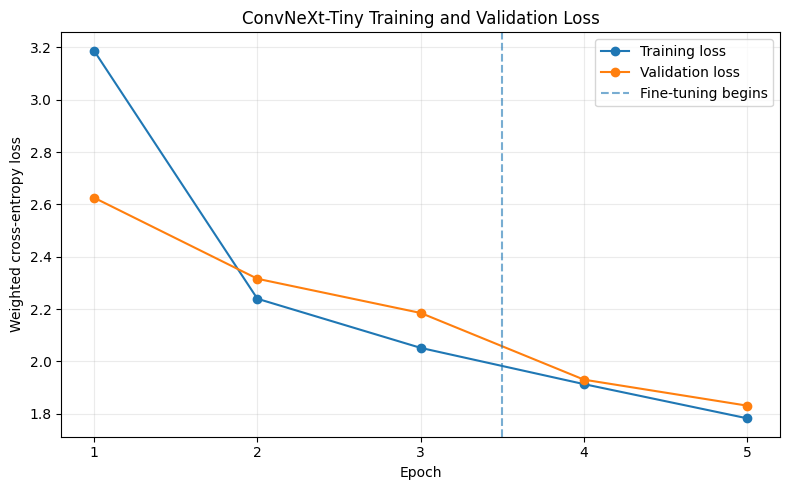

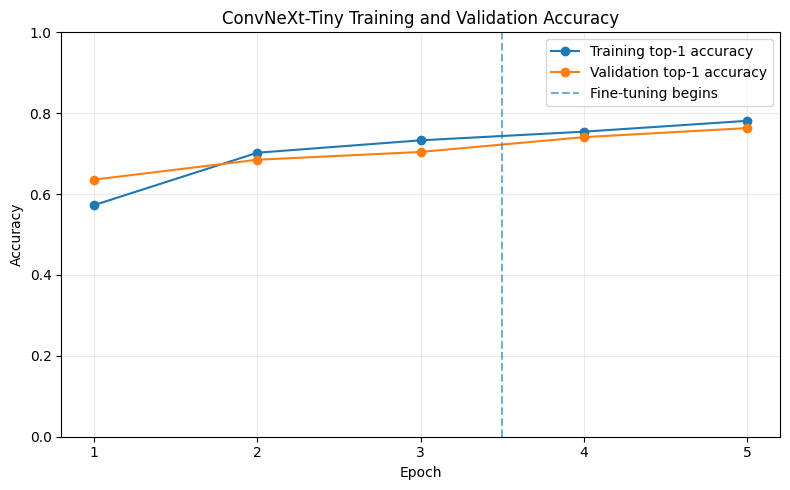

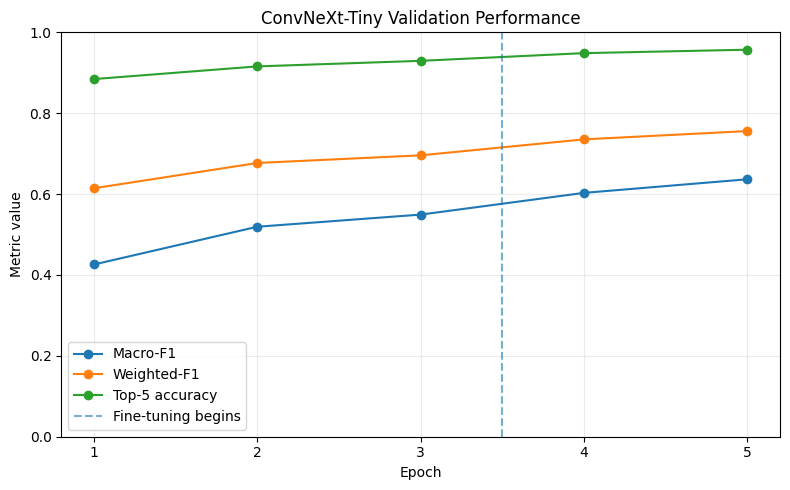


Saved:
/kaggle/working/results/convnext_tiny_loss_curve.pdf
/kaggle/working/results/convnext_tiny_accuracy_curve.pdf
/kaggle/working/results/convnext_tiny_validation_metrics.pdf


In [30]:
convnext_history_df = pd.read_csv(
    OUTPUT_DIR / "convnext_tiny_training_history.csv"
)

print(
    convnext_history_df
    .round(4)
    .to_string(index=False)
)

# Loss
plt.figure(figsize=(8, 5))
plt.plot(
    convnext_history_df["epoch"],
    convnext_history_df["train_loss"],
    marker="o",
    label="Training loss"
)
plt.plot(
    convnext_history_df["epoch"],
    convnext_history_df["validation_loss"],
    marker="o",
    label="Validation loss"
)
plt.axvline(
    x=3.5,
    linestyle="--",
    alpha=0.6,
    label="Fine-tuning begins"
)
plt.xlabel("Epoch")
plt.ylabel("Weighted cross-entropy loss")
plt.title("ConvNeXt-Tiny Training and Validation Loss")
plt.xticks(convnext_history_df["epoch"])
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

convnext_loss_path = (
    OUTPUT_DIR / "convnext_tiny_loss_curve.pdf"
)

plt.savefig(
    convnext_loss_path,
    format="pdf",
    bbox_inches="tight"
)
plt.show()

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    convnext_history_df["epoch"],
    convnext_history_df["train_top1_accuracy"],
    marker="o",
    label="Training top-1 accuracy"
)
plt.plot(
    convnext_history_df["epoch"],
    convnext_history_df["validation_top1_accuracy"],
    marker="o",
    label="Validation top-1 accuracy"
)
plt.axvline(
    x=3.5,
    linestyle="--",
    alpha=0.6,
    label="Fine-tuning begins"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ConvNeXt-Tiny Training and Validation Accuracy")
plt.xticks(convnext_history_df["epoch"])
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

convnext_accuracy_path = (
    OUTPUT_DIR / "convnext_tiny_accuracy_curve.pdf"
)

plt.savefig(
    convnext_accuracy_path,
    format="pdf",
    bbox_inches="tight"
)
plt.show()

# Validation metrics
plt.figure(figsize=(8, 5))
plt.plot(
    convnext_history_df["epoch"],
    convnext_history_df["validation_macro_f1"],
    marker="o",
    label="Macro-F1"
)
plt.plot(
    convnext_history_df["epoch"],
    convnext_history_df["validation_weighted_f1"],
    marker="o",
    label="Weighted-F1"
)
plt.plot(
    convnext_history_df["epoch"],
    convnext_history_df["validation_top5_accuracy"],
    marker="o",
    label="Top-5 accuracy"
)
plt.axvline(
    x=3.5,
    linestyle="--",
    alpha=0.6,
    label="Fine-tuning begins"
)
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("ConvNeXt-Tiny Validation Performance")
plt.xticks(convnext_history_df["epoch"])
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

convnext_metrics_path = (
    OUTPUT_DIR / "convnext_tiny_validation_metrics.pdf"
)

plt.savefig(
    convnext_metrics_path,
    format="pdf",
    bbox_inches="tight"
)
plt.show()

print("\nSaved:")
print(convnext_loss_path)
print(convnext_accuracy_path)
print(convnext_metrics_path)

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    balanced_accuracy_score,
    classification_report
)

@torch.inference_mode()
def evaluate_locked_test(
    model,
    loader,
    loss_function,
    device,
    model_name
):
    model.eval()

    total_loss = 0.0
    total_samples = 0
    top5_correct = 0

    all_targets = []
    all_predictions = []
    all_probabilities = []

    inference_start = time.perf_counter()

    for batch in tqdm(
        loader,
        desc=f"Testing {model_name}"
    ):
        images = batch["image"].to(
            device,
            non_blocking=True
        )

        targets = batch["target"].to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            logits = model(images)
            loss = loss_function(logits, targets)

        probabilities = torch.softmax(
            logits.float(),
            dim=1
        )

        predictions = probabilities.argmax(dim=1)

        top5_indices = probabilities.topk(
            k=5,
            dim=1
        ).indices

        top5_correct += (
            top5_indices == targets.unsqueeze(1)
        ).any(dim=1).sum().item()

        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_targets.append(
            targets.cpu().numpy()
        )
        all_predictions.append(
            predictions.cpu().numpy()
        )
        all_probabilities.append(
            probabilities.cpu().numpy()
        )

    total_inference_time = (
        time.perf_counter() - inference_start
    )

    all_targets = np.concatenate(all_targets)
    all_predictions = np.concatenate(all_predictions)
    all_probabilities = np.concatenate(all_probabilities)

    top1_accuracy = accuracy_score(
        all_targets,
        all_predictions
    )

    top5_accuracy = (
        top5_correct / total_samples
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            all_targets,
            all_predictions,
            average="macro",
            zero_division=0
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            all_targets,
            all_predictions,
            average="weighted",
            zero_division=0
        )
    )

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_predictions
    )

    metrics = {
        "model": model_name,
        "test_loss": total_loss / total_samples,
        "top1_accuracy": top1_accuracy,
        "top5_accuracy": top5_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "balanced_accuracy": balanced_accuracy,
        "total_inference_seconds": total_inference_time,
        "latency_ms_per_symbol": (
            total_inference_time
            / total_samples
            * 1000
        )
    }

    class_report = classification_report(
        all_targets,
        all_predictions,
        labels=list(range(NUM_CLASSES)),
        target_names=[
            index_to_latex[index]
            for index in range(NUM_CLASSES)
        ],
        output_dict=True,
        zero_division=0
    )

    class_report_df = (
        pd.DataFrame(class_report)
        .transpose()
    )

    prediction_df = pd.DataFrame({
        "true_index": all_targets,
        "predicted_index": all_predictions,
        "true_symbol_id": [
            index_to_symbol_id[int(index)]
            for index in all_targets
        ],
        "predicted_symbol_id": [
            index_to_symbol_id[int(index)]
            for index in all_predictions
        ],
        "true_latex": [
            index_to_latex[int(index)]
            for index in all_targets
        ],
        "predicted_latex": [
            index_to_latex[int(index)]
            for index in all_predictions
        ],
        "confidence": all_probabilities.max(axis=1)
    })

    return (
        metrics,
        class_report_df,
        prediction_df,
        all_targets,
        all_predictions,
        all_probabilities
    )

print("Locked-test evaluator created successfully.")

Locked-test evaluator created successfully.


In [32]:
gc.collect()
torch.cuda.empty_cache()

custom_test_model = CustomCNN(
    num_classes=NUM_CLASSES
).to(DEVICE)

custom_checkpoint = torch.load(
    OUTPUT_DIR / "best_custom_cnn.pt",
    map_location=DEVICE,
    weights_only=False
)

custom_test_model.load_state_dict(
    custom_checkpoint["model_state_dict"]
)

(
    custom_test_metrics,
    custom_class_report,
    custom_predictions,
    custom_targets,
    custom_predicted,
    custom_probabilities
) = evaluate_locked_test(
    model=custom_test_model,
    loader=test_loader,
    loss_function=criterion,
    device=DEVICE,
    model_name="Custom CNN"
)

print(pd.Series(custom_test_metrics).to_string())

custom_class_report.to_csv(
    OUTPUT_DIR / "custom_cnn_classification_report.csv"
)

custom_predictions.to_csv(
    OUTPUT_DIR / "custom_cnn_test_predictions.csv",
    index=False
)

np.save(
    OUTPUT_DIR / "custom_cnn_test_probabilities.npy",
    custom_probabilities
)

del custom_test_model
gc.collect()
torch.cuda.empty_cache()

Testing Custom CNN:   0%|          | 0/67 [00:00<?, ?it/s]

model                      Custom CNN
test_loss                    1.636275
top1_accuracy                0.811146
top5_accuracy                0.981403
macro_precision              0.710445
macro_recall                 0.706833
macro_f1                     0.685933
weighted_precision           0.808567
weighted_recall              0.811146
weighted_f1                  0.794877
balanced_accuracy            0.706833
total_inference_seconds     33.444232
latency_ms_per_symbol        1.968234


In [33]:
efficientnet_test_model = models.efficientnet_v2_s(
    weights=None
)

efficientnet_input_features = (
    efficientnet_test_model.classifier[1].in_features
)

efficientnet_test_model.classifier[1] = nn.Linear(
    efficientnet_input_features,
    NUM_CLASSES
)

efficientnet_checkpoint = torch.load(
    OUTPUT_DIR / "best_efficientnet_v2_s.pt",
    map_location=DEVICE,
    weights_only=False
)

efficientnet_test_model.load_state_dict(
    efficientnet_checkpoint["model_state_dict"]
)

efficientnet_test_model = (
    efficientnet_test_model.to(DEVICE)
)

(
    efficientnet_test_metrics,
    efficientnet_class_report,
    efficientnet_predictions,
    efficientnet_targets,
    efficientnet_predicted,
    efficientnet_probabilities
) = evaluate_locked_test(
    model=efficientnet_test_model,
    loader=transfer_test_loader,
    loss_function=criterion,
    device=DEVICE,
    model_name="EfficientNetV2-S"
)

print(
    pd.Series(
        efficientnet_test_metrics
    ).to_string()
)

efficientnet_class_report.to_csv(
    OUTPUT_DIR /
    "efficientnet_v2_s_classification_report.csv"
)

efficientnet_predictions.to_csv(
    OUTPUT_DIR /
    "efficientnet_v2_s_test_predictions.csv",
    index=False
)

np.save(
    OUTPUT_DIR /
    "efficientnet_v2_s_test_probabilities.npy",
    efficientnet_probabilities
)

del efficientnet_test_model
gc.collect()
torch.cuda.empty_cache()

Testing EfficientNetV2-S:   0%|          | 0/133 [00:00<?, ?it/s]

model                      EfficientNetV2-S
test_loss                          1.749882
top1_accuracy                      0.783545
top5_accuracy                      0.967514
macro_precision                    0.682576
macro_recall                       0.677292
macro_f1                           0.665014
weighted_precision                 0.776776
weighted_recall                    0.783545
weighted_f1                         0.77271
balanced_accuracy                  0.677292
total_inference_seconds           15.703792
latency_ms_per_symbol              0.924187


In [34]:
convnext_test_model = models.convnext_tiny(
    weights=None
)

convnext_input_features = (
    convnext_test_model.classifier[2].in_features
)

convnext_test_model.classifier[2] = nn.Linear(
    convnext_input_features,
    NUM_CLASSES
)

convnext_checkpoint = torch.load(
    OUTPUT_DIR / "best_convnext_tiny.pt",
    map_location=DEVICE,
    weights_only=False
)

convnext_test_model.load_state_dict(
    convnext_checkpoint["model_state_dict"]
)

convnext_test_model = (
    convnext_test_model.to(DEVICE)
)

(
    convnext_test_metrics,
    convnext_class_report,
    convnext_predictions,
    convnext_targets,
    convnext_predicted,
    convnext_probabilities
) = evaluate_locked_test(
    model=convnext_test_model,
    loader=transfer_test_loader,
    loss_function=criterion,
    device=DEVICE,
    model_name="ConvNeXt-Tiny"
)

print(
    pd.Series(
        convnext_test_metrics
    ).to_string()
)

convnext_class_report.to_csv(
    OUTPUT_DIR /
    "convnext_tiny_classification_report.csv"
)

convnext_predictions.to_csv(
    OUTPUT_DIR /
    "convnext_tiny_test_predictions.csv",
    index=False
)

np.save(
    OUTPUT_DIR /
    "convnext_tiny_test_probabilities.npy",
    convnext_probabilities
)

del convnext_test_model
gc.collect()
torch.cuda.empty_cache()

Testing ConvNeXt-Tiny:   0%|          | 0/133 [00:00<?, ?it/s]

model                      ConvNeXt-Tiny
test_loss                        1.83651
top1_accuracy                   0.768185
top5_accuracy                     0.9621
macro_precision                 0.662163
macro_recall                    0.665819
macro_f1                         0.64741
weighted_precision              0.769084
weighted_recall                 0.768185
weighted_f1                     0.760407
balanced_accuracy               0.665819
total_inference_seconds        21.119561
latency_ms_per_symbol           1.242912


In [35]:
model_comparison_df = pd.DataFrame([
    custom_test_metrics,
    efficientnet_test_metrics,
    convnext_test_metrics
])

# Add architecture information.
architecture_information = {
    "Custom CNN": {
        "parameters": 1_333_841,
        "estimated_fp32_mb": 5.09,
        "best_validation_macro_f1": 0.6815,
        "best_epoch": 6
    },
    "EfficientNetV2-S": {
        "parameters": 20_650_177,
        "estimated_fp32_mb": 78.77,
        "best_validation_macro_f1": 0.6444,
        "best_epoch": 5
    },
    "ConvNeXt-Tiny": {
        "parameters": 28_103_889,
        "estimated_fp32_mb": 107.21,
        "best_validation_macro_f1": 0.6366,
        "best_epoch": 5
    }
}

model_comparison_df["parameters"] = (
    model_comparison_df["model"]
    .map(
        lambda name:
        architecture_information[name]["parameters"]
    )
)

model_comparison_df["estimated_fp32_mb"] = (
    model_comparison_df["model"]
    .map(
        lambda name:
        architecture_information[name][
            "estimated_fp32_mb"
        ]
    )
)

model_comparison_df[
    "best_validation_macro_f1"
] = (
    model_comparison_df["model"]
    .map(
        lambda name:
        architecture_information[name][
            "best_validation_macro_f1"
        ]
    )
)

model_comparison_df["best_epoch"] = (
    model_comparison_df["model"]
    .map(
        lambda name:
        architecture_information[name][
            "best_epoch"
        ]
    )
)

model_comparison_df.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False
)

print(
    model_comparison_df
    .round(4)
    .to_string(index=False)
)

           model  test_loss  top1_accuracy  top5_accuracy  macro_precision  macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1  balanced_accuracy  total_inference_seconds  latency_ms_per_symbol  parameters  estimated_fp32_mb  best_validation_macro_f1  best_epoch
      Custom CNN     1.6363         0.8111         0.9814           0.7104        0.7068    0.6859              0.8086           0.8111       0.7949             0.7068                  33.4442                 1.9682     1333841               5.09                    0.6815           6
EfficientNetV2-S     1.7499         0.7835         0.9675           0.6826        0.6773    0.6650              0.7768           0.7835       0.7727             0.6773                  15.7038                 0.9242    20650177              78.77                    0.6444           5
   ConvNeXt-Tiny     1.8365         0.7682         0.9621           0.6622        0.6658    0.6474              0.7691           0.7682       0.7

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

# =========================================================
# Create class-frequency groups from development counts
# =========================================================
class_frequency_df = (
    class_table[["symbol_id", "latex"]]
    .copy()
)

class_frequency_df["class_index"] = (
    class_frequency_df["symbol_id"]
    .map(symbol_id_to_index)
)

class_frequency_df["development_count"] = (
    class_frequency_df["symbol_id"]
    .map(
        development_df["symbol_id"]
        .value_counts()
    )
    .fillna(0)
    .astype(int)
)

# Tertile-based frequency groups.
class_frequency_df["frequency_group"] = pd.qcut(
    class_frequency_df["development_count"],
    q=3,
    labels=[
        "Low frequency",
        "Medium frequency",
        "High frequency"
    ]
)

print("=" * 80)
print("CLASS-FREQUENCY GROUPS")
print("=" * 80)

print(
    class_frequency_df
    .groupby(
        "frequency_group",
        observed=True
    )["development_count"]
    .agg([
        "count",
        "min",
        "median",
        "max"
    ])
)

class_frequency_df.to_csv(
    OUTPUT_DIR / "class_frequency_groups.csv",
    index=False
)

CLASS-FREQUENCY GROUPS
                  count  min  median   max
frequency_group                           
Low frequency       123   41    80.0   116
Medium frequency    123  118   180.0   316
High frequency      123  318   708.0  2846


In [37]:
def evaluate_frequency_groups(
    model_name,
    targets,
    predictions,
    frequency_table
):
    results = []

    index_to_group = (
        frequency_table
        .set_index("class_index")[
            "frequency_group"
        ]
        .astype(str)
        .to_dict()
    )

    sample_groups = np.array([
        index_to_group[int(target)]
        for target in targets
    ])

    for group_name in [
        "Low frequency",
        "Medium frequency",
        "High frequency"
    ]:
        sample_mask = (
            sample_groups == group_name
        )

        group_targets = targets[sample_mask]
        group_predictions = predictions[sample_mask]

        precision, recall, f1, _ = (
            precision_recall_fscore_support(
                group_targets,
                group_predictions,
                labels=sorted(
                    frequency_table.loc[
                        frequency_table[
                            "frequency_group"
                        ].astype(str) == group_name,
                        "class_index"
                    ].tolist()
                ),
                average="macro",
                zero_division=0
            )
        )

        group_accuracy = accuracy_score(
            group_targets,
            group_predictions
        )

        number_of_classes = int(
            (
                frequency_table[
                    "frequency_group"
                ].astype(str) == group_name
            ).sum()
        )

        results.append({
            "model": model_name,
            "frequency_group": group_name,
            "number_of_classes": number_of_classes,
            "number_of_test_samples": int(
                sample_mask.sum()
            ),
            "top1_accuracy": group_accuracy,
            "macro_precision": precision,
            "macro_recall": recall,
            "macro_f1": f1
        })

    return pd.DataFrame(results)


custom_frequency_results = evaluate_frequency_groups(
    "Custom CNN",
    custom_targets,
    custom_predicted,
    class_frequency_df
)

efficientnet_frequency_results = evaluate_frequency_groups(
    "EfficientNetV2-S",
    efficientnet_targets,
    efficientnet_predicted,
    class_frequency_df
)

convnext_frequency_results = evaluate_frequency_groups(
    "ConvNeXt-Tiny",
    convnext_targets,
    convnext_predicted,
    class_frequency_df
)

frequency_results_df = pd.concat(
    [
        custom_frequency_results,
        efficientnet_frequency_results,
        convnext_frequency_results
    ],
    ignore_index=True
)

frequency_results_df.to_csv(
    OUTPUT_DIR / "frequency_group_results.csv",
    index=False
)

print(
    frequency_results_df
    .round(4)
    .to_string(index=False)
)

           model  frequency_group  number_of_classes  number_of_test_samples  top1_accuracy  macro_precision  macro_recall  macro_f1
      Custom CNN    Low frequency                123                    1209         0.6460           0.7878        0.6145    0.6637
      Custom CNN Medium frequency                123                    2990         0.6806           0.8465        0.6791    0.7193
      Custom CNN   High frequency                123                   12793         0.8573           0.8832        0.8269    0.8400
EfficientNetV2-S    Low frequency                123                    1209         0.6046           0.7956        0.5813    0.6520
EfficientNetV2-S Medium frequency                123                    2990         0.6425           0.8533        0.6409    0.7018
EfficientNetV2-S   High frequency                123                   12793         0.8334           0.8611        0.8096    0.8284
   ConvNeXt-Tiny    Low frequency                123                 

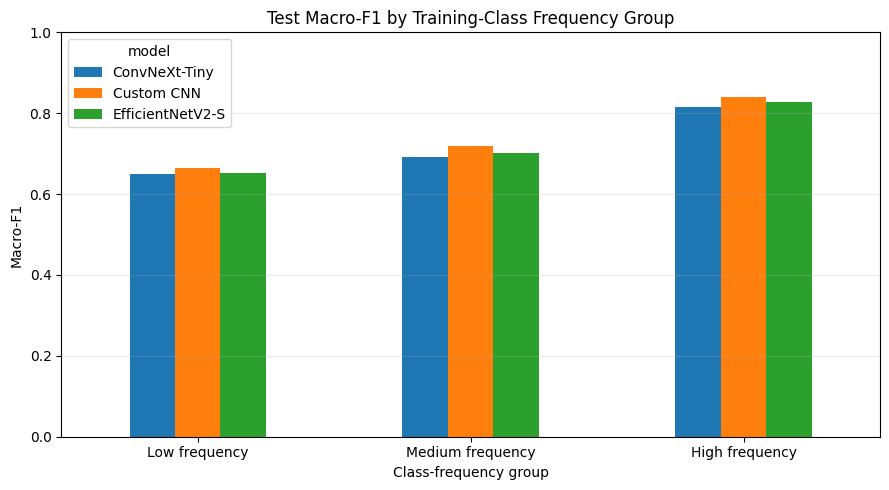

Saved: /kaggle/working/results/frequency_group_macro_f1.pdf


In [38]:
# =========================================================
# Frequency-group macro-F1 comparison
# =========================================================
frequency_plot_table = (
    frequency_results_df
    .pivot(
        index="frequency_group",
        columns="model",
        values="macro_f1"
    )
    .reindex([
        "Low frequency",
        "Medium frequency",
        "High frequency"
    ])
)

axis = frequency_plot_table.plot(
    kind="bar",
    figsize=(9, 5)
)

axis.set_xlabel("Class-frequency group")
axis.set_ylabel("Macro-F1")
axis.set_title(
    "Test Macro-F1 by Training-Class Frequency Group"
)
axis.set_ylim(0, 1)
axis.tick_params(
    axis="x",
    rotation=0
)
axis.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

frequency_figure_path = (
    OUTPUT_DIR / "frequency_group_macro_f1.pdf"
)

plt.savefig(
    frequency_figure_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved:", frequency_figure_path)

In [39]:
from sklearn.metrics import confusion_matrix

custom_confusion = confusion_matrix(
    custom_targets,
    custom_predicted,
    labels=list(range(NUM_CLASSES))
)

efficientnet_confusion = confusion_matrix(
    efficientnet_targets,
    efficientnet_predicted,
    labels=list(range(NUM_CLASSES))
)

convnext_confusion = confusion_matrix(
    convnext_targets,
    convnext_predicted,
    labels=list(range(NUM_CLASSES))
)

np.save(
    OUTPUT_DIR / "custom_cnn_confusion_matrix.npy",
    custom_confusion
)

np.save(
    OUTPUT_DIR /
    "efficientnet_v2_s_confusion_matrix.npy",
    efficientnet_confusion
)

np.save(
    OUTPUT_DIR /
    "convnext_tiny_confusion_matrix.npy",
    convnext_confusion
)

print("Confusion matrix shape:", custom_confusion.shape)
print(
    "Custom CNN total predictions:",
    custom_confusion.sum()
)
print(
    "EfficientNet total predictions:",
    efficientnet_confusion.sum()
)
print(
    "ConvNeXt total predictions:",
    convnext_confusion.sum()
)

Confusion matrix shape: (369, 369)
Custom CNN total predictions: 16992
EfficientNet total predictions: 16992
ConvNeXt total predictions: 16992


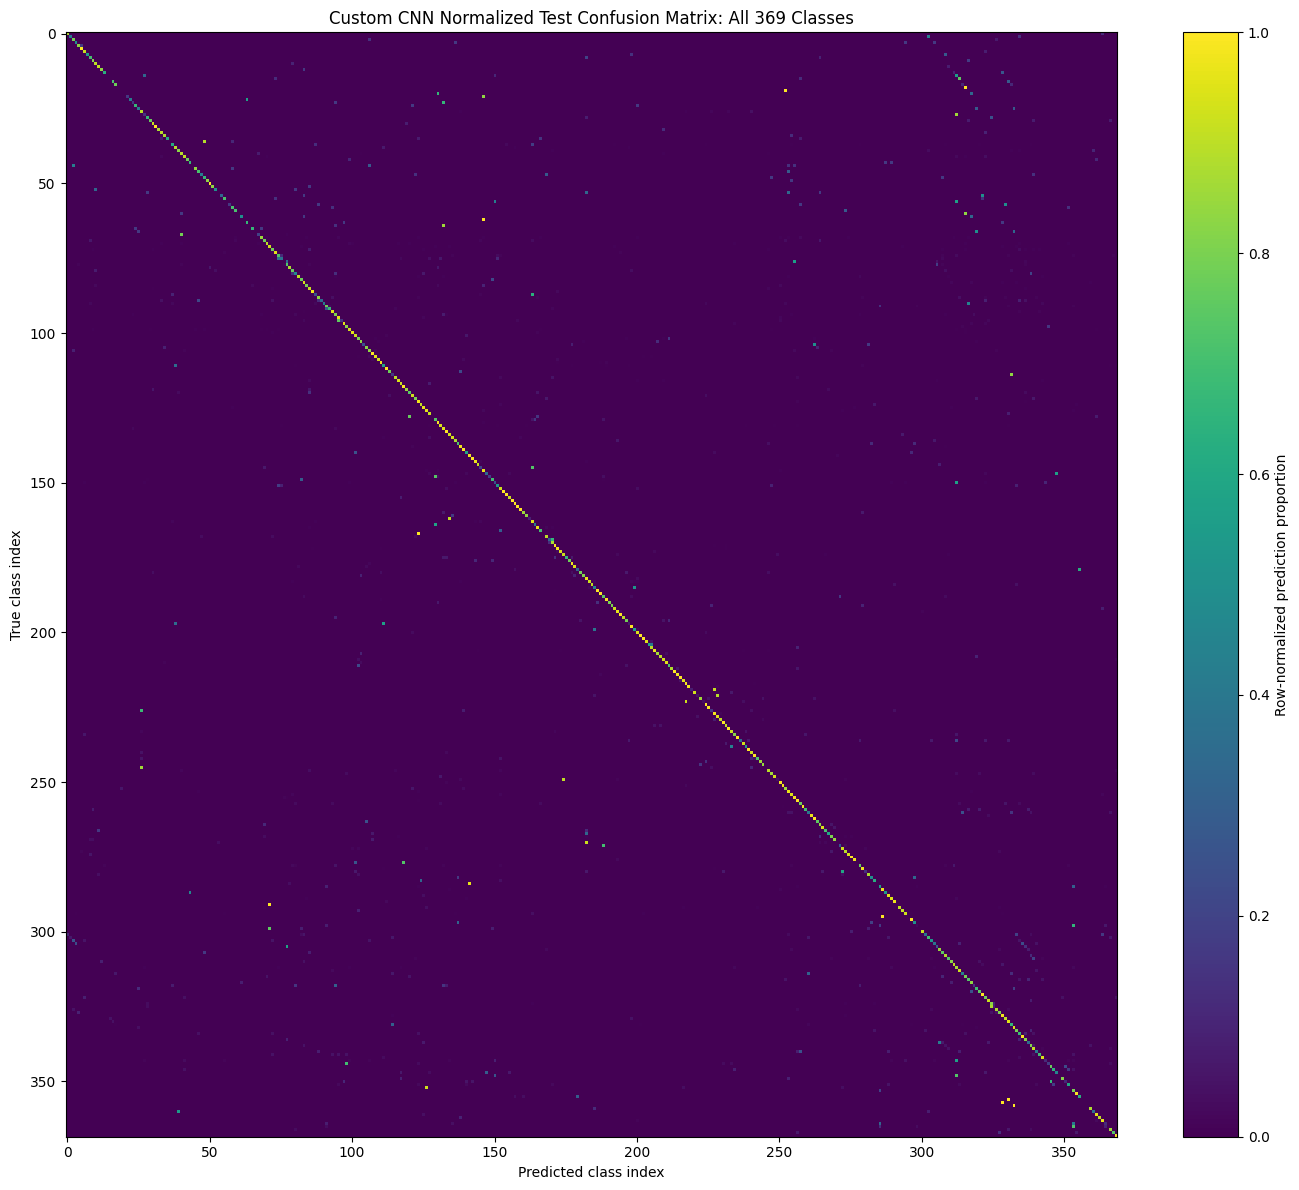

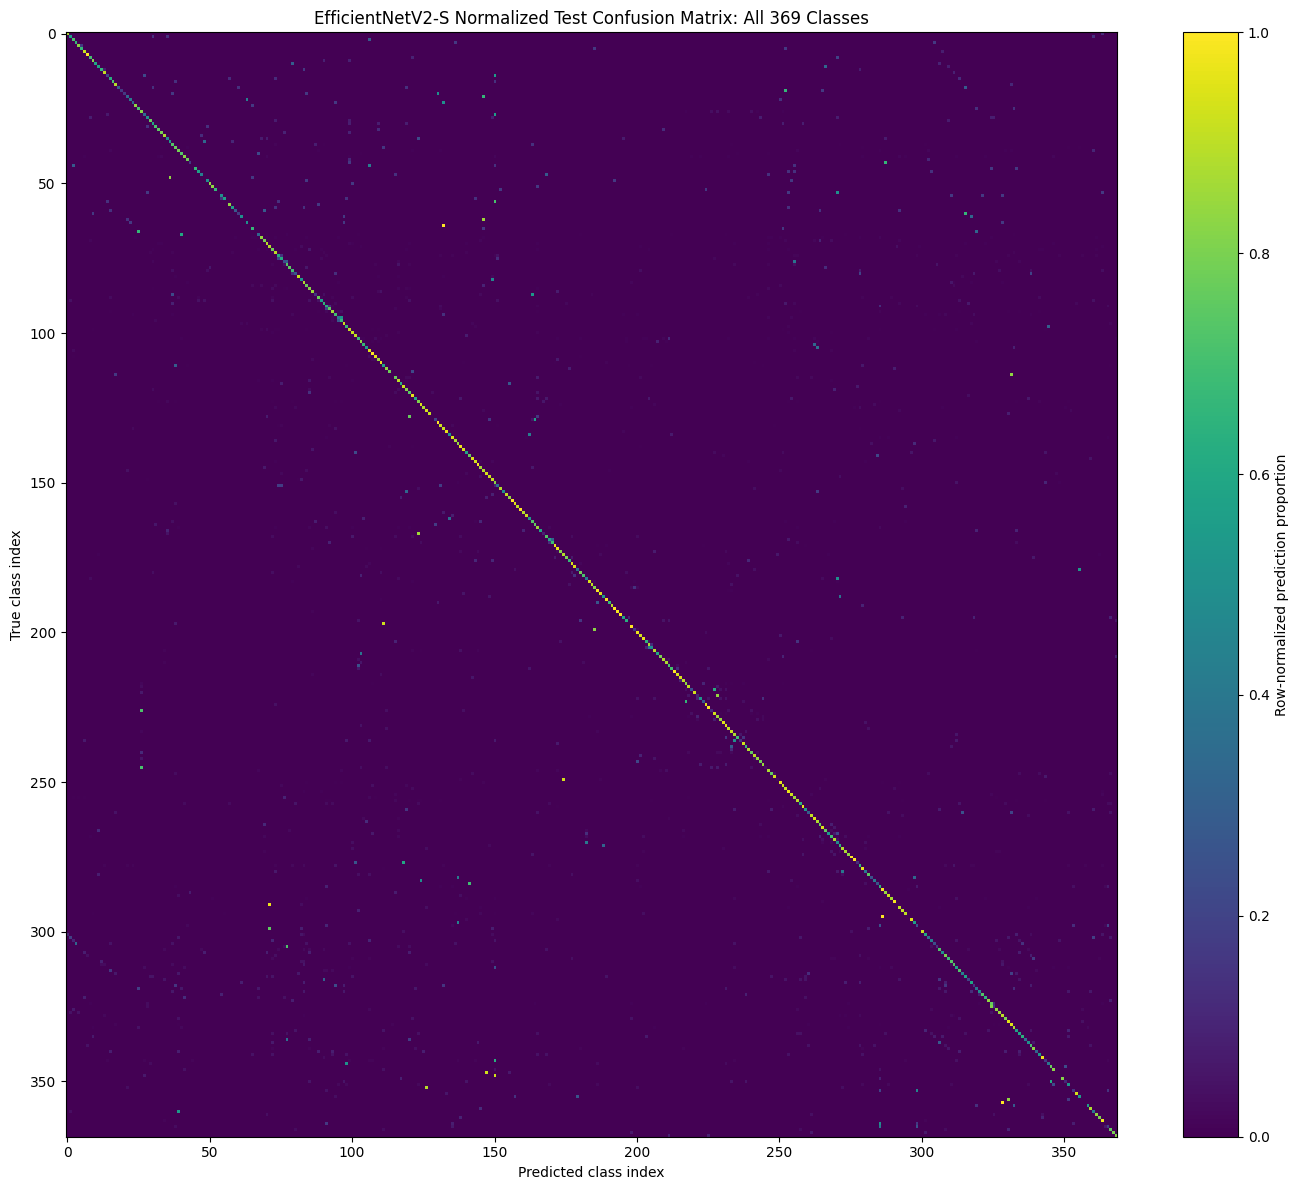

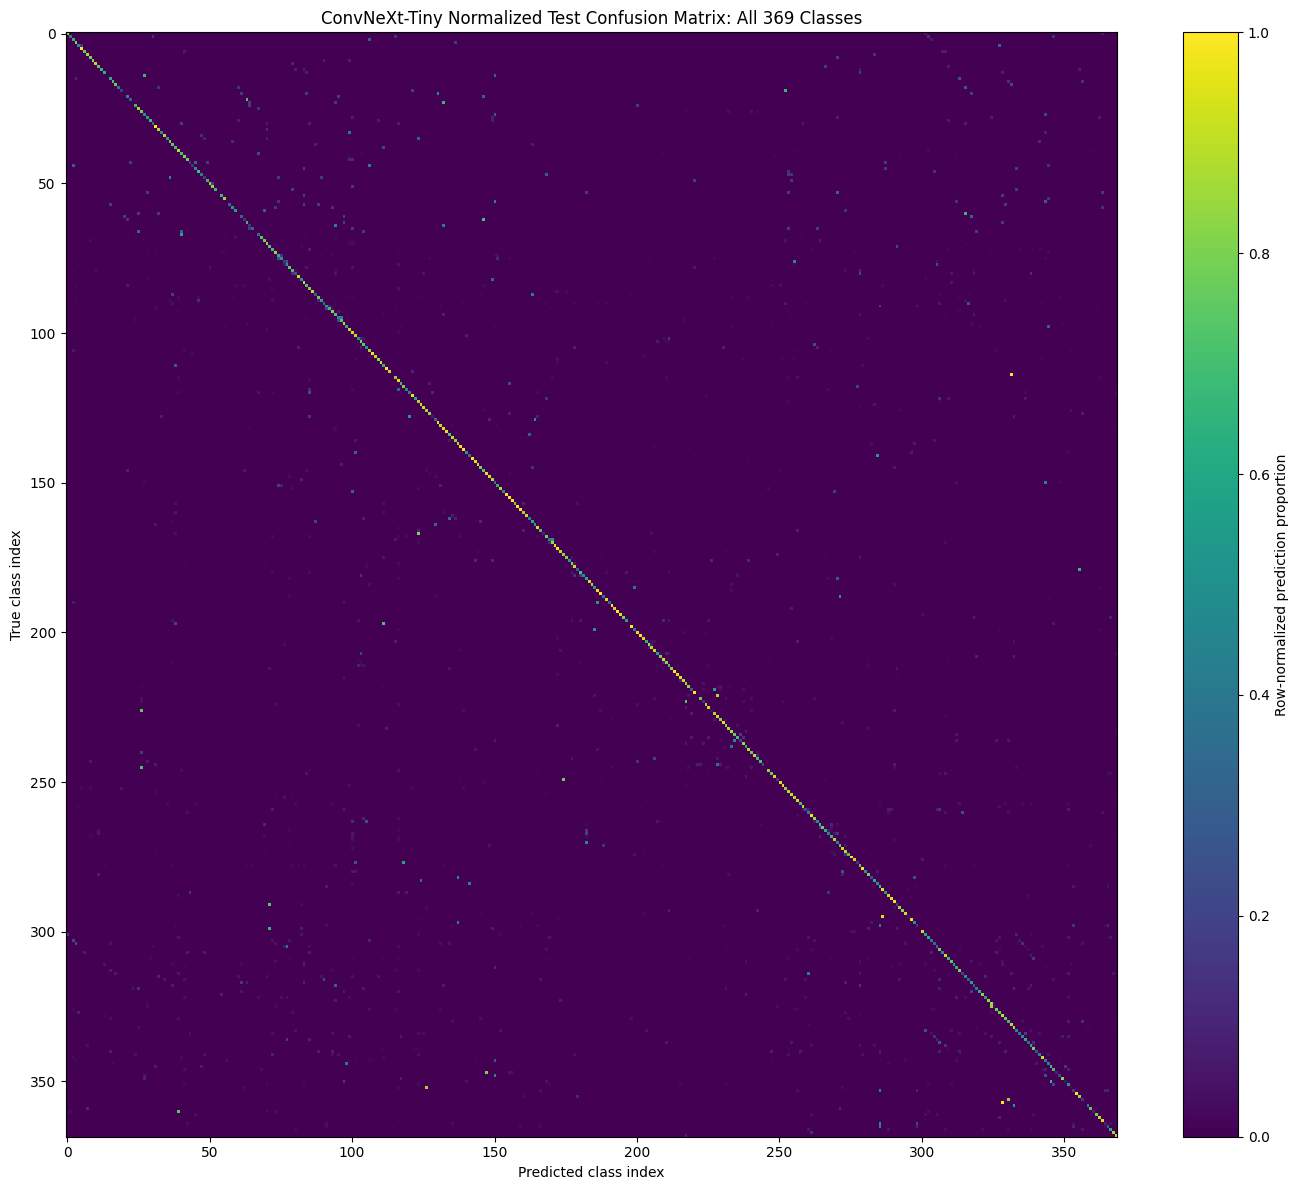

/kaggle/working/results/custom_cnn_confusion_matrix_full.pdf
/kaggle/working/results/efficientnet_v2_s_confusion_matrix_full.pdf
/kaggle/working/results/convnext_tiny_confusion_matrix_full.pdf


In [40]:
def save_full_confusion_matrix(
    confusion_array,
    title,
    filename
):
    row_totals = confusion_array.sum(
        axis=1,
        keepdims=True
    )

    normalized = np.divide(
        confusion_array,
        row_totals,
        out=np.zeros_like(
            confusion_array,
            dtype=float
        ),
        where=row_totals != 0
    )

    plt.figure(figsize=(14, 12))

    plt.imshow(
        normalized,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(
        label="Row-normalized prediction proportion"
    )

    plt.xlabel("Predicted class index")
    plt.ylabel("True class index")
    plt.title(title)

    plt.tight_layout()

    output_path = OUTPUT_DIR / filename

    plt.savefig(
        output_path,
        format="pdf",
        bbox_inches="tight"
    )

    plt.show()

    return output_path


custom_full_cm_path = save_full_confusion_matrix(
    custom_confusion,
    "Custom CNN Normalized Test Confusion Matrix: All 369 Classes",
    "custom_cnn_confusion_matrix_full.pdf"
)

efficientnet_full_cm_path = save_full_confusion_matrix(
    efficientnet_confusion,
    "EfficientNetV2-S Normalized Test Confusion Matrix: All 369 Classes",
    "efficientnet_v2_s_confusion_matrix_full.pdf"
)

convnext_full_cm_path = save_full_confusion_matrix(
    convnext_confusion,
    "ConvNeXt-Tiny Normalized Test Confusion Matrix: All 369 Classes",
    "convnext_tiny_confusion_matrix_full.pdf"
)

print(custom_full_cm_path)
print(efficientnet_full_cm_path)
print(convnext_full_cm_path)

In [41]:
def extract_top_confusions(
    confusion_array,
    model_name,
    top_n=30
):
    confusion_without_diagonal = (
        confusion_array.copy()
    )

    np.fill_diagonal(
        confusion_without_diagonal,
        0
    )

    true_indices, predicted_indices = (
        np.unravel_index(
            np.argsort(
                confusion_without_diagonal,
                axis=None
            )[::-1],
            confusion_without_diagonal.shape
        )
    )

    records = []

    for true_index, predicted_index in zip(
        true_indices,
        predicted_indices
    ):
        count = int(
            confusion_without_diagonal[
                true_index,
                predicted_index
            ]
        )

        if count == 0:
            break

        true_total = int(
            confusion_array[
                true_index
            ].sum()
        )

        records.append({
            "model": model_name,
            "true_index": int(true_index),
            "true_symbol_id": int(
                index_to_symbol_id[
                    int(true_index)
                ]
            ),
            "true_latex": (
                index_to_latex[
                    int(true_index)
                ]
            ),
            "predicted_index": int(
                predicted_index
            ),
            "predicted_symbol_id": int(
                index_to_symbol_id[
                    int(predicted_index)
                ]
            ),
            "predicted_latex": (
                index_to_latex[
                    int(predicted_index)
                ]
            ),
            "confusion_count": count,
            "true_class_test_count": true_total,
            "confusion_rate_within_true_class": (
                count / true_total
                if true_total > 0
                else 0
            )
        })

        if len(records) >= top_n:
            break

    return pd.DataFrame(records)


custom_top_confusions = extract_top_confusions(
    custom_confusion,
    "Custom CNN"
)

efficientnet_top_confusions = extract_top_confusions(
    efficientnet_confusion,
    "EfficientNetV2-S"
)

convnext_top_confusions = extract_top_confusions(
    convnext_confusion,
    "ConvNeXt-Tiny"
)

all_top_confusions = pd.concat(
    [
        custom_top_confusions,
        efficientnet_top_confusions,
        convnext_top_confusions
    ],
    ignore_index=True
)

all_top_confusions.to_csv(
    OUTPUT_DIR / "top_confusion_pairs.csv",
    index=False
)

print("=" * 100)
print("TOP 20 CUSTOM CNN CONFUSION PAIRS")
print("=" * 100)

print(
    custom_top_confusions
    .head(20)
    .round(4)
    .to_string(index=False)
)

TOP 20 CUSTOM CNN CONFUSION PAIRS
     model  true_index  true_symbol_id  true_latex  predicted_index  predicted_symbol_id predicted_latex  confusion_count  true_class_test_count  confusion_rate_within_true_class
Custom CNN          67             116      \Sigma               40                   88            \sum              151                    191                            0.7906
Custom CNN         331            1066  \mathds{R}              114                  197      \mathbb{R}               73                    238                            0.3067
Custom CNN         249             881        \bot              174                  605           \perp               67                     74                            0.9054
Custom CNN         150             537       \circ              312                 1007     \mathcal{O}               56                     98                            0.5714
Custom CNN          87             168         \Pi              163    

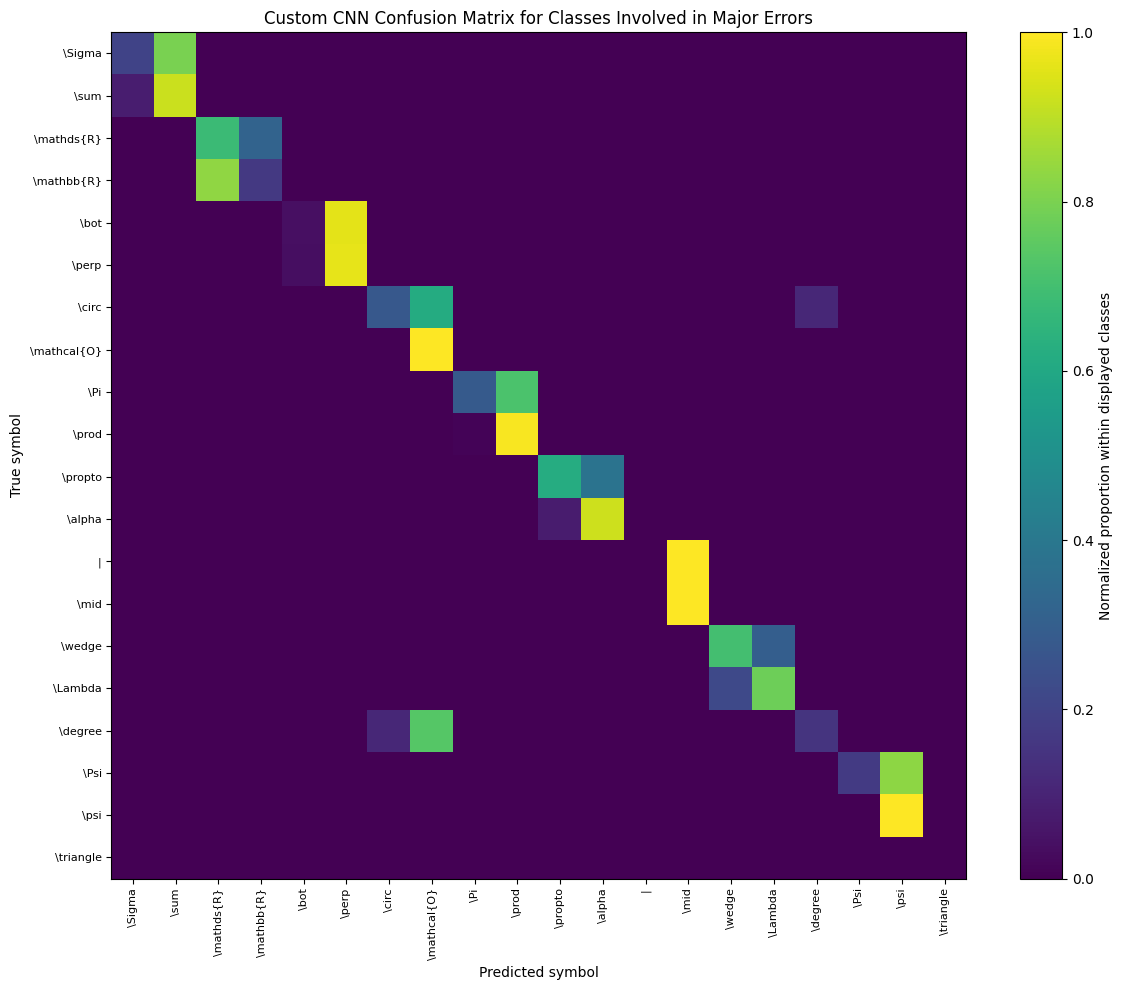

Displayed classes:
['\\Sigma', '\\sum', '\\mathds{R}', '\\mathbb{R}', '\\bot', '\\perp', '\\circ', '\\mathcal{O}', '\\Pi', '\\prod', '\\propto', '\\alpha', '|', '\\mid', '\\wedge', '\\Lambda', '\\degree', '\\Psi', '\\psi', '\\triangle']
Saved: /kaggle/working/results/custom_cnn_confusion_matrix_major_classes.pdf


In [42]:
# =========================================================
# Select classes involved in major confusion pairs
# =========================================================
major_confusion_indices = []

for _, row in custom_top_confusions.iterrows():
    for index_value in [
        int(row["true_index"]),
        int(row["predicted_index"])
    ]:
        if (
            index_value
            not in major_confusion_indices
        ):
            major_confusion_indices.append(
                index_value
            )

    if len(major_confusion_indices) >= 20:
        break

major_confusion_indices = (
    major_confusion_indices[:20]
)

readable_confusion = (
    custom_confusion[
        np.ix_(
            major_confusion_indices,
            major_confusion_indices
        )
    ]
)

row_totals = readable_confusion.sum(
    axis=1,
    keepdims=True
)

readable_normalized = np.divide(
    readable_confusion,
    row_totals,
    out=np.zeros_like(
        readable_confusion,
        dtype=float
    ),
    where=row_totals != 0
)

readable_labels = [
    index_to_latex[index]
    for index in major_confusion_indices
]

plt.figure(figsize=(12, 10))

plt.imshow(
    readable_normalized,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Normalized proportion within displayed classes"
)

plt.xticks(
    ticks=range(len(readable_labels)),
    labels=readable_labels,
    rotation=90,
    fontsize=8
)

plt.yticks(
    ticks=range(len(readable_labels)),
    labels=readable_labels,
    fontsize=8
)

plt.xlabel("Predicted symbol")
plt.ylabel("True symbol")
plt.title(
    "Custom CNN Confusion Matrix for Classes Involved in Major Errors"
)

plt.tight_layout()

readable_confusion_path = (
    OUTPUT_DIR /
    "custom_cnn_confusion_matrix_major_classes.pdf"
)

plt.savefig(
    readable_confusion_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Displayed classes:")
print(readable_labels)

print("Saved:", readable_confusion_path)

In [43]:
def prepare_class_performance(
    class_report_df,
    model_name
):
    class_rows = class_report_df.iloc[
        :NUM_CLASSES
    ].copy()

    class_rows = class_rows.reset_index(
        drop=True
    )

    class_rows["class_index"] = range(
        NUM_CLASSES
    )

    class_rows["symbol_id"] = (
        class_rows["class_index"]
        .map(index_to_symbol_id)
    )

    class_rows["latex"] = (
        class_rows["class_index"]
        .map(index_to_latex)
    )

    class_rows["model"] = model_name

    return class_rows


custom_class_performance = prepare_class_performance(
    custom_class_report,
    "Custom CNN"
)

efficientnet_class_performance = prepare_class_performance(
    efficientnet_class_report,
    "EfficientNetV2-S"
)

convnext_class_performance = prepare_class_performance(
    convnext_class_report,
    "ConvNeXt-Tiny"
)

complete_class_performance = pd.concat(
    [
        custom_class_performance,
        efficientnet_class_performance,
        convnext_class_performance
    ],
    ignore_index=True
)

complete_class_performance.to_csv(
    OUTPUT_DIR / "all_models_per_class_results.csv",
    index=False
)

custom_ranked_classes = (
    custom_class_performance
    .sort_values(
        ["f1-score", "support"],
        ascending=[False, False]
    )
)

print("=" * 90)
print("CUSTOM CNN — 15 BEST CLASSES BY F1")
print("=" * 90)

print(
    custom_ranked_classes[
        [
            "latex",
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
    .head(15)
    .round(4)
    .to_string(index=False)
)

print("\n" + "=" * 90)
print("CUSTOM CNN — 15 WORST CLASSES BY F1")
print("=" * 90)

print(
    custom_ranked_classes[
        [
            "latex",
            "precision",
            "recall",
            "f1-score",
            "support"
        ]
    ]
    .tail(15)
    .sort_values("f1-score")
    .round(4)
    .to_string(index=False)
)

CUSTOM CNN — 15 BEST CLASSES BY F1
              latex  precision  recall  f1-score  support
            \boxdot     1.0000  1.0000    1.0000     13.0
   \rightleftarrows     1.0000  1.0000    1.0000     13.0
                  4     1.0000  1.0000    1.0000      7.0
                \wr     1.0000  1.0000    1.0000      6.0
\blacktriangleright     1.0000  1.0000    1.0000      6.0
            \exists     1.0000  0.9929    0.9964    141.0
               \sim     0.9901  0.9950    0.9926    201.0
    \hookrightarrow     1.0000  0.9851    0.9925     67.0
             \equiv     0.9842  0.9881    0.9861    252.0
            \approx     0.9807  0.9902    0.9854    205.0
           \nexists     1.0000  0.9688    0.9841     32.0
         \triangleq     0.9825  0.9825    0.9825     57.0
               \neq     0.9868  0.9739    0.9803    153.0
                \ni     0.9796  0.9796    0.9796     49.0
             \infty     0.9794  0.9760    0.9777    292.0

CUSTOM CNN — 15 WORST CLASSES BY F1


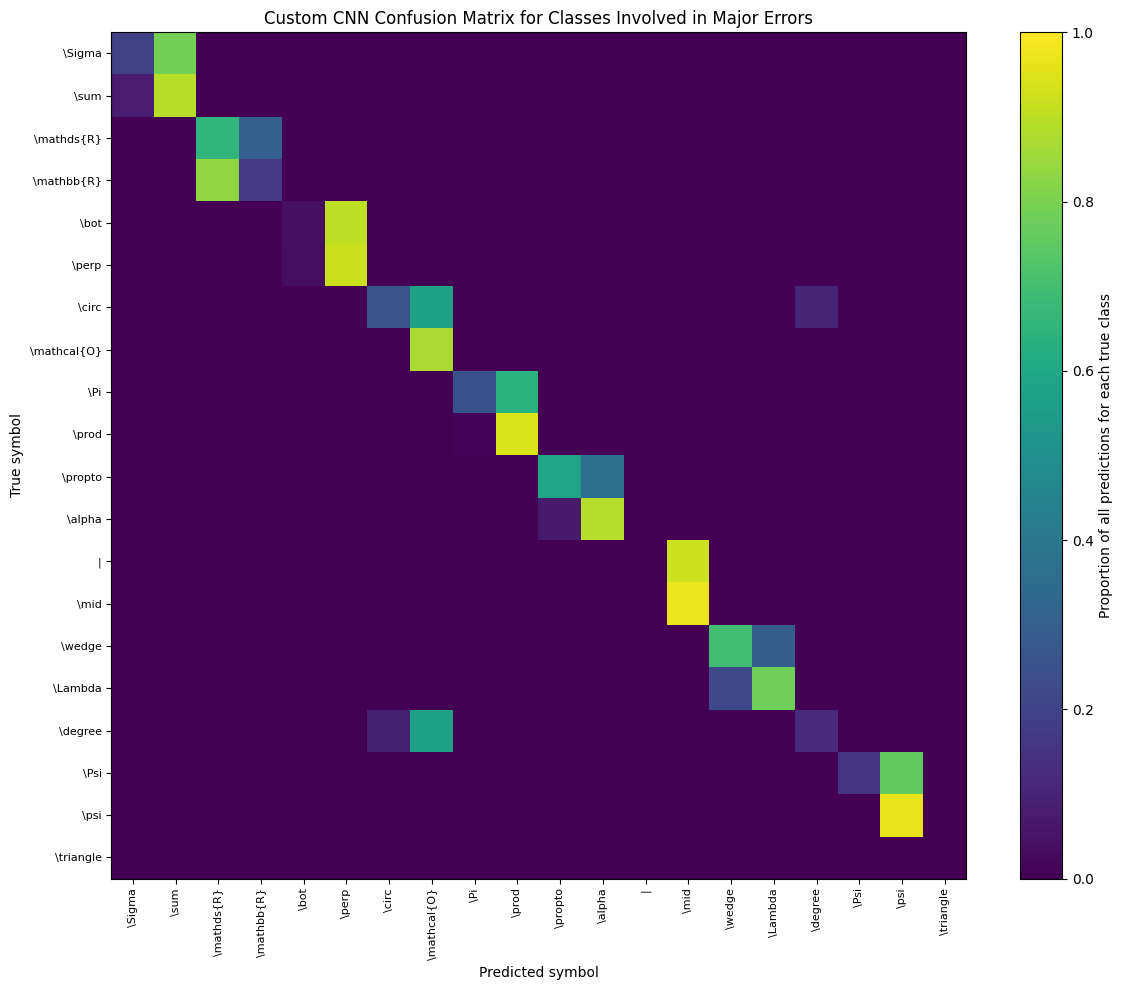

Corrected figure saved to:
/kaggle/working/results/custom_cnn_confusion_matrix_major_classes_corrected.pdf


In [44]:
# =========================================================
# Corrected readable confusion matrix
# The denominator uses every prediction for each true class,
# including predictions outside the displayed subset.
# =========================================================

major_confusion_indices = []

for _, row in custom_top_confusions.iterrows():
    for index_value in [
        int(row["true_index"]),
        int(row["predicted_index"])
    ]:
        if index_value not in major_confusion_indices:
            major_confusion_indices.append(index_value)

    if len(major_confusion_indices) >= 20:
        break

major_confusion_indices = major_confusion_indices[:20]

readable_confusion = custom_confusion[
    np.ix_(
        major_confusion_indices,
        major_confusion_indices
    )
]

# Use totals from the complete 369-column matrix.
full_true_class_totals = custom_confusion[
    major_confusion_indices,
    :
].sum(axis=1, keepdims=True)

readable_normalized_corrected = np.divide(
    readable_confusion,
    full_true_class_totals,
    out=np.zeros_like(
        readable_confusion,
        dtype=float
    ),
    where=full_true_class_totals != 0
)

readable_labels = [
    index_to_latex[index]
    for index in major_confusion_indices
]

plt.figure(figsize=(12, 10))

plt.imshow(
    readable_normalized_corrected,
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=1
)

plt.colorbar(
    label="Proportion of all predictions for each true class"
)

plt.xticks(
    range(len(readable_labels)),
    readable_labels,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(readable_labels)),
    readable_labels,
    fontsize=8
)

plt.xlabel("Predicted symbol")
plt.ylabel("True symbol")
plt.title(
    "Custom CNN Confusion Matrix for Classes Involved in Major Errors"
)

plt.tight_layout()

corrected_readable_path = (
    OUTPUT_DIR /
    "custom_cnn_confusion_matrix_major_classes_corrected.pdf"
)

plt.savefig(
    corrected_readable_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Corrected figure saved to:")
print(corrected_readable_path)

In [45]:
import os
import time
import gc
import torch
import torch.nn as nn
import pandas as pd
from torchvision import models

# =========================================================
# Model constructors
# =========================================================

def build_custom_cnn_for_test():
    model = CustomCNN(num_classes=NUM_CLASSES)

    checkpoint = torch.load(
        OUTPUT_DIR / "best_custom_cnn.pt",
        map_location="cpu",
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    return model


def build_efficientnet_for_test():
    model = models.efficientnet_v2_s(
        weights=None
    )

    input_features = model.classifier[1].in_features

    model.classifier[1] = nn.Linear(
        input_features,
        NUM_CLASSES
    )

    checkpoint = torch.load(
        OUTPUT_DIR / "best_efficientnet_v2_s.pt",
        map_location="cpu",
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    return model


def build_convnext_for_test():
    model = models.convnext_tiny(
        weights=None
    )

    input_features = model.classifier[2].in_features

    model.classifier[2] = nn.Linear(
        input_features,
        NUM_CLASSES
    )

    checkpoint = torch.load(
        OUTPUT_DIR / "best_convnext_tiny.pt",
        map_location="cpu",
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    return model


# =========================================================
# Standardized GPU benchmark
# =========================================================

@torch.inference_mode()
def benchmark_model(
    model,
    model_name,
    single_input,
    batch_input,
    warmup_runs=30,
    timed_runs=100
):
    model = model.to(DEVICE)
    model.eval()

    # Warm-up for stable CUDA timing.
    for _ in range(warmup_runs):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            _ = model(single_input)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    # Single-symbol latency.
    single_start = time.perf_counter()

    for _ in range(timed_runs):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            _ = model(single_input)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    single_elapsed = (
        time.perf_counter() - single_start
    )

    single_latency_ms = (
        single_elapsed / timed_runs * 1000
    )

    # Batch latency.
    for _ in range(10):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            _ = model(batch_input)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    batch_start = time.perf_counter()

    for _ in range(timed_runs):
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            _ = model(batch_input)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    batch_elapsed = (
        time.perf_counter() - batch_start
    )

    mean_batch_seconds = (
        batch_elapsed / timed_runs
    )

    batch_latency_ms = (
        mean_batch_seconds * 1000
    )

    throughput = (
        len(batch_input) / mean_batch_seconds
    )

    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    model = model.cpu()
    del model
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "model": model_name,
        "single_symbol_latency_ms": single_latency_ms,
        "batch_128_latency_ms": batch_latency_ms,
        "throughput_symbols_per_second": throughput,
        "parameters": total_parameters
    }


# Use identical deterministic test inputs.
benchmark_batch = next(
    iter(transfer_test_loader)
)["image"][:128].to(
    DEVICE,
    non_blocking=True
)

benchmark_single = benchmark_batch[:1]

benchmark_results = []

benchmark_results.append(
    benchmark_model(
        build_custom_cnn_for_test(),
        "Custom CNN",
        benchmark_single,
        benchmark_batch
    )
)

benchmark_results.append(
    benchmark_model(
        build_efficientnet_for_test(),
        "EfficientNetV2-S",
        benchmark_single,
        benchmark_batch
    )
)

benchmark_results.append(
    benchmark_model(
        build_convnext_for_test(),
        "ConvNeXt-Tiny",
        benchmark_single,
        benchmark_batch
    )
)

efficiency_results_df = pd.DataFrame(
    benchmark_results
)

checkpoint_paths = {
    "Custom CNN": OUTPUT_DIR / "best_custom_cnn.pt",
    "EfficientNetV2-S": OUTPUT_DIR / "best_efficientnet_v2_s.pt",
    "ConvNeXt-Tiny": OUTPUT_DIR / "best_convnext_tiny.pt"
}

efficiency_results_df[
    "checkpoint_size_mb"
] = efficiency_results_df["model"].map(
    lambda model_name:
    os.path.getsize(
        checkpoint_paths[model_name]
    ) / (1024 ** 2)
)

efficiency_results_df.to_csv(
    OUTPUT_DIR /
    "standardized_efficiency_results.csv",
    index=False
)

print(
    efficiency_results_df
    .round(4)
    .to_string(index=False)
)

           model  single_symbol_latency_ms  batch_128_latency_ms  throughput_symbols_per_second  parameters  checkpoint_size_mb
      Custom CNN                    3.0362               17.0872                      7490.9758     1333841             15.3238
EfficientNetV2-S                   22.8017               54.3401                      2355.5358    20650177             79.6541
   ConvNeXt-Tiny                    7.4502               36.1714                      3538.7080    28103889            107.2843


In [46]:
import gc
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# =========================================================
# Load the selected deployment model
# =========================================================
gc.collect()
torch.cuda.empty_cache()

calibration_model = CustomCNN(
    num_classes=NUM_CLASSES
).to(DEVICE)

calibration_checkpoint = torch.load(
    OUTPUT_DIR / "best_custom_cnn.pt",
    map_location=DEVICE,
    weights_only=False
)

calibration_model.load_state_dict(
    calibration_checkpoint["model_state_dict"]
)

calibration_model.eval()

# =========================================================
# Collect validation logits and targets
# =========================================================
validation_logits_list = []
validation_targets_list = []

with torch.inference_mode():
    for batch in tqdm(
        validation_loader,
        desc="Collecting validation logits"
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True
        )

        targets = batch["target"].to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            logits = calibration_model(images)

        validation_logits_list.append(
            logits.float().cpu()
        )

        validation_targets_list.append(
            targets.cpu()
        )

validation_logits = torch.cat(
    validation_logits_list,
    dim=0
)

validation_targets_tensor = torch.cat(
    validation_targets_list,
    dim=0
)

print("Validation logits shape:", validation_logits.shape)
print("Validation targets shape:", validation_targets_tensor.shape)

assert validation_logits.shape == (
    len(validation_dataset),
    NUM_CLASSES
)

Validation logits shape: torch.Size([15125, 369])
Validation targets shape: torch.Size([15125])


In [47]:
import torch.optim as optim

# =========================================================
# Temperature-scaling module
# =========================================================
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()

        self.log_temperature = nn.Parameter(
            torch.zeros(1)
        )

    @property
    def temperature(self):
        return torch.exp(
            self.log_temperature
        )

    def forward(self, logits):
        return logits / self.temperature


temperature_scaler = TemperatureScaler()

calibration_loss = nn.CrossEntropyLoss()

optimizer = optim.LBFGS(
    temperature_scaler.parameters(),
    lr=0.1,
    max_iter=100,
    line_search_fn="strong_wolfe"
)

validation_logits_cpu = (
    validation_logits.detach()
)

validation_targets_cpu = (
    validation_targets_tensor.detach()
)

before_calibration_loss = calibration_loss(
    validation_logits_cpu,
    validation_targets_cpu
).item()

def calibration_closure():
    optimizer.zero_grad()

    scaled_logits = temperature_scaler(
        validation_logits_cpu
    )

    loss = calibration_loss(
        scaled_logits,
        validation_targets_cpu
    )

    loss.backward()

    return loss

optimizer.step(calibration_closure)

with torch.no_grad():
    calibrated_validation_logits = (
        temperature_scaler(
            validation_logits_cpu
        )
    )

    after_calibration_loss = calibration_loss(
        calibrated_validation_logits,
        validation_targets_cpu
    ).item()

temperature_value = float(
    temperature_scaler.temperature.item()
)

print("=" * 80)
print("TEMPERATURE-SCALING RESULTS")
print("=" * 80)

print("Temperature:", temperature_value)
print(
    "Validation NLL before calibration:",
    before_calibration_loss
)
print(
    "Validation NLL after calibration:",
    after_calibration_loss
)

TEMPERATURE-SCALING RESULTS
Temperature: 0.7093505859375
Validation NLL before calibration: 0.7132089734077454
Validation NLL after calibration: 0.6243669390678406


In [48]:
def expected_calibration_error(
    probabilities,
    targets,
    number_of_bins=15
):
    confidences, predictions = (
        probabilities.max(dim=1)
    )

    correctness = (
        predictions == targets
    ).float()

    bin_boundaries = torch.linspace(
        0,
        1,
        number_of_bins + 1
    )

    ece = torch.zeros(1)

    calibration_rows = []

    for bin_index in range(number_of_bins):
        lower_bound = bin_boundaries[bin_index]
        upper_bound = bin_boundaries[bin_index + 1]

        if bin_index == 0:
            in_bin = (
                confidences >= lower_bound
            ) & (
                confidences <= upper_bound
            )
        else:
            in_bin = (
                confidences > lower_bound
            ) & (
                confidences <= upper_bound
            )

        proportion_in_bin = (
            in_bin.float().mean()
        )

        if proportion_in_bin.item() > 0:
            mean_confidence = (
                confidences[in_bin].mean()
            )

            mean_accuracy = (
                correctness[in_bin].mean()
            )

            ece += (
                torch.abs(
                    mean_confidence
                    - mean_accuracy
                )
                * proportion_in_bin
            )

            calibration_rows.append({
                "bin_lower": float(lower_bound),
                "bin_upper": float(upper_bound),
                "samples": int(in_bin.sum()),
                "mean_confidence": float(mean_confidence),
                "mean_accuracy": float(mean_accuracy)
            })

    return (
        float(ece.item()),
        pd.DataFrame(calibration_rows)
    )


uncalibrated_validation_probabilities = torch.softmax(
    validation_logits,
    dim=1
)

calibrated_validation_probabilities = torch.softmax(
    calibrated_validation_logits,
    dim=1
)

uncalibrated_ece, uncalibrated_curve = (
    expected_calibration_error(
        uncalibrated_validation_probabilities,
        validation_targets_tensor
    )
)

calibrated_ece, calibrated_curve = (
    expected_calibration_error(
        calibrated_validation_probabilities,
        validation_targets_tensor
    )
)

print("=" * 80)
print("VALIDATION CALIBRATION")
print("=" * 80)

print("ECE before calibration:", uncalibrated_ece)
print("ECE after calibration:", calibrated_ece)

uncalibrated_curve["calibration"] = "Before calibration"
calibrated_curve["calibration"] = "After calibration"

calibration_curve_df = pd.concat(
    [
        uncalibrated_curve,
        calibrated_curve
    ],
    ignore_index=True
)

calibration_curve_df.to_csv(
    OUTPUT_DIR / "calibration_curve_data.csv",
    index=False
)

VALIDATION CALIBRATION
ECE before calibration: 0.12543286383152008
ECE after calibration: 0.015378348529338837


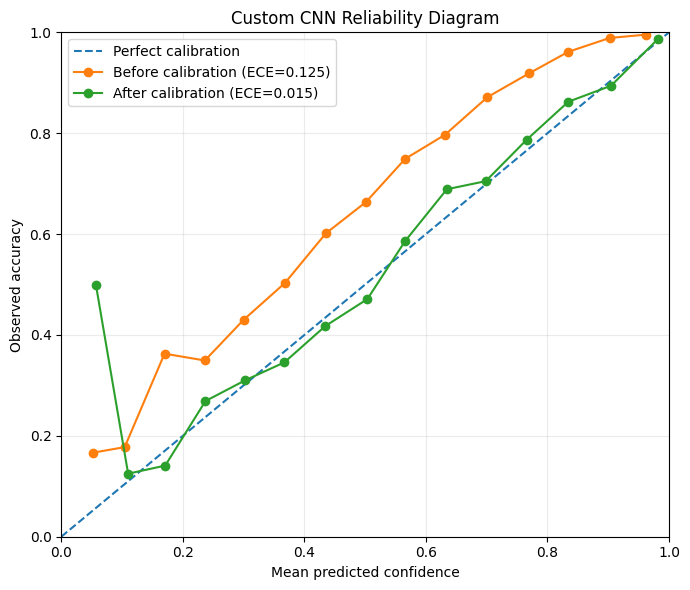

Saved: /kaggle/working/results/custom_cnn_reliability_diagram.pdf


In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    uncalibrated_curve["mean_confidence"],
    uncalibrated_curve["mean_accuracy"],
    marker="o",
    label=(
        f"Before calibration "
        f"(ECE={uncalibrated_ece:.3f})"
    )
)

plt.plot(
    calibrated_curve["mean_confidence"],
    calibrated_curve["mean_accuracy"],
    marker="o",
    label=(
        f"After calibration "
        f"(ECE={calibrated_ece:.3f})"
    )
)

plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")
plt.title("Custom CNN Reliability Diagram")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

reliability_diagram_path = (
    OUTPUT_DIR / "custom_cnn_reliability_diagram.pdf"
)

plt.savefig(
    reliability_diagram_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved:", reliability_diagram_path)

In [50]:
validation_confidences, validation_predictions = (
    calibrated_validation_probabilities.max(dim=1)
)

validation_correct = (
    validation_predictions
    == validation_targets_tensor
)

threshold_rows = []

for threshold in np.arange(
    0.20,
    0.951,
    0.025
):
    accepted = (
        validation_confidences
        >= threshold
    )

    accepted_count = int(
        accepted.sum().item()
    )

    if accepted_count == 0:
        continue

    coverage = (
        accepted.float().mean().item()
    )

    accepted_accuracy = (
        validation_correct[accepted]
        .float()
        .mean()
        .item()
    )

    threshold_rows.append({
        "threshold": float(threshold),
        "coverage": coverage,
        "accepted_samples": accepted_count,
        "accepted_accuracy": accepted_accuracy,
        "abstention_rate": 1 - coverage
    })

threshold_results_df = pd.DataFrame(
    threshold_rows
)

# Select the highest-coverage threshold reaching 90% accuracy.
eligible_thresholds = threshold_results_df[
    threshold_results_df[
        "accepted_accuracy"
    ] >= 0.90
].copy()

if len(eligible_thresholds) > 0:
    selected_threshold_row = (
        eligible_thresholds
        .sort_values(
            [
                "coverage",
                "threshold"
            ],
            ascending=[
                False,
                True
            ]
        )
        .iloc[0]
    )
else:
    # Fallback: maximize accepted accuracy while keeping
    # at least 50% validation coverage.
    fallback_candidates = threshold_results_df[
        threshold_results_df[
            "coverage"
        ] >= 0.50
    ]

    selected_threshold_row = (
        fallback_candidates
        .sort_values(
            [
                "accepted_accuracy",
                "coverage"
            ],
            ascending=[
                False,
                False
            ]
        )
        .iloc[0]
    )

SELECTED_CONFIDENCE_THRESHOLD = float(
    selected_threshold_row["threshold"]
)

print("=" * 80)
print("VALIDATION-BASED ABSTENTION THRESHOLD")
print("=" * 80)

print(
    threshold_results_df
    .round(4)
    .to_string(index=False)
)

print("\nSelected threshold:")
print(selected_threshold_row.round(4))

threshold_results_df.to_csv(
    OUTPUT_DIR / "abstention_threshold_analysis.csv",
    index=False
)

VALIDATION-BASED ABSTENTION THRESHOLD
 threshold  coverage  accepted_samples  accepted_accuracy  abstention_rate
     0.200    0.9931             15021             0.8129           0.0069
     0.225    0.9901             14976             0.8146           0.0099
     0.250    0.9868             14926             0.8164           0.0132
     0.275    0.9818             14850             0.8191           0.0182
     0.300    0.9762             14765             0.8219           0.0238
     0.325    0.9687             14652             0.8260           0.0313
     0.350    0.9604             14526             0.8302           0.0396
     0.375    0.9522             14402             0.8345           0.0478
     0.400    0.9431             14265             0.8391           0.0569
     0.425    0.9328             14108             0.8443           0.0672
     0.450    0.9229             13959             0.8491           0.0771
     0.475    0.9113             13783             0.8540     

In [51]:
# =========================================================
# Calibrate saved Custom CNN test probabilities
# We need logits, so collect them once from the locked test.
# =========================================================

test_logits_list = []
test_targets_list = []

calibration_model.eval()

with torch.inference_mode():
    for batch in tqdm(
        test_loader,
        desc="Collecting locked-test logits"
    ):
        images = batch["image"].to(
            DEVICE,
            non_blocking=True
        )

        targets = batch["target"].to(
            DEVICE,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):
            logits = calibration_model(images)

        test_logits_list.append(
            logits.float().cpu()
        )

        test_targets_list.append(
            targets.cpu()
        )

custom_test_logits = torch.cat(
    test_logits_list,
    dim=0
)

custom_test_targets_tensor = torch.cat(
    test_targets_list,
    dim=0
)

with torch.no_grad():
    calibrated_test_logits = (
        custom_test_logits
        / temperature_value
    )

    calibrated_test_probabilities = torch.softmax(
        calibrated_test_logits,
        dim=1
    )

test_ece_before, _ = (
    expected_calibration_error(
        torch.softmax(
            custom_test_logits,
            dim=1
        ),
        custom_test_targets_tensor
    )
)

test_ece_after, _ = (
    expected_calibration_error(
        calibrated_test_probabilities,
        custom_test_targets_tensor
    )
)

test_confidences, test_predictions = (
    calibrated_test_probabilities.max(dim=1)
)

test_accepted = (
    test_confidences
    >= SELECTED_CONFIDENCE_THRESHOLD
)

test_correct = (
    test_predictions
    == custom_test_targets_tensor
)

test_coverage = (
    test_accepted.float().mean().item()
)

test_accepted_accuracy = (
    test_correct[test_accepted]
    .float()
    .mean()
    .item()
)

test_abstention_rate = 1 - test_coverage

calibration_summary = pd.DataFrame([{
    "temperature": temperature_value,
    "validation_ece_before": uncalibrated_ece,
    "validation_ece_after": calibrated_ece,
    "selected_threshold": SELECTED_CONFIDENCE_THRESHOLD,
    "validation_coverage": float(
        selected_threshold_row["coverage"]
    ),
    "validation_accepted_accuracy": float(
        selected_threshold_row[
            "accepted_accuracy"
        ]
    ),
    "test_ece_before": test_ece_before,
    "test_ece_after": test_ece_after,
    "test_coverage": test_coverage,
    "test_abstention_rate": test_abstention_rate,
    "test_accepted_accuracy": test_accepted_accuracy
}])

calibration_summary.to_csv(
    OUTPUT_DIR / "calibration_and_abstention_summary.csv",
    index=False
)

print("=" * 80)
print("LOCKED-TEST CALIBRATION AND ABSTENTION")
print("=" * 80)

print(
    calibration_summary
    .round(4)
    .to_string(index=False)
)

LOCKED-TEST CALIBRATION AND ABSTENTION
 temperature  validation_ece_before  validation_ece_after  selected_threshold  validation_coverage  validation_accepted_accuracy  test_ece_before  test_ece_after  test_coverage  test_abstention_rate  test_accepted_accuracy
      0.7094                 0.1254                0.0154                 0.6               0.7946                        0.9001           0.1278          0.0117         0.7904                0.2096                  0.8981


In [52]:
deployment_checkpoint = {
    "model_name": "CustomCNN",
    "model_state_dict": (
        calibration_model
        .cpu()
        .state_dict()
    ),
    "number_of_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "temperature": temperature_value,
    "confidence_threshold": (
        SELECTED_CONFIDENCE_THRESHOLD
    ),
    "symbol_id_to_index": symbol_id_to_index,
    "index_to_symbol_id": index_to_symbol_id,
    "index_to_latex": index_to_latex,
    "preprocessing": {
        "padding": 8,
        "resize": [
            IMAGE_SIZE,
            IMAGE_SIZE
        ],
        "mean": [
            0.485,
            0.456,
            0.406
        ],
        "std": [
            0.229,
            0.224,
            0.225
        ]
    }
}

DEPLOYMENT_MODEL_PATH = (
    OUTPUT_DIR /
    "custom_cnn_deployment_model.pt"
)

torch.save(
    deployment_checkpoint,
    DEPLOYMENT_MODEL_PATH
)

deployment_size_mb = (
    os.path.getsize(
        DEPLOYMENT_MODEL_PATH
    )
    / (1024 ** 2)
)

print("Deployment model saved:")
print(DEPLOYMENT_MODEL_PATH)
print(
    "Deployment model size:",
    f"{deployment_size_mb:.2f} MB"
)

Deployment model saved:
/kaggle/working/results/custom_cnn_deployment_model.pt
Deployment model size: 5.12 MB


In [53]:
import random
from PIL import Image, ImageFilter, ImageOps, ImageDraw
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import InterpolationMode

# =========================================================
# Reproducible robustness subset
# =========================================================
ROBUSTNESS_SAMPLE_SIZE = 5000

robustness_test_df = locked_test_df.sample(
    n=min(
        ROBUSTNESS_SAMPLE_SIZE,
        len(locked_test_df)
    ),
    random_state=RANDOM_SEED
).reset_index(drop=True)

print(
    "Robustness subset size:",
    len(robustness_test_df)
)

Robustness subset size: 5000


In [54]:
class RobustnessTransform:
    def __init__(self, perturbation):
        self.perturbation = perturbation

        self.final_transform = transforms.Compose([
            transforms.Pad(
                padding=8,
                fill=255,
                padding_mode="constant"
            ),
            transforms.Resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                interpolation=InterpolationMode.BILINEAR,
                antialias=True
            ),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __call__(self, image):
        image = image.convert("RGB")

        if self.perturbation == "clean":
            modified = image

        elif self.perturbation == "rotation_10":
            modified = image.rotate(
                10,
                resample=Image.Resampling.BILINEAR,
                fillcolor=(255, 255, 255)
            )

        elif self.perturbation == "blur":
            modified = image.filter(
                ImageFilter.GaussianBlur(
                    radius=1.0
                )
            )

        elif self.perturbation == "thick_strokes":
            grayscale = image.convert("L")

            # MinimumFilter expands dark symbol pixels.
            grayscale = grayscale.filter(
                ImageFilter.MinFilter(size=3)
            )

            modified = grayscale.convert("RGB")

        elif self.perturbation == "partial_erasure":
            modified = image.copy()

            width, height = modified.size

            draw = ImageDraw.Draw(modified)

            # Remove a reproducible central-right region.
            draw.rectangle(
                [
                    int(width * 0.58),
                    int(height * 0.35),
                    int(width * 0.78),
                    int(height * 0.65)
                ],
                fill=(255, 255, 255)
            )

        else:
            raise ValueError(
                f"Unknown perturbation: "
                f"{self.perturbation}"
            )

        return self.final_transform(modified)


robustness_conditions = {
    "Clean": "clean",
    "Rotation +10 degrees": "rotation_10",
    "Gaussian blur": "blur",
    "Thickened strokes": "thick_strokes",
    "Partial erasure": "partial_erasure"
}

print("Robustness transforms created.")

Robustness transforms created.


In [57]:
robustness_results = []

for condition_name, perturbation_name in robustness_conditions.items():
    print(f"Evaluating: {condition_name}")

    condition_dataset = HASYv2Dataset(
        robustness_test_df,
        transform=RobustnessTransform(
            perturbation_name
        )
    )

    # num_workers=0 avoids Kaggle multiprocessing cleanup errors.
    condition_loader = DataLoader(
        condition_dataset,
        batch_size=256,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    metrics = evaluate_robustness_loader(
        robustness_model,
        condition_loader,
        DEVICE
    )

    robustness_results.append({
        "condition": condition_name,
        "top1_accuracy": metrics["top1_accuracy"],
        "macro_f1": metrics["macro_f1"]
    })

robustness_results_df = pd.DataFrame(
    robustness_results
)

clean_accuracy = float(
    robustness_results_df.loc[
        robustness_results_df["condition"] == "Clean",
        "top1_accuracy"
    ].iloc[0]
)

clean_macro_f1 = float(
    robustness_results_df.loc[
        robustness_results_df["condition"] == "Clean",
        "macro_f1"
    ].iloc[0]
)

robustness_results_df["accuracy_drop"] = (
    clean_accuracy
    - robustness_results_df["top1_accuracy"]
)

robustness_results_df["macro_f1_drop"] = (
    clean_macro_f1
    - robustness_results_df["macro_f1"]
)

robustness_results_df.to_csv(
    OUTPUT_DIR / "robustness_results.csv",
    index=False
)

print(
    robustness_results_df
    .round(4)
    .to_string(index=False)
)

Evaluating: Clean


  0%|          | 0/20 [00:00<?, ?it/s]

Evaluating: Rotation +10 degrees


  0%|          | 0/20 [00:00<?, ?it/s]

Evaluating: Gaussian blur


...

Evaluating: Thickened strokes


  0%|          | 0/20 [00:00<?, ?it/s]

Evaluating: Partial erasure


  0%|          | 0/20 [00:00<?, ?it/s]

           condition  top1_accuracy  macro_f1  accuracy_drop  macro_f1_drop
               Clean         0.8052    0.6722         0.0000         0.0000
Rotation +10 degrees         0.7880    0.6442         0.0172         0.0280
       Gaussian blur         0.8060    0.6729        -0.0008        -0.0006
   Thickened strokes         0.4358    0.2958         0.3694         0.3764
     Partial erasure         0.6758    0.5311         0.1294         0.1412


In [56]:
class RobustnessTransform:
    def __init__(self, perturbation):
        self.perturbation = perturbation

        self.base_prepare = transforms.Compose([
            transforms.Pad(
                padding=8,
                fill=255,
                padding_mode="constant"
            ),
            transforms.Resize(
                (IMAGE_SIZE, IMAGE_SIZE),
                interpolation=InterpolationMode.BILINEAR,
                antialias=True
            )
        ])

        self.to_normalized_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __call__(self, image):
        image = image.convert("RGB")

        # First produce the common 96x96 padded image.
        prepared = self.base_prepare(image)

        if self.perturbation == "clean":
            modified = prepared

        elif self.perturbation == "rotation_10":
            modified = prepared.rotate(
                10,
                resample=Image.Resampling.BILINEAR,
                fillcolor=(255, 255, 255)
            )

        elif self.perturbation == "blur":
            modified = prepared.filter(
                ImageFilter.GaussianBlur(
                    radius=1.0
                )
            )

        elif self.perturbation == "thick_strokes":
            # Mild one-pixel dark-stroke expansion at 96x96.
            grayscale = prepared.convert("L")
            grayscale = grayscale.filter(
                ImageFilter.MinFilter(size=3)
            )
            modified = grayscale.convert("RGB")

        elif self.perturbation == "partial_erasure":
            modified = prepared.copy()

            width, height = modified.size
            draw = ImageDraw.Draw(modified)

            draw.rectangle(
                [
                    int(width * 0.60),
                    int(height * 0.40),
                    int(width * 0.75),
                    int(height * 0.60)
                ],
                fill=(255, 255, 255)
            )

        else:
            raise ValueError(
                f"Unknown perturbation: {self.perturbation}"
            )

        return self.to_normalized_tensor(modified)


print("Corrected robustness transforms created.")

Corrected robustness transforms created.


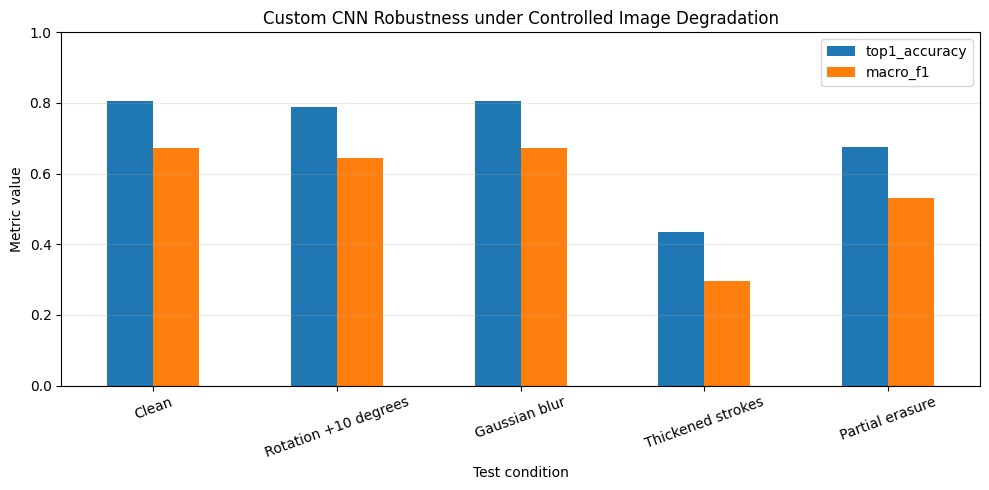

Saved: /kaggle/working/results/custom_cnn_robustness_results.pdf


In [58]:
robustness_plot_df = (
    robustness_results_df[
        [
            "condition",
            "top1_accuracy",
            "macro_f1"
        ]
    ]
    .set_index("condition")
)

axis = robustness_plot_df.plot(
    kind="bar",
    figsize=(10, 5)
)

axis.set_xlabel("Test condition")
axis.set_ylabel("Metric value")
axis.set_title(
    "Custom CNN Robustness under Controlled Image Degradation"
)
axis.set_ylim(0, 1)
axis.tick_params(
    axis="x",
    rotation=20
)
axis.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

robustness_figure_path = (
    OUTPUT_DIR /
    "custom_cnn_robustness_results.pdf"
)

plt.savefig(
    robustness_figure_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved:", robustness_figure_path)

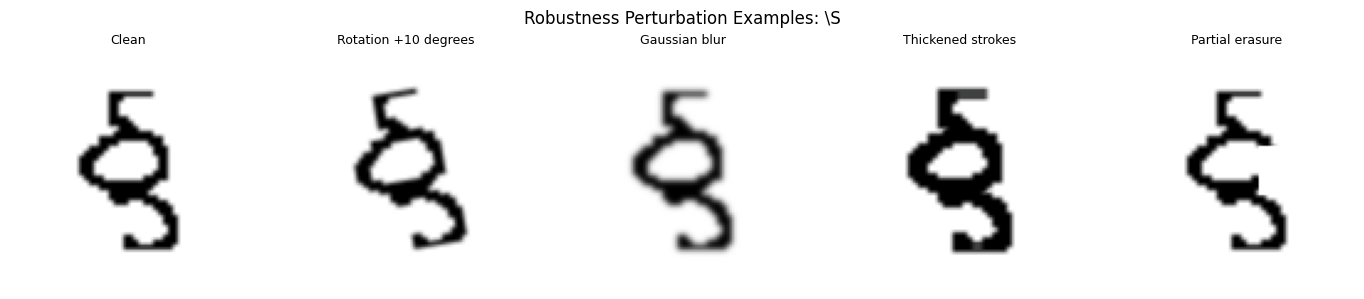

Saved: /kaggle/working/results/robustness_perturbation_examples.pdf


In [59]:
example_row = robustness_test_df.iloc[0]

example_path = resolve_image_path(
    example_row["path"]
)

with Image.open(example_path) as image:
    example_image = image.convert("RGB")

figure, axes = plt.subplots(
    1,
    5,
    figsize=(14, 3)
)

for axis, (
    condition_name,
    perturbation_name
) in zip(
    axes,
    robustness_conditions.items()
):
    raw_transform = RobustnessTransform(
        perturbation_name
    )

    transformed_tensor = raw_transform(
        example_image
    )

    display_tensor = (
        transformed_tensor.clone()
    )

    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    display_tensor = (
        display_tensor * std + mean
    ).clamp(0, 1)

    axis.imshow(
        display_tensor
        .permute(1, 2, 0)
        .numpy()
    )

    axis.set_title(
        condition_name,
        fontsize=9
    )

    axis.axis("off")

plt.suptitle(
    f"Robustness Perturbation Examples: "
    f"{example_row['latex']}"
)

plt.tight_layout()

robustness_examples_path = (
    OUTPUT_DIR /
    "robustness_perturbation_examples.pdf"
)

plt.savefig(
    robustness_examples_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved:", robustness_examples_path)

In [60]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# Reload deployment model for Grad-CAM
# =========================================================
gradcam_model = CustomCNN(
    num_classes=NUM_CLASSES
).to(DEVICE)

gradcam_checkpoint = torch.load(
    OUTPUT_DIR / "custom_cnn_deployment_model.pt",
    map_location=DEVICE,
    weights_only=False
)

gradcam_model.load_state_dict(
    gradcam_checkpoint["model_state_dict"]
)

gradcam_model.eval()

# Final convolutional layer of the custom CNN.
gradcam_target_layer = gradcam_model.features[27]

print("Grad-CAM target layer:")
print(gradcam_target_layer)

Grad-CAM target layer:
Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


In [61]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_hook = (
            target_layer.register_forward_hook(
                self._save_activations
            )
        )

        self.backward_hook = (
            target_layer.register_full_backward_hook(
                self._save_gradients
            )
        )

    def _save_activations(
        self,
        module,
        input_value,
        output_value
    ):
        self.activations = output_value.detach()

    def _save_gradients(
        self,
        module,
        grad_input,
        grad_output
    ):
        self.gradients = grad_output[0].detach()

    def generate(
        self,
        input_tensor,
        target_class=None
    ):
        self.model.zero_grad(set_to_none=True)

        logits = self.model(input_tensor)

        if target_class is None:
            target_class = int(
                logits.argmax(dim=1).item()
            )

        score = logits[:, target_class]

        score.backward()

        weights = self.gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (
            weights * self.activations
        ).sum(
            dim=1,
            keepdim=True
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze()

        cam_min = cam.min()
        cam_max = cam.max()

        cam = (
            cam - cam_min
        ) / (
            cam_max - cam_min + 1e-8
        )

        return (
            cam.detach().cpu().numpy(),
            logits.detach()
        )

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


gradcam = GradCAM(
    gradcam_model,
    gradcam_target_layer
)

print("Grad-CAM helper created.")

Grad-CAM helper created.


In [62]:
# =========================================================
# Select explanation cases from locked test predictions
# =========================================================
explanation_selection_df = custom_predictions.copy()

explanation_selection_df["correct"] = (
    explanation_selection_df["true_index"]
    == explanation_selection_df["predicted_index"]
)

# Add original CSV row index.
explanation_selection_df["dataset_index"] = (
    np.arange(len(explanation_selection_df))
)

correct_cases = explanation_selection_df[
    explanation_selection_df["correct"]
]

incorrect_cases = explanation_selection_df[
    ~explanation_selection_df["correct"]
]

selected_cases = pd.concat([
    correct_cases.nlargest(
        1,
        "confidence"
    ).assign(
        case_type="Correct high confidence"
    ),

    correct_cases.nsmallest(
        1,
        "confidence"
    ).assign(
        case_type="Correct low confidence"
    ),

    incorrect_cases.nlargest(
        1,
        "confidence"
    ).assign(
        case_type="Incorrect high confidence"
    ),

    incorrect_cases.nsmallest(
        1,
        "confidence"
    ).assign(
        case_type="Incorrect low confidence"
    )
]).reset_index(drop=True)

print(
    selected_cases[
        [
            "case_type",
            "true_latex",
            "predicted_latex",
            "confidence",
            "dataset_index"
        ]
    ]
    .round(4)
    .to_string(index=False)
)

                case_type          true_latex predicted_latex  confidence  dataset_index
  Correct high confidence                  \%              \%      0.9987           6185
   Correct low confidence                \cap            \cap      0.0438           7250
Incorrect high confidence             \preceq           \prec      0.9721           9048
 Incorrect low confidence \Longleftrightarrow \Leftrightarrow      0.0353          10754


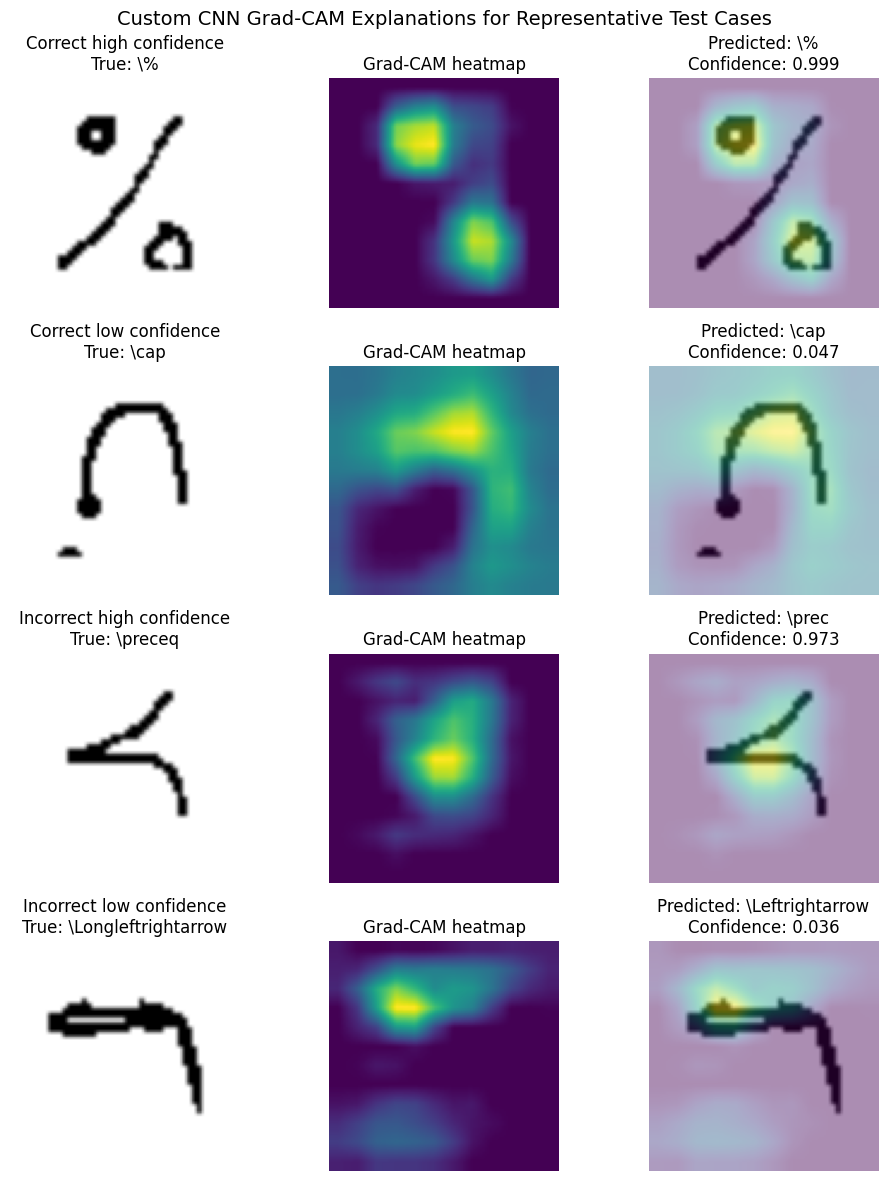

Saved: /kaggle/working/results/custom_cnn_gradcam_examples.pdf


In [63]:
def denormalize_tensor(image_tensor):
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    return (
        image_tensor.cpu() * std + mean
    ).clamp(0, 1)


figure, axes = plt.subplots(
    len(selected_cases),
    3,
    figsize=(10, 12)
)

gradcam_records = []

for row_number, case_row in selected_cases.iterrows():
    dataset_index = int(
        case_row["dataset_index"]
    )

    sample = test_dataset[
        dataset_index
    ]

    image_tensor = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )

    true_index = int(
        sample["target"]
    )

    predicted_index = int(
        case_row["predicted_index"]
    )

    heatmap, logits = gradcam.generate(
        image_tensor,
        target_class=predicted_index
    )

    probability = torch.softmax(
        logits.float(),
        dim=1
    )[0, predicted_index].item()

    display_image = denormalize_tensor(
        image_tensor.squeeze(0)
    ).permute(
        1,
        2,
        0
    ).numpy()

    axes[row_number, 0].imshow(
        display_image
    )

    axes[row_number, 0].set_title(
        f"{case_row['case_type']}\n"
        f"True: {index_to_latex[true_index]}"
    )

    axes[row_number, 0].axis("off")

    axes[row_number, 1].imshow(
        heatmap
    )

    axes[row_number, 1].set_title(
        "Grad-CAM heatmap"
    )

    axes[row_number, 1].axis("off")

    axes[row_number, 2].imshow(
        display_image
    )

    axes[row_number, 2].imshow(
        heatmap,
        alpha=0.45
    )

    axes[row_number, 2].set_title(
        f"Predicted: "
        f"{index_to_latex[predicted_index]}\n"
        f"Confidence: {probability:.3f}"
    )

    axes[row_number, 2].axis("off")

    gradcam_records.append({
        "case_type": case_row["case_type"],
        "true_latex": index_to_latex[
            true_index
        ],
        "predicted_latex": index_to_latex[
            predicted_index
        ],
        "confidence": probability,
        "dataset_index": dataset_index
    })

plt.suptitle(
    "Custom CNN Grad-CAM Explanations for Representative Test Cases",
    fontsize=14
)

plt.tight_layout()

gradcam_figure_path = (
    OUTPUT_DIR /
    "custom_cnn_gradcam_examples.pdf"
)

plt.savefig(
    gradcam_figure_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

pd.DataFrame(
    gradcam_records
).to_csv(
    OUTPUT_DIR /
    "gradcam_example_metadata.csv",
    index=False
)

print("Saved:", gradcam_figure_path)

In [64]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [65]:
# =========================================================
# Small SHAP background set
# =========================================================
background_images = []

for batch in validation_loader:
    images = batch["image"]
    for image in images:
        background_images.append(image)
        if len(background_images) >= 20:
            break
    if len(background_images) >= 20:
        break

background_tensor = torch.stack(background_images).to(DEVICE)

print("Background tensor shape:", background_tensor.shape)

Background tensor shape: torch.Size([20, 3, 96, 96])


In [66]:
# =========================================================
# Prepare SHAP input samples from selected cases
# =========================================================
shap_case_indices = selected_cases["dataset_index"].tolist()

shap_images = []
shap_metadata = []

for _, case_row in selected_cases.iterrows():
    dataset_index = int(case_row["dataset_index"])
    sample = test_dataset[dataset_index]

    shap_images.append(sample["image"])
    shap_metadata.append({
        "case_type": case_row["case_type"],
        "true_latex": case_row["true_latex"],
        "predicted_latex": case_row["predicted_latex"],
        "dataset_index": dataset_index
    })

shap_input_tensor = torch.stack(shap_images).to(DEVICE)

print("SHAP input tensor shape:", shap_input_tensor.shape)

pd.DataFrame(shap_metadata)

SHAP input tensor shape: torch.Size([4, 3, 96, 96])


,case_type,true_latex,predicted_latex,dataset_index
0,Correct high confidence,\%,\%,6185
1,Correct low confidence,\cap,\cap,7250
2,Incorrect high confidence,\preceq,\prec,9048
3,Incorrect low confidence,\Longleftrightarrow,\Leftrightarrow,10754


In [68]:
# =========================================================
# Prediction wrapper for SHAP
# =========================================================
def custom_cnn_predict(input_tensor):
    gradcam_model.eval()

    with torch.no_grad():
        logits = gradcam_model(input_tensor.to(DEVICE))
        probabilities = torch.softmax(logits, dim=1)

    return probabilities

In [69]:
# =========================================================
# Limited SHAP explanation
# =========================================================
explainer = shap.GradientExplainer(
    gradcam_model,
    background_tensor
)

# Explain only the predicted class for each sample.
with torch.no_grad():
    predicted_logits = gradcam_model(shap_input_tensor)
    predicted_indices = predicted_logits.argmax(dim=1).cpu().numpy()

print("Predicted class indices:", predicted_indices)

shap_values = explainer.shap_values(
    shap_input_tensor,
    ranked_outputs=1
)

print("SHAP explanation completed.")

Predicted class indices: [125 143 177 227]
SHAP explanation completed.


In [70]:
# =========================================================
# Helper for SHAP visualization
# =========================================================
def denormalize_batch(batch_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    return (batch_tensor.cpu() * std + mean).clamp(0, 1)

display_images = denormalize_batch(shap_input_tensor).permute(0, 2, 3, 1).cpu().numpy()

print("Display images shape:", display_images.shape)

Display images shape: (4, 96, 96, 3)


In [72]:
# =========================================================
# Inspect SHAP output shapes safely
# =========================================================
shap_attributions = shap_values[0]
shap_ranked_indexes = shap_values[1]

if torch.is_tensor(shap_attributions):
    shap_attributions_np = (
        shap_attributions
        .detach()
        .cpu()
        .numpy()
    )
else:
    shap_attributions_np = np.asarray(
        shap_attributions
    )

if torch.is_tensor(shap_ranked_indexes):
    shap_ranked_indexes_np = (
        shap_ranked_indexes
        .detach()
        .cpu()
        .numpy()
    )
else:
    shap_ranked_indexes_np = np.asarray(
        shap_ranked_indexes
    )

print(
    "SHAP attribution shape:",
    shap_attributions_np.shape
)

print(
    "Ranked output indices shape:",
    shap_ranked_indexes_np.shape
)

print(
    "Ranked output indices:",
    shap_ranked_indexes_np.squeeze()
)

SHAP attribution shape: (4, 3, 96, 96, 1)
Ranked output indices shape: (4, 1)
Ranked output indices: [125 143 177 227]


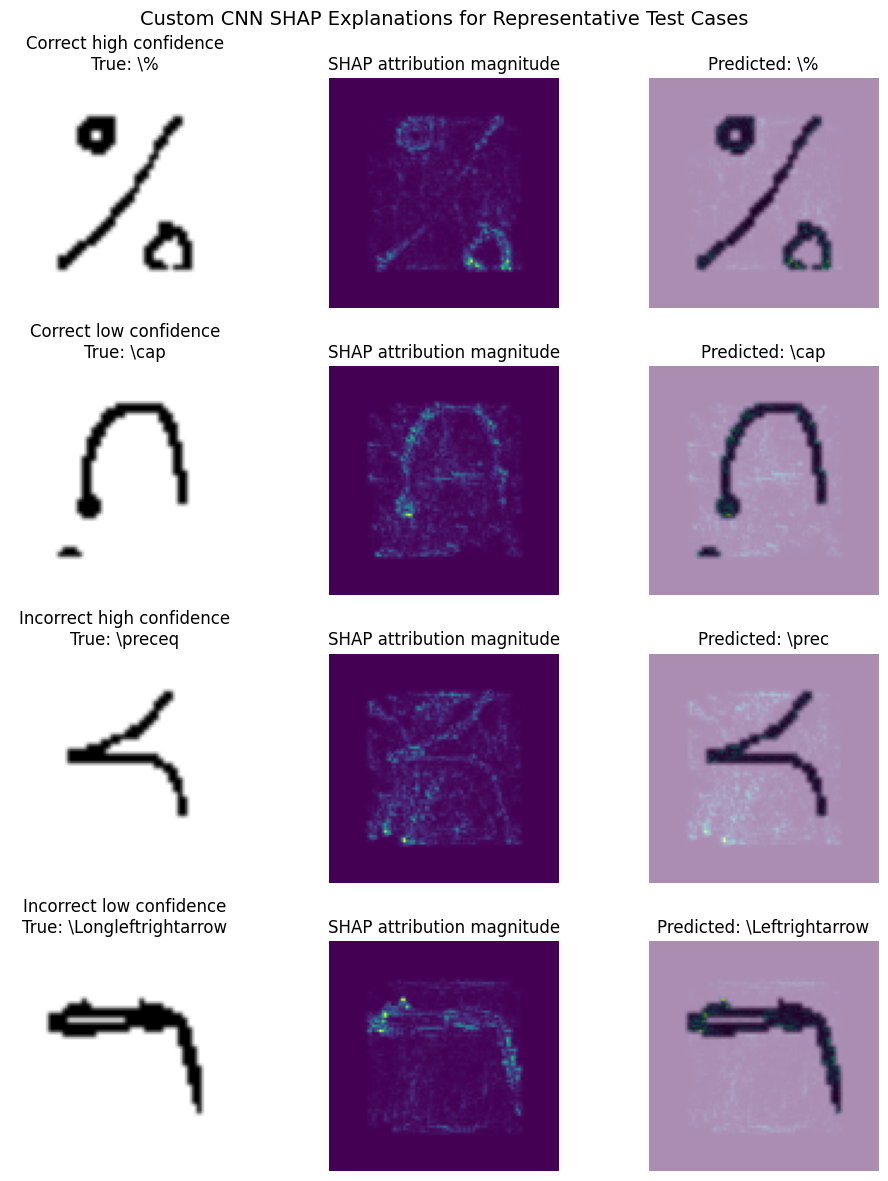

Saved: /kaggle/working/results/custom_cnn_shap_examples.pdf


In [73]:
# =========================================================
# Corrected SHAP visualization
# =========================================================
figure, axes = plt.subplots(
    len(shap_metadata),
    3,
    figsize=(10, 12)
)

for i in range(len(shap_metadata)):
    image = display_images[i]

    attribution = shap_attributions_np[i]

    # Expected shape:
    # (3, 96, 96, 1)
    attribution = np.squeeze(
        attribution,
        axis=-1
    )

    # Combine RGB channels into one attribution magnitude map.
    attribution_map = np.abs(
        attribution
    ).mean(axis=0)

    attribution_map = (
        attribution_map
        - attribution_map.min()
    ) / (
        attribution_map.max()
        - attribution_map.min()
        + 1e-8
    )

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(
        f"{shap_metadata[i]['case_type']}\n"
        f"True: {shap_metadata[i]['true_latex']}"
    )
    axes[i, 0].axis("off")

    axes[i, 1].imshow(
        attribution_map
    )
    axes[i, 1].set_title(
        "SHAP attribution magnitude"
    )
    axes[i, 1].axis("off")

    axes[i, 2].imshow(image)
    axes[i, 2].imshow(
        attribution_map,
        alpha=0.45
    )
    axes[i, 2].set_title(
        f"Predicted: "
        f"{shap_metadata[i]['predicted_latex']}"
    )
    axes[i, 2].axis("off")

plt.suptitle(
    "Custom CNN SHAP Explanations for Representative Test Cases",
    fontsize=14
)

plt.tight_layout()

shap_figure_path = (
    OUTPUT_DIR
    / "custom_cnn_shap_examples.pdf"
)

plt.savefig(
    shap_figure_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

print("Saved:", shap_figure_path)

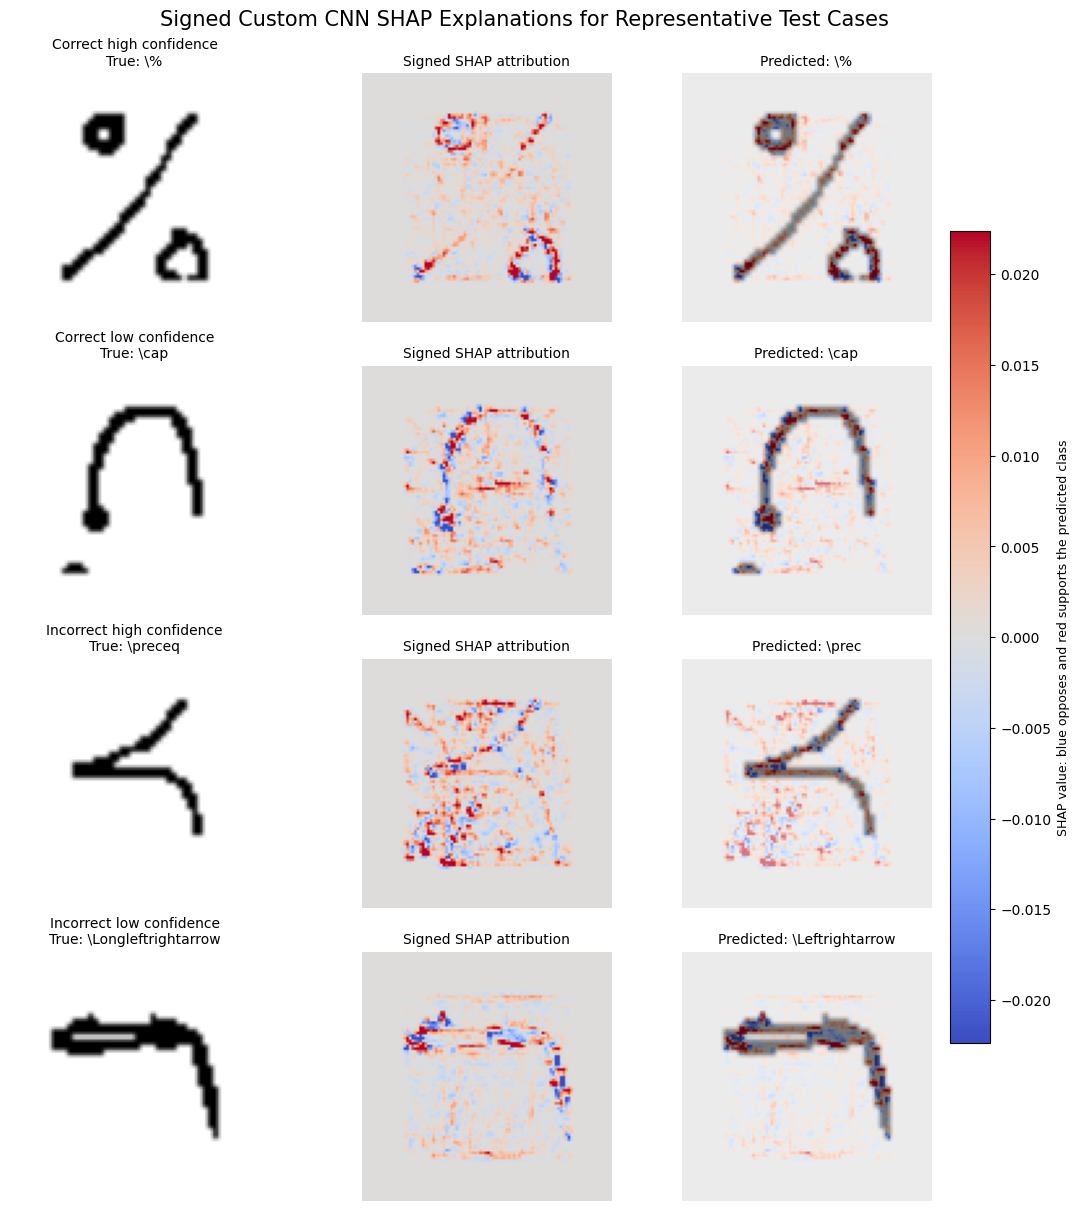

Saved corrected figure:
/kaggle/working/results/custom_cnn_shap_signed_examples.pdf


In [75]:
# =========================================================
# Publication-ready signed SHAP visualization
# =========================================================
from matplotlib.colors import TwoSlopeNorm

number_of_cases = len(shap_metadata)

figure, axes = plt.subplots(
    number_of_cases,
    3,
    figsize=(11, 12),
    constrained_layout=True
)

signed_shap_records = []
heatmap_artist = None

for i in range(number_of_cases):
    image = display_images[i]

    attribution = np.asarray(
        shap_attributions_np[i]
    )

    # (3, 96, 96, 1) -> (3, 96, 96)
    attribution = np.squeeze(
        attribution,
        axis=-1
    )

    # Preserve direction while combining RGB channels.
    signed_map = attribution.mean(axis=0)

    absolute_limit = np.percentile(
        np.abs(signed_map),
        99
    )

    if absolute_limit <= 0:
        absolute_limit = 1e-8

    normalization = TwoSlopeNorm(
        vmin=-absolute_limit,
        vcenter=0,
        vmax=absolute_limit
    )

    # Original image
    axes[i, 0].imshow(image)

    axes[i, 0].set_title(
        f"{shap_metadata[i]['case_type']}\n"
        f"True: {shap_metadata[i]['true_latex']}",
        fontsize=10
    )

    axes[i, 0].axis("off")

    # Signed attribution
    heatmap_artist = axes[i, 1].imshow(
        signed_map,
        cmap="coolwarm",
        norm=normalization
    )

    axes[i, 1].set_title(
        "Signed SHAP attribution",
        fontsize=10
    )

    axes[i, 1].axis("off")

    # Overlay
    axes[i, 2].imshow(image)

    axes[i, 2].imshow(
        signed_map,
        cmap="coolwarm",
        norm=normalization,
        alpha=0.55
    )

    axes[i, 2].set_title(
        f"Predicted: "
        f"{shap_metadata[i]['predicted_latex']}",
        fontsize=10
    )

    axes[i, 2].axis("off")

    signed_shap_records.append({
        "case_type": shap_metadata[i]["case_type"],
        "true_latex": shap_metadata[i]["true_latex"],
        "predicted_latex": shap_metadata[i]["predicted_latex"],
        "ranked_output_index": int(
            shap_ranked_indexes_np[i, 0]
        ),
        "maximum_positive_attribution": float(
            signed_map.max()
        ),
        "minimum_negative_attribution": float(
            signed_map.min()
        )
    })

figure.suptitle(
    "Signed Custom CNN SHAP Explanations for Representative Test Cases",
    fontsize=15
)

colorbar = figure.colorbar(
    heatmap_artist,
    ax=axes[:, 1:].ravel().tolist(),
    location="right",
    shrink=0.72,
    pad=0.03
)

colorbar.set_label(
    "SHAP value: blue opposes and red supports the predicted class",
    fontsize=9
)

signed_shap_figure_path = (
    OUTPUT_DIR
    / "custom_cnn_shap_signed_examples.pdf"
)

plt.savefig(
    signed_shap_figure_path,
    format="pdf",
    bbox_inches="tight"
)

plt.show()

signed_shap_metadata_df = pd.DataFrame(
    signed_shap_records
)

signed_shap_metadata_df.to_csv(
    OUTPUT_DIR / "shap_example_metadata.csv",
    index=False
)

print("Saved corrected figure:")
print(signed_shap_figure_path)

In [76]:
from pathlib import Path
import shutil
import os
import pandas as pd

RESULTS_DIR = Path("/kaggle/working/results")
PACKAGE_DIR = Path("/kaggle/working/final_project_package")

# Start with a clean package folder.
if PACKAGE_DIR.exists():
    shutil.rmtree(PACKAGE_DIR)

# Create an organized folder structure.
folders = {
    "models": PACKAGE_DIR / "models",
    "figures": PACKAGE_DIR / "figures",
    "tables": PACKAGE_DIR / "tables",
    "predictions": PACKAGE_DIR / "predictions",
    "metadata": PACKAGE_DIR / "metadata"
}

for folder in folders.values():
    folder.mkdir(parents=True, exist_ok=True)

print("Package folders created.")

Package folders created.


In [77]:
# =========================================================
# Files to include in the final package
# =========================================================

model_files = [
    "custom_cnn_deployment_model.pt",
    "best_custom_cnn.pt",
    "best_efficientnet_v2_s.pt",
    "best_convnext_tiny.pt"
]

figure_files = [
    "training_samples_preview_revised.pdf",

    "custom_cnn_loss_curve.pdf",
    "custom_cnn_accuracy_curve.pdf",
    "custom_cnn_validation_metrics.pdf",

    "efficientnet_v2_s_loss_curve.pdf",
    "efficientnet_v2_s_accuracy_curve.pdf",
    "efficientnet_v2_s_validation_metrics.pdf",

    "convnext_tiny_loss_curve.pdf",
    "convnext_tiny_accuracy_curve.pdf",
    "convnext_tiny_validation_metrics.pdf",

    "frequency_group_macro_f1.pdf",

    "custom_cnn_confusion_matrix_full.pdf",
    "efficientnet_v2_s_confusion_matrix_full.pdf",
    "convnext_tiny_confusion_matrix_full.pdf",
    "custom_cnn_confusion_matrix_major_classes_corrected.pdf",

    "custom_cnn_reliability_diagram.pdf",

    "custom_cnn_robustness_results.pdf",
    "robustness_perturbation_examples.pdf",

    "custom_cnn_gradcam_examples.pdf",
    "custom_cnn_shap_examples.pdf",
    "custom_cnn_shap_signed_examples.pdf"
]

table_files = [
    "split_summary.csv",
    "split_class_frequencies.csv",
    "class_frequency_groups.csv",

    "custom_cnn_training_history.csv",
    "efficientnet_v2_s_training_history.csv",
    "convnext_tiny_training_history.csv",

    "model_comparison.csv",
    "standardized_efficiency_results.csv",
    "frequency_group_results.csv",

    "custom_cnn_classification_report.csv",
    "efficientnet_v2_s_classification_report.csv",
    "convnext_tiny_classification_report.csv",

    "all_models_per_class_results.csv",
    "top_confusion_pairs.csv",

    "calibration_curve_data.csv",
    "abstention_threshold_analysis.csv",
    "calibration_and_abstention_summary.csv",

    "robustness_results.csv",
    "gradcam_example_metadata.csv",
    "shap_example_metadata.csv"
]

prediction_files = [
    "custom_cnn_test_predictions.csv",
    "efficientnet_v2_s_test_predictions.csv",
    "convnext_tiny_test_predictions.csv"
]

metadata_files = [
    "label_mapping.json",
    "development_split.csv",
    "validation_split.csv",
    "locked_test_split.csv"
]


def copy_selected_files(file_names, destination):
    copied = []
    missing = []

    for file_name in file_names:
        source_path = RESULTS_DIR / file_name

        if source_path.exists():
            shutil.copy2(
                source_path,
                destination / file_name
            )
            copied.append(file_name)
        else:
            missing.append(file_name)

    return copied, missing


copy_results = {}

copy_results["models"] = copy_selected_files(
    model_files,
    folders["models"]
)

copy_results["figures"] = copy_selected_files(
    figure_files,
    folders["figures"]
)

copy_results["tables"] = copy_selected_files(
    table_files,
    folders["tables"]
)

copy_results["predictions"] = copy_selected_files(
    prediction_files,
    folders["predictions"]
)

copy_results["metadata"] = copy_selected_files(
    metadata_files,
    folders["metadata"]
)

for category, (copied, missing) in copy_results.items():
    print("\n" + "=" * 70)
    print(category.upper())
    print("=" * 70)
    print("Copied:", len(copied))
    print("Missing:", len(missing))

    if missing:
        print("Missing files:")
        for file_name in missing:
            print(" -", file_name)


MODELS
Copied: 4
Missing: 0

FIGURES
Copied: 21
Missing: 0

TABLES
Copied: 20
Missing: 0

PREDICTIONS
Copied: 3
Missing: 0

METADATA
Copied: 4
Missing: 0


In [78]:
# =========================================================
# Human-readable project summary
# =========================================================

summary_text = """
EXPLAINABLE HANDWRITTEN MATHEMATICAL SYMBOL CLASSIFICATION
FINAL TECHNICAL RESULTS SUMMARY

Dataset
-------
Dataset: HASYv2
Total images: 168,233
Number of classes: 369
Development images: 136,116
Validation images: 15,125
Locked test images: 16,992
Input resolution used by models: 96 x 96 RGB

Primary Test Results
--------------------
Custom CNN
- Top-1 accuracy: 81.11%
- Top-5 accuracy: 98.14%
- Macro-F1: 68.59%
- Weighted-F1: 79.49%
- Balanced accuracy: 70.68%

EfficientNetV2-S
- Top-1 accuracy: 78.35%
- Top-5 accuracy: 96.75%
- Macro-F1: 66.50%
- Weighted-F1: 77.27%
- Balanced accuracy: 67.73%

ConvNeXt-Tiny
- Top-1 accuracy: 76.82%
- Top-5 accuracy: 96.21%
- Macro-F1: 64.74%
- Weighted-F1: 76.04%
- Balanced accuracy: 66.58%

Selected Deployment Model
-------------------------
Model: Custom CNN
Parameters: 1,333,841
Deployment file size: approximately 5.12 MB
Single-symbol Tesla T4 latency: approximately 3.04 ms
Batch throughput: approximately 7,491 symbols per second

Calibration and Abstention
--------------------------
Temperature: 0.7094
Validation ECE before calibration: 12.54%
Validation ECE after calibration: 1.54%
Test ECE before calibration: 12.78%
Test ECE after calibration: 1.17%
Confidence threshold: 0.60
Test coverage: 79.04%
Test accepted-prediction accuracy: 89.81%
Test abstention rate: 20.96%

Robustness
----------
Clean accuracy: 80.52%
Rotation +10 degrees: 78.80%
Mild Gaussian blur: 80.60%
Thickened strokes: 43.58%
Partial erasure: 67.58%

Explainability
--------------
Grad-CAM was generated from the final custom-CNN convolutional layer.
A limited SHAP GradientExplainer analysis used 20 validation background images.
Both methods primarily highlighted handwritten stroke regions.
"""

summary_path = PACKAGE_DIR / "TECHNICAL_RESULTS_SUMMARY.txt"

summary_path.write_text(
    summary_text.strip() + "\n",
    encoding="utf-8"
)

print(summary_path.read_text())

EXPLAINABLE HANDWRITTEN MATHEMATICAL SYMBOL CLASSIFICATION
FINAL TECHNICAL RESULTS SUMMARY

Dataset
-------
Dataset: HASYv2
Total images: 168,233
Number of classes: 369
Development images: 136,116
Validation images: 15,125
Locked test images: 16,992
Input resolution used by models: 96 x 96 RGB

Primary Test Results
--------------------
Custom CNN
- Top-1 accuracy: 81.11%
- Top-5 accuracy: 98.14%
- Macro-F1: 68.59%
- Weighted-F1: 79.49%
- Balanced accuracy: 70.68%

EfficientNetV2-S
- Top-1 accuracy: 78.35%
- Top-5 accuracy: 96.75%
- Macro-F1: 66.50%
- Weighted-F1: 77.27%
- Balanced accuracy: 67.73%

ConvNeXt-Tiny
- Top-1 accuracy: 76.82%
- Top-5 accuracy: 96.21%
- Macro-F1: 64.74%
- Weighted-F1: 76.04%
- Balanced accuracy: 66.58%

Selected Deployment Model
-------------------------
Model: Custom CNN
Parameters: 1,333,841
Deployment file size: approximately 5.12 MB
Single-symbol Tesla T4 latency: approximately 3.04 ms
Batch throughput: approximately 7,491 symbols per second

Calibration 

In [79]:
# =========================================================
# Create package manifest
# =========================================================

manifest_rows = []

for file_path in sorted(PACKAGE_DIR.rglob("*")):
    if file_path.is_file():
        manifest_rows.append({
            "relative_path": str(
                file_path.relative_to(PACKAGE_DIR)
            ),
            "size_bytes": file_path.stat().st_size,
            "size_mb": (
                file_path.stat().st_size
                / (1024 ** 2)
            )
        })

manifest_df = pd.DataFrame(manifest_rows)

manifest_df.to_csv(
    PACKAGE_DIR / "FILE_MANIFEST.csv",
    index=False
)

print(
    manifest_df
    .round(4)
    .to_string(index=False)
)

print("\nFiles in package:", len(manifest_df))
print(
    "Package size before ZIP:",
    f"{manifest_df['size_mb'].sum():.2f} MB"
)

# =========================================================
# Create ZIP file
# =========================================================

zip_base_path = Path(
    "/kaggle/working/"
    "explainable_math_symbol_project_results"
)

zip_path = shutil.make_archive(
    str(zip_base_path),
    "zip",
    root_dir=PACKAGE_DIR
)

zip_size_mb = (
    os.path.getsize(zip_path)
    / (1024 ** 2)
)

print("\nZIP created successfully:")
print(zip_path)
print("ZIP size:", f"{zip_size_mb:.2f} MB")

                                                  relative_path  size_bytes  size_mb
                                  TECHNICAL_RESULTS_SUMMARY.txt        1730   0.0016
                       figures/convnext_tiny_accuracy_curve.pdf       15689   0.0150
                figures/convnext_tiny_confusion_matrix_full.pdf       33525   0.0320
                           figures/convnext_tiny_loss_curve.pdf       15989   0.0152
                   figures/convnext_tiny_validation_metrics.pdf       17339   0.0165
                          figures/custom_cnn_accuracy_curve.pdf       14705   0.0140
                   figures/custom_cnn_confusion_matrix_full.pdf       30225   0.0288
figures/custom_cnn_confusion_matrix_major_classes_corrected.pdf       23847   0.0227
                        figures/custom_cnn_gradcam_examples.pdf      218835   0.2087
                              figures/custom_cnn_loss_curve.pdf       14743   0.0141
                     figures/custom_cnn_reliability_diagram.pdf  